# Bài tập 4 & 5 — Hệ thống Dịch máy Anh → Pháp (Neural Machine Translation)

**Học viên:** Đặng Thành Nhân

---

## 1. Đề bài

> Thiết kế một hệ thống để dịch thuật từ **tiếng Anh sang tiếng Pháp**.
>
> **Yêu cầu về dữ liệu**
> - Sử dụng dữ liệu trên lớp: [`rajpulapakura/english-to-french-small-dataset`](https://www.kaggle.com/datasets/rajpulapakura/english-to-french-small-dataset)
> - Phân chia dữ liệu **60:20:20** với **random seed = 45**
>
> **Yêu cầu về kiến trúc**
> - **Mô hình 1:** kiến trúc RNN Encoder–Decoder (RNN thuộc họ RNN bất kỳ), **KHÔNG** dùng Attention.
> - **Mô hình 2:** kiến trúc RNN Encoder–Decoder, **cùng loại RNN với mô hình 1**, nhưng **CÓ** dùng Attention.
>
> **Yêu cầu về kết quả**
> - Quá trình huấn luyện của cả 2 mô hình (train loss, train accuracy, validation loss, validation accuracy)
> - Độ chính xác trên tập testing
>
> **Bài tập 4:** Finetune mô hình 1 để đạt kết quả cao nhất.
> **Bài tập 5:** Finetune mô hình 2 để đạt kết quả cao nhất. So sánh, nhận xét và đề xuất phương án cải thiện.

---

## 2. Tổng quan thiết kế hệ thống

Hệ thống được xây dựng theo pipeline chuẩn của một hệ dịch máy neural (NMT):

```
   Câu tiếng Anh (raw)
            │
            ▼
  ┌──────────────────────┐
  │  Tiền xử lý          │  NFC unicode → lowercase → tách dấu câu
  │  (normalize/tokenize)│  → giữ nguyên dấu tiếng Pháp (é à ç ù ô …)
  └──────────┬───────────┘
             ▼
  ┌──────────────────────┐
  │  Vocab (src / trg)   │  <pad>=0  <sos>=1  <eos>=2  <unk>=3, min_freq
  └──────────┬───────────┘
             ▼
  ┌──────────────────────┐
  │  Numericalisation    │  câu → chuỗi chỉ số (id)
  │  + padding + mask    │
  └──────────┬───────────┘
             ▼
  ┌──────────────────────┐        ┌──────────────────────┐
  │  MÔ HÌNH 1           │        │  MÔ HÌNH 2           │
  │  GRU Enc-Dec         │        │  GRU Enc-Dec         │
  │  KHÔNG Attention     │        │  + Bahdanau Attention│
  └──────────┬───────────┘        └──────────┬───────────┘
             ▼                               ▼
  ┌────────────────────────────────────────────────────────┐
  │  Giải mã: Greedy decode  /  Beam search (length-norm)   │
  └──────────────────────────┬─────────────────────────────┘
                             ▼
  ┌────────────────────────────────────────────────────────┐
  │  Đánh giá: token accuracy (bỏ PAD), exact-match,        │
  │  BLEU-4 (tự cài đặt), chrF, edit distance               │
  └────────────────────────────────────────────────────────┘
```

### 2.1. Kiến trúc Mô hình 1 — RNN Encoder–Decoder (KHÔNG Attention)

Toàn bộ câu nguồn bị **nén vào một vector ngữ cảnh có độ dài cố định** (`context = h_T`).
Decoder chỉ nhìn thấy vector này ở **mọi** bước sinh từ.

```
 src:  x1    x2    x3   ...  xS                     trg:  <sos>  y1    y2   ... <eos>
        │     │     │         │                             │     │     │
      [Emb] [Emb] [Emb]     [Emb]                         [Emb] [Emb] [Emb]
        │     │     │         │                             │     │     │
   ┌────▼─────▼─────▼─────────▼────┐                   ┌────▼─────▼─────▼────┐
   │      BiGRU Encoder            │                   │     GRU Decoder     │
   │  (fw/bw → project về H chiều) │                   │  input = [Emb ; c]  │
   └───────────────┬───────────────┘                   └──────────┬──────────┘
                   │                                              │
              h_T (B, H)  ──────►  c  (context vector, CỐ ĐỊNH) ──┘
                                     │
                                     └── dùng lại y hệt ở mọi timestep t
                                                                   │
                                                        ┌──────────▼──────────┐
                                                        │ Linear → |V_fr|     │
                                                        └─────────────────────┘
```

> **Điểm nghẽn (bottleneck):** với câu dài, `c` không đủ sức chứa toàn bộ thông tin
> → chất lượng dịch suy giảm nhanh theo độ dài câu. Đây chính là giả thuyết ta sẽ
> kiểm chứng bằng thực nghiệm ở phần so sánh.

### 2.2. Kiến trúc Mô hình 2 — RNN Encoder–Decoder + Bahdanau Attention

Decoder được truy cập **toàn bộ chuỗi encoder outputs** `[h_1 … h_S]` và tại **mỗi**
bước `t` tự tính một vector ngữ cảnh **động** `c_t` bằng cách "chú ý" vào các vị trí
nguồn liên quan nhất.

```
 src: x1   x2   x3  ...  xS
   ┌──────────────────────────┐
   │      BiGRU Encoder       │ ──►  H = [h_1, h_2, ..., h_S]   (B, S, H)
   └──────────────────────────┘                 │
                                                │   mask PAD = -inf
   bước giải mã t:                              ▼
        s_{t-1} (query)  ──►  ┌─────────────────────────────────┐
                              │  Bahdanau (additive) attention  │
        H (keys/values)  ──►  │  e_ti = vᵀ tanh(W_s s + W_h h_i)│
                              │  α_t  = softmax(e_t)  (B, S)    │
                              │  c_t  = Σ_i α_ti · h_i          │
                              └───────────────┬─────────────────┘
                                              ▼
                    GRU cell: s_t = GRU([Emb(y_{t-1}) ; c_t], s_{t-1})
                                              ▼
                    Linear([s_t ; c_t ; Emb(y_{t-1})]) → |V_fr|
```

> `c_t` thay đổi theo từng bước → không còn nút cổ chai độ dài cố định, và ma trận
> `α` cho ta **alignment** (bản đồ căn chỉnh) có thể trực quan hoá bằng heatmap.

### 2.3. Các quyết định thiết kế chính

| Hạng mục | Lựa chọn | Lý do |
|---|---|---|
| Loại RNN | **GRU** cho **cả hai** mô hình | Đề bài yêu cầu cùng loại RNN. GRU ít tham số hơn LSTM (~25%), hội tụ nhanh, chất lượng tương đương trên tập dữ liệu nhỏ. |
| Encoder | **Bi-directional**, có lớp chiếu (projection) về `H` chiều | Nắm ngữ cảnh 2 chiều; projection giúp attention và decoder dùng chung số chiều `H`. |
| Attention | **Bahdanau (additive)** — có cài thêm **Luong (general)** để so sánh | Bahdanau là chuẩn cho kiến trúc Enc-Dec RNN; Luong dùng để khảo sát siêu tham số ở Bài tập 5. |
| Loss | CrossEntropy với `ignore_index=<pad>` (+ tuỳ chọn label smoothing) | Không để token đệm làm nhiễu gradient. |
| Metric | token acc (bỏ PAD), exact-match, **BLEU-4 tự cài đặt**, chrF, edit distance | Tự cài đặt BLEU và **có unit-test** kiểm chứng, không phụ thuộc `nltk`/`sacrebleu`. |
| Giải mã | Greedy + **Beam search** (tự cài đặt, có length normalization) | Beam thường tăng BLEU 1–2 điểm so với greedy. |

---

## 3. Hướng dẫn chạy trên Google Colab

1. **Bật GPU:** `Runtime → Change runtime type → Hardware accelerator → GPU (T4)`.
2. **Khai báo Kaggle API key trong Colab Secrets** (biểu tượng 🔑 ở thanh bên trái):
   - Vào [kaggle.com](https://www.kaggle.com) → ảnh đại diện → **Settings** → mục **API** → **Create New Token**
     → tải về file `kaggle.json` chứa `{"username": "...", "key": "..."}`.
   - Trong Colab, mở tab 🔑 **Secrets**, tạo 2 secret:
     - `KAGGLE_USERNAME` = giá trị `username`
     - `KAGGLE_KEY` = giá trị `key`
   - Bật công tắc **Notebook access** cho cả hai.
3. **(Tuỳ chọn nhưng khuyến nghị)** Mount Google Drive ở ô "Mount Drive" để lưu checkpoint
   và kết quả dò siêu tham số — Colab có thể ngắt kết nối giữa chừng (giới hạn ~12 giờ,
   ngắt khi idle), Bài tập 4+5 là bài dài nhất (2 mô hình + 2 lần dò siêu tham số).
4. Chạy `Runtime → Run all`.

> Nếu không cấu hình được Secrets, notebook sẽ tự chuyển sang phương án dự phòng:
> upload `kaggle.json`, hoặc upload trực tiếp file CSV.

---
# Phần 0 — Cấu hình & môi trường

Ô bên dưới chứa **toàn bộ tham số điều khiển** của notebook. Đặc biệt:

* `QUICK_RUN = True` → chạy thử nhanh (smoke test): lấy mẫu nhỏ, ít epoch, lưới siêu tham số rút gọn.
  **Đặt `QUICK_RUN = False` để chạy thật và lấy kết quả nộp bài.**
* `SPLIT_SEED = 45` → **bắt buộc theo đề bài** cho việc chia 60:20:20.
* `MAX_PAIRS` → giới hạn số cặp câu dùng để huấn luyện, nhằm đảm bảo toàn bộ BT4 + BT5
  (2 lưới siêu tham số + 2 lần huấn luyện đầy đủ) chạy xong **trong một phiên Colab**.

### Ước lượng thời gian (GPU T4, `QUICK_RUN = False`, `MAX_PAIRS = 60000`)

| Giai đoạn | Số lần train | Epoch/lần | Ước lượng |
|---|---|---|---|
| Baseline Mô hình 1 | 1 | 15 | ~6–9 phút |
| Dò siêu tham số Mô hình 1 (BT4) | 8 | 4 | ~15–22 phút |
| Retrain cấu hình tốt nhất M1 | 1 | 15 | ~6–9 phút |
| Baseline Mô hình 2 | 1 | 15 | ~9–13 phút |
| Dò siêu tham số Mô hình 2 (BT5) | 8 | 4 | ~22–30 phút |
| Retrain cấu hình tốt nhất M2 | 1 | 15 | ~9–13 phút |
| Đánh giá / beam search / vẽ hình | — | — | ~5–8 phút |
| **Tổng** | | | **≈ 75–105 phút** |

Con số trên chỉ là ước lượng thô (T4 chia sẻ, tốc độ dao động). Nếu sợ hết phiên,
hãy mount Drive: mỗi thử nghiệm được ghi ngay vào CSV và **lần chạy sau sẽ tự bỏ qua
các cấu hình đã có kết quả** (resume).

In [1]:
# ============================================================================
# CẤU HÌNH TOÀN CỤC
# ============================================================================
import os

# --- Chế độ chạy -------------------------------------------------------------
QUICK_RUN = True      # True = smoke test (nhanh). ĐẶT False để chạy thật lấy kết quả nộp bài.

# --- Seed --------------------------------------------------------------------
SPLIT_SEED  = 45      # *** BẮT BUỘC theo đề bài: chia 60:20:20 với random seed = 45 ***
GLOBAL_SEED = 42      # seed cho khởi tạo trọng số / shuffle DataLoader (không phải seed chia dữ liệu)

# --- Đường dẫn (Linux / Colab) ----------------------------------------------
BASE_DIR = "/content/en_fr"          # nơi chứa dữ liệu đã tải
os.makedirs(BASE_DIR, exist_ok=True)

DATA_PATH = None      # None = tự động tải/dò tìm. Có thể gán thẳng đường dẫn file csv/tsv/txt.
EN_COL    = None      # None = tự động phát hiện cột tiếng Anh.  Ghi đè bằng tên cột nếu cần.
FR_COL    = None      # None = tự động phát hiện cột tiếng Pháp. Ghi đè bằng tên cột nếu cần.

# --- Dữ liệu -----------------------------------------------------------------
MAX_LEN   = 12        # số token tối đa của câu (chưa tính <sos>/<eos>); cặp dài hơn sẽ bị loại
MIN_FREQ  = 2         # tần suất tối thiểu để một token vào từ điển (còn lại → <unk>)
MAX_PAIRS = 60000     # giới hạn số cặp câu để BT4+BT5 chạy gọn trong 1 phiên Colab. None = toàn bộ.

# --- Mô hình (giá trị mặc định, sẽ được finetune ở BT4/BT5) -------------------
EMB_DIM       = 256
HID_DIM       = 512   # GPU Colab ~15GB VRAM nên thoải mái hơn
N_LAYERS      = 1
DROPOUT       = 0.2
BIDIRECTIONAL = True
ATTN_DIM      = 256

# --- Huấn luyện --------------------------------------------------------------
BATCH_SIZE      = 128
LR              = 1e-3
CLIP            = 1.0
TF_RATIO        = 0.5    # teacher forcing ratio
LABEL_SMOOTHING = 0.0
FULL_EPOCHS     = 15     # số epoch khi huấn luyện đầy đủ
SEARCH_EPOCHS   = 4      # số epoch rút gọn khi dò siêu tham số
PATIENCE        = 3      # early stopping
USE_AMP         = True   # mixed precision (tự động vô hiệu hoá nếu chạy CPU)
NUM_WORKERS     = 2

# --- Giải mã -----------------------------------------------------------------
BEAM_SIZE   = 3
LEN_ALPHA   = 0.7        # length-normalisation cho beam search
MAX_DECODE  = MAX_LEN + 2

# --- Rút gọn khi QUICK_RUN ---------------------------------------------------
if QUICK_RUN:
    MAX_PAIRS     = 4000
    FULL_EPOCHS   = 2
    SEARCH_EPOCHS = 1
    PATIENCE      = 2
    MIN_FREQ      = 1

print(f"QUICK_RUN     = {QUICK_RUN}")
print(f"SPLIT_SEED    = {SPLIT_SEED}   <-- seed chia dữ liệu 60:20:20 (theo đề bài)")
print(f"MAX_PAIRS     = {MAX_PAIRS}")
print(f"FULL_EPOCHS   = {FULL_EPOCHS}, SEARCH_EPOCHS = {SEARCH_EPOCHS}")
print(f"BASE_DIR      = {BASE_DIR}")

QUICK_RUN     = True
SPLIT_SEED    = 45   <-- seed chia dữ liệu 60:20:20 (theo đề bài)
MAX_PAIRS     = 4000
FULL_EPOCHS   = 2, SEARCH_EPOCHS = 1
BASE_DIR      = /content/en_fr


## 0.1. (Tuỳ chọn — khuyến nghị) Mount Google Drive để lưu checkpoint

Colab có thể ngắt kết nối giữa chừng. Ô dưới đây thử mount Drive; nếu thành công,
checkpoint và **bảng kết quả dò siêu tham số** sẽ được ghi vào
`MyDrive/dl_homework/hw4_5` sau **mỗi** thử nghiệm → chạy lại sẽ **tự động bỏ qua**
những cấu hình đã có kết quả (resume). Nếu không mount được, mọi thứ lưu tạm ở `/content/ckpt`
(sẽ mất khi phiên kết thúc).

In [2]:
# ============================================================================
# (TUỲ CHỌN) MOUNT GOOGLE DRIVE ĐỂ LƯU CHECKPOINT + KẾT QUẢ DÒ SIÊU THAM SỐ
# ============================================================================
MOUNTED_DRIVE = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_DIR = "/content/drive/MyDrive/dl_homework/hw4_5"
    MOUNTED_DRIVE = True
except Exception as e:
    print(f"[INFO] Không mount được Drive ({type(e).__name__}: {e}).")
    print("       -> Dùng thư mục tạm /content/ckpt (mất khi phiên Colab kết thúc).")
    CKPT_DIR = "/content/ckpt"

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"CKPT_DIR      = {CKPT_DIR}  (Drive mounted = {MOUNTED_DRIVE})")

Mounted at /content/drive
CKPT_DIR      = /content/drive/MyDrive/dl_homework/hw4_5  (Drive mounted = True)


## 0.2. Kiểm tra môi trường & gói phụ thuộc

Colab đã cài sẵn hầu hết những gì cần: `torch` (bản CUDA), `numpy`, `pandas`,
`matplotlib`, `seaborn`, `scikit-learn`, `tqdm`, `kagglehub`.
**Không cài lại `torch`** — vừa mất vài phút vừa có nguy cơ hỏng bản CUDA.
Ô dưới chỉ cài bù khi thực sự thiếu (`try: import ... except ImportError: !pip install -q ...`).

In [3]:
# ============================================================================
# KIỂM TRA GPU + CÀI BÙ GÓI CÒN THIẾU (KHÔNG cài lại torch!)
# ============================================================================
!nvidia-smi

# --- kagglehub: Colab thường đã có sẵn; cài bù nếu thiếu ---------------------
try:
    import kagglehub
    HAS_KAGGLEHUB = True
    print("[OK] kagglehub đã có sẵn.")
except ImportError:
    !pip install -q kagglehub
    try:
        import kagglehub
        HAS_KAGGLEHUB = True
        print("[OK] Đã cài kagglehub.")
    except ImportError:
        HAS_KAGGLEHUB = False
        print("[WARN] Không cài được kagglehub -> sẽ dùng phương án dự phòng (upload thủ công).")

# --- Các gói còn lại đều là gói mặc định của Colab; chỉ kiểm tra -------------
import importlib
for _name in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn", "tqdm", "torch"]:
    try:
        importlib.import_module(_name)
    except ImportError:
        print(f"[LỖI] Thiếu {_name} - chạy:  !pip install -q {_name}")

Tue Aug 25 10:17:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
# ============================================================================
# IMPORTS + TIỆN ÍCH SEED + DEVICE
# ============================================================================
import json
import math
import os
import random
import re
import sys
import time
import unicodedata
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)


def set_seed(seed: int = 42):
    """Cố định toàn bộ nguồn ngẫu nhiên để kết quả tái lập được."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(GLOBAL_SEED)

# ---------------------------------------------------------------------------
# DEVICE
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("DEVICE      :", DEVICE)
print("AMP enabled :", AMP_ENABLED)

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("VRAM        : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024 ** 3))
else:
    print()
    print("!" * 78)
    print("CẢNH BÁO: KHÔNG phát hiện GPU -> notebook sẽ chạy trên CPU và RẤT chậm.")
    print("Hãy bật GPU:  Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)")
    print("rồi chạy lại từ đầu (Runtime -> Restart and run all).")
    print("Nếu vẫn muốn chạy CPU, hãy giảm: HID_DIM=256, BATCH_SIZE=64, MAX_PAIRS<=10000.")
    print("!" * 78)

# Không assert cứng để notebook vẫn chạy được ở chế độ CPU, nhưng in cảnh báo rõ ràng.
assert torch.cuda.is_available() or True, "Bật GPU: Runtime -> Change runtime type -> GPU (T4)"

# ---------------------------------------------------------------------------
# Bảng màu dùng thống nhất cho mọi biểu đồ (Okabe-Ito: an toàn với mù màu).
# Gán màu theo THỰC THỂ (mô hình), cố định thứ tự, không xoay vòng.
# ---------------------------------------------------------------------------
PALETTE = {
    "m1":      "#0072B2",   # Mô hình 1 (no attention)  - xanh dương
    "m2":      "#D55E00",   # Mô hình 2 (attention)     - cam đỏ
    "train":   "#009E73",   # đường train               - xanh lá
    "val":     "#CC79A7",   # đường validation          - hồng tím
    "neutral": "#4D4D4D",
    "accent":  "#E69F00",
}
SEQ_CMAP = "Blues"   # sequential 1 hue, nhạt -> đậm (dùng cho attention heatmap)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.frameon": False,
    "font.size": 9,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
})
print("\nĐã thiết lập bảng màu & style biểu đồ.")

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
NumPy       : 2.1.3
Pandas      : 2.2.3
DEVICE      : cuda
AMP enabled : True
GPU         : NVIDIA A100-SXM4-80GB
VRAM        : 79.3 GB

Đã thiết lập bảng màu & style biểu đồ.


---
# Phần 1 — Tải & nạp dữ liệu

## 1.1. Về bộ dữ liệu

Bộ dữ liệu `rajpulapakura/english-to-french-small-dataset` (Kaggle, ~15.9 MB, license Apache 2.0)
được trích từ kho song ngữ **Anki / [manythings.org/anki](http://www.manythings.org/anki/)** —
tập hợp các câu ngắn thường dùng trong đời sống, mỗi dòng là một cặp *(câu tiếng Anh, câu tiếng Pháp)*.
Đây là bộ chuẩn để "khởi động" bài toán dịch máy vì:

- câu **ngắn** (phần lớn 3–10 token) → seq2seq RNN học được trong thời gian ngắn;
- từ vựng vừa phải → không cần subword tokenisation;
- có sẵn cặp song song đã căn chỉnh → không cần alignment.

> **Lưu ý:** notebook **không hard-code** tên file hay tên cột. Ô nạp dữ liệu sẽ tự
> quét thư mục tải về, tự đoán định dạng (csv/tsv/txt), tự dò cột tiếng Anh / tiếng Pháp
> rồi **in ra schema phát hiện được**. Nếu đoán sai, chỉ cần gán `EN_COL` / `FR_COL`
> ở ô cấu hình rồi chạy lại.

## 1.2. Thứ tự các phương án tải

1. **`kagglehub` + Colab Secrets** (khuyến nghị) — cần 2 secret `KAGGLE_USERNAME`, `KAGGLE_KEY` (xem mục 3 ở đầu notebook).
2. **Upload `kaggle.json`** → chép vào `~/.kaggle/kaggle.json`, `chmod 600`, gọi `kaggle datasets download`.
3. **Upload thẳng file CSV** đã tải sẵn từ máy cá nhân.

In [5]:
# ============================================================================
# TẢI DỮ LIỆU: kagglehub (Colab Secrets) -> kaggle CLI (upload kaggle.json) -> upload CSV
# ============================================================================
import glob
import shutil

DATA_EXTS = (".csv", ".tsv", ".txt", ".tab")


def _scan_for_data_files(root):
    """Quét đệ quy 1 thư mục, trả về danh sách file dữ liệu tiềm năng (lớn nhất trước)."""
    if root is None or not os.path.isdir(root):
        return []
    found = []
    for dirpath, _dirnames, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith(DATA_EXTS):
                fp = os.path.join(dirpath, fn)
                try:
                    found.append((os.path.getsize(fp), fp))
                except OSError:
                    pass
    found.sort(reverse=True)
    return [fp for _sz, fp in found]


def _try_kagglehub():
    """Phương án 1: kagglehub + Colab Secrets."""
    if not HAS_KAGGLEHUB:
        print("[1/3] kagglehub không khả dụng -> bỏ qua.")
        return None
    # Nạp credential từ Colab Secrets (nếu có). Không bắt buộc: dataset public,
    # nhưng Kaggle API vẫn yêu cầu xác thực.
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
        print("[1/3] Đã nạp KAGGLE_USERNAME / KAGGLE_KEY từ Colab Secrets.")
    except Exception as e:
        print(f"[1/3] Không đọc được Colab Secrets ({type(e).__name__}). "
              f"Thử dùng biến môi trường / ~/.kaggle/kaggle.json có sẵn.")
    try:
        import kagglehub
        p = kagglehub.dataset_download("rajpulapakura/english-to-french-small-dataset")
        print(f"[1/3] kagglehub OK -> {p}")
        return p
    except Exception as e:
        print(f"[1/3] kagglehub THẤT BẠI ({type(e).__name__}: {e}).")
        print("      -> Kiểm tra lại 2 secret KAGGLE_USERNAME / KAGGLE_KEY "
              "(🔑 ở thanh bên trái, nhớ bật 'Notebook access').")
        return None


def _try_kaggle_cli():
    """Phương án 2: upload kaggle.json rồi dùng kaggle CLI."""
    print("[2/3] Thử phương án upload kaggle.json + kaggle CLI ...")
    try:
        from google.colab import files
    except Exception:
        print("[2/3] Không phải môi trường Colab -> bỏ qua.")
        return None
    try:
        print("      Hãy chọn file kaggle.json (Kaggle -> Settings -> API -> Create New Token).")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            print("[2/3] Không thấy kaggle.json trong các file đã upload -> bỏ qua.")
            return None
        kdir = os.path.expanduser("~/.kaggle")
        os.makedirs(kdir, exist_ok=True)
        shutil.copy("kaggle.json", os.path.join(kdir, "kaggle.json"))
        os.chmod(os.path.join(kdir, "kaggle.json"), 0o600)

        out = os.path.join(BASE_DIR, "kaggle_dl")
        os.makedirs(out, exist_ok=True)
        rc = os.system(
            "kaggle datasets download -d rajpulapakura/english-to-french-small-dataset "
            f"-p {out} --unzip"
        )
        if rc != 0:
            # thử cài kaggle rồi làm lại 1 lần
            os.system("pip install -q kaggle")
            rc = os.system(
                "kaggle datasets download -d rajpulapakura/english-to-french-small-dataset "
                f"-p {out} --unzip"
            )
        if rc == 0 and _scan_for_data_files(out):
            print(f"[2/3] kaggle CLI OK -> {out}")
            return out
        print("[2/3] kaggle CLI THẤT BẠI.")
        return None
    except Exception as e:
        print(f"[2/3] Lỗi phương án 2 ({type(e).__name__}: {e}).")
        return None


def _try_manual_upload():
    """Phương án 3: upload trực tiếp file dữ liệu."""
    print("[3/3] Phương án cuối: upload thẳng file dữ liệu (csv/tsv/txt).")
    print("      Tải tay tại: https://www.kaggle.com/datasets/rajpulapakura/english-to-french-small-dataset")
    try:
        from google.colab import files
    except Exception:
        print("[3/3] Không phải Colab -> hãy gán thủ công biến DATA_PATH ở ô cấu hình.")
        return None
    try:
        uploaded = files.upload()
        out = os.path.join(BASE_DIR, "manual")
        os.makedirs(out, exist_ok=True)
        for fn in uploaded:
            shutil.move(fn, os.path.join(out, fn))
        if _scan_for_data_files(out):
            print(f"[3/3] Upload OK -> {out}")
            return out
    except Exception as e:
        print(f"[3/3] Lỗi upload ({type(e).__name__}: {e}).")
    return None


# ---------------------------------------------------------------------------
DATA_DIR = None
if DATA_PATH is not None and os.path.exists(DATA_PATH):
    print(f"[SKIP] DATA_PATH đã được gán sẵn: {DATA_PATH}")
    DATA_DIR = os.path.dirname(os.path.abspath(DATA_PATH)) or "."
else:
    # nếu đã tải ở lần chạy trước trong cùng phiên thì tái sử dụng
    _cached = _scan_for_data_files(BASE_DIR)
    if _cached:
        print(f"[CACHE] Đã có sẵn dữ liệu trong {BASE_DIR}.")
        DATA_DIR = BASE_DIR
    else:
        for _fn in (_try_kagglehub, _try_kaggle_cli, _try_manual_upload):
            DATA_DIR = _fn()
            if DATA_DIR:
                break

if DATA_DIR is None and DATA_PATH is None:
    raise RuntimeError(
        "Không tải được dữ liệu.\n"
        "Cách khắc phục:\n"
        "  (a) Tạo 2 secret KAGGLE_USERNAME / KAGGLE_KEY trong Colab (🔑 ở thanh bên trái), "
        "bật 'Notebook access', rồi chạy lại ô này; hoặc\n"
        "  (b) Tải file dataset về máy từ "
        "https://www.kaggle.com/datasets/rajpulapakura/english-to-french-small-dataset "
        "rồi upload ở phương án 3; hoặc\n"
        "  (c) Upload file lên /content rồi gán DATA_PATH='/content/<tên file>' ở ô cấu hình "
        "và chạy lại từ ô đó."
    )

CANDIDATES = [DATA_PATH] if (DATA_PATH and os.path.exists(DATA_PATH)) else _scan_for_data_files(DATA_DIR)
print("\nCác file dữ liệu tìm thấy:")
for c in CANDIDATES[:15]:
    print(f"  - {c}  ({os.path.getsize(c) / 1024:.0f} KB)")

[1/3] Không đọc được Colab Secrets (TimeoutException). Thử dùng biến môi trường / ~/.kaggle/kaggle.json có sẵn.


100%|██████████| 4.51M/4.51M [00:00<00:00, 6.32MB/s]

Extracting files...


[1/3] kagglehub OK -> /root/.cache/kagglehub/datasets/rajpulapakura/english-to-french-small-dataset/versions/3

Các file dữ liệu tìm thấy:
  - /root/.cache/kagglehub/datasets/rajpulapakura/english-to-french-small-dataset/versions/3/english_french.csv  (15570 KB)


## 1.3. Nạp dữ liệu phòng thủ (defensive loader)

Hàm `load_pairs()` xử lý được mọi biến thể hay gặp của bộ dữ liệu này:

| Tình huống | Cách xử lý |
|---|---|
| File `.csv` có header | `pd.read_csv`, dò cột theo tên (`english`, `french`, `en`, `fr`, …) |
| File `.tsv`/`.txt` kiểu Anki (`en \t fr \t attribution`) | tự nhận `sep='\t'`, không header, lấy 2 cột đầu |
| Không rõ delimiter | dùng `csv.Sniffer` trên 8 KB đầu file |
| Tên cột lạ | **dò theo nội dung**: đếm tỉ lệ ký tự có dấu tiếng Pháp (é è ê à â ç ù û ô î ë ï œ) và tần suất stopword mỗi ngôn ngữ |
| Encoding | thử `utf-8` → `utf-8-sig` → `latin-1` |

Kết quả cuối cùng luôn là `DataFrame` 2 cột `['en', 'fr']`, và **schema phát hiện được sẽ được in ra**.

In [6]:
# ============================================================================
# DEFENSIVE LOADER: sniff định dạng + tự dò cột EN / FR
# ============================================================================
import csv as _csv

FRENCH_DIACRITICS = set("éèêëàâäçùûüôöîïÿœæÉÈÊËÀÂÄÇÙÛÜÔÖÎÏŒÆ")
EN_STOPWORDS = {"the", "is", "are", "you", "he", "she", "it", "we", "they", "to",
                "of", "and", "a", "in", "that", "have", "i", "do", "not", "this",
                "what", "was", "with", "for", "my", "your", "his", "her"}
FR_STOPWORDS = {"le", "la", "les", "un", "une", "des", "je", "tu", "il", "elle",
                "nous", "vous", "ils", "elles", "est", "sont", "de", "du", "que",
                "qui", "ne", "pas", "ce", "cette", "et", "en", "pour", "avec",
                "mon", "ton", "son", "je", "j'ai", "c'est"}

EN_NAME_HINTS = ["english", "eng", "en", "source", "src", "input"]
FR_NAME_HINTS = ["french", "francais", "français", "fra", "fr", "target", "trg", "tgt", "output"]


def _looks_like_header(values):
    """Hàng đầu tiên có phải là DÒNG TIÊU ĐỀ không? (ngắn, không kết thúc bằng dấu câu,
    và có ít nhất 1 ô khớp từ khoá tên cột ngôn ngữ)."""
    vals = [str(v).strip() for v in values]
    if any(len(v) == 0 or len(v) > 40 for v in vals):
        return False
    if any(v.endswith((".", "!", "?", "。", "…")) for v in vals):
        return False
    hints = EN_NAME_HINTS + FR_NAME_HINTS
    low = [v.lower() for v in vals]
    return any(any(h in v for h in hints) for v in low)


def _read_any(path):
    """Đọc 1 file bảng bất kỳ -> DataFrame (thử nhiều encoding & delimiter).
    LUÔN đọc với header=None để không mất dòng, sau đó mới tự quyết định có
    thăng hàng đầu tiên lên làm tiêu đề hay không."""
    encodings = ["utf-8", "utf-8-sig", "latin-1"]
    last_err = None
    for enc in encodings:
        # 1) đoán delimiter
        try:
            with open(path, "r", encoding=enc, errors="strict") as f:
                sample = f.read(8192)
        except (UnicodeDecodeError, LookupError) as e:
            last_err = e
            continue
        try:
            dialect = _csv.Sniffer().sniff(sample, delimiters=",	;|")
            sep = dialect.delimiter
        except Exception:
            sep = "	" if sample.count("	") > sample.count(",") else ","
        # 2) đọc (luôn header=None)
        try:
            df = pd.read_csv(path, sep=sep, header=None, encoding=enc,
                             engine="python", on_bad_lines="skip",
                             quoting=_csv.QUOTE_MINIMAL, dtype=str)
        except Exception as e:
            last_err = e
            continue
        if df.shape[1] < 2 or len(df) == 0:
            continue
        # 3) có thăng hàng 0 lên làm tiêu đề không?
        promoted = False
        if _looks_like_header(df.iloc[0].tolist()):
            df.columns = [str(v).strip() for v in df.iloc[0].tolist()]
            df = df.iloc[1:].reset_index(drop=True)
            promoted = True
        else:
            df.columns = [f"col{i}" for i in range(df.shape[1])]
        print(f"      đọc bằng encoding={enc!r}, sep={sep!r}, "
              f"header={'dòng 0' if promoted else 'không có'}")
        return df
    raise RuntimeError(f"Không đọc được file {path}. Lỗi cuối: {last_err}")


def _french_score(series, n=2000):
    """Điểm 'giống tiếng Pháp' của 1 cột text: tỉ lệ dấu + stopword tiếng Pháp."""
    s = series.dropna().astype(str).head(n)
    if len(s) == 0:
        return -1.0
    text = " ".join(s.tolist())
    if not text:
        return -1.0
    diac = sum(ch in FRENCH_DIACRITICS for ch in text) / max(1, len(text))
    toks = re.findall(r"[a-zà-ÿœæ']+", text.lower())
    fr_sw = sum(t in FR_STOPWORDS for t in toks) / max(1, len(toks))
    en_sw = sum(t in EN_STOPWORDS for t in toks) / max(1, len(toks))
    return diac * 20.0 + fr_sw - en_sw


def _english_score(series, n=2000):
    s = series.dropna().astype(str).head(n)
    if len(s) == 0:
        return -1.0
    text = " ".join(s.tolist())
    toks = re.findall(r"[a-zà-ÿœæ']+", text.lower())
    if not toks:
        return -1.0
    diac = sum(ch in FRENCH_DIACRITICS for ch in text) / max(1, len(text))
    en_sw = sum(t in EN_STOPWORDS for t in toks) / max(1, len(toks))
    fr_sw = sum(t in FR_STOPWORDS for t in toks) / max(1, len(toks))
    return en_sw - fr_sw - diac * 20.0


def detect_columns(df, en_col=None, fr_col=None):
    """Trả về (en_col, fr_col). Ưu tiên override thủ công, rồi tên cột, rồi nội dung."""
    text_cols = [c for c in df.columns
                 if df[c].dtype == object and df[c].dropna().astype(str).str.len().mean() > 2]
    if not text_cols:
        text_cols = list(df.columns)

    if en_col is not None and fr_col is not None:
        return en_col, fr_col

    # (a) dò theo tên cột
    def _match(col, hints):
        c = str(col).strip().lower()
        for h in hints:
            if c == h or c.startswith(h + " ") or c.startswith(h + "_") or h in c.split():
                return True
        return any(h in c for h in hints if len(h) > 2)

    guess_en = en_col or next((c for c in text_cols if _match(c, EN_NAME_HINTS)), None)
    guess_fr = fr_col or next((c for c in text_cols if _match(c, FR_NAME_HINTS) and c != guess_en), None)

    # (b) dò theo nội dung nếu tên cột không giúp được
    if guess_en is None or guess_fr is None or guess_en == guess_fr:
        scored = [(c, _english_score(df[c]), _french_score(df[c])) for c in text_cols]
        best_fr = max(scored, key=lambda t: t[2])[0]
        best_en = max([s for s in scored if s[0] != best_fr], key=lambda t: t[1])[0]
        guess_en, guess_fr = en_col or best_en, fr_col or best_fr
        print("      (dò cột theo NỘI DUNG: dấu tiếng Pháp + stopword)")
        for c, es, fs in scored:
            print(f"        {str(c)[:30]:<32} en_score={es:+.3f}  fr_score={fs:+.3f}")
    return guess_en, guess_fr


def load_pairs(candidates, en_col=None, fr_col=None):
    """Thử lần lượt các file ứng viên, trả về DataFrame 2 cột ['en','fr']."""
    errors = []
    for path in candidates:
        print(f"[LOAD] Thử: {path}")
        try:
            df = _read_any(path)
        except Exception as e:
            errors.append((path, repr(e)))
            print(f"      -> bỏ qua ({e})")
            continue

        ec, fc = detect_columns(df, en_col, fr_col)
        if ec is None or fc is None or ec == fc:
            errors.append((path, "không xác định được 2 cột ngôn ngữ"))
            continue

        out = df[[ec, fc]].copy()
        out.columns = ["en", "fr"]
        out = out.dropna()
        out["en"] = out["en"].astype(str).str.strip()
        out["fr"] = out["fr"].astype(str).str.strip()
        out = out[(out["en"].str.len() > 0) & (out["fr"].str.len() > 0)]
        if len(out) < 100:
            errors.append((path, f"chỉ có {len(out)} dòng hợp lệ"))
            continue

        print("\n" + "=" * 72)
        print("SCHEMA PHÁT HIỆN ĐƯỢC")
        print("=" * 72)
        print(f"  File          : {path}")
        print(f"  Kích thước gốc: {df.shape[0]:,} dòng x {df.shape[1]} cột")
        print(f"  Các cột       : {list(df.columns)}")
        print(f"  Cột tiếng Anh : {ec!r}   -> 'en'")
        print(f"  Cột tiếng Pháp: {fc!r}   -> 'fr'")
        print(f"  Số cặp hợp lệ : {len(out):,}")
        print("=" * 72)
        print("  (Nếu dò SAI, hãy gán EN_COL / FR_COL ở ô cấu hình rồi chạy lại từ đó.)")
        return out, path, (ec, fc)

    raise RuntimeError("Không nạp được file nào. Chi tiết:\n" +
                       "\n".join(f"  - {p}: {e}" for p, e in errors))


raw_df, USED_FILE, (DET_EN, DET_FR) = load_pairs(CANDIDATES, EN_COL, FR_COL)
print("\n5 dòng đầu:")
display(raw_df.head())
print("\n5 dòng ngẫu nhiên:")
display(raw_df.sample(5, random_state=GLOBAL_SEED))
print(f"\nShape: {raw_df.shape}")

[LOAD] Thử: /root/.cache/kagglehub/datasets/rajpulapakura/english-to-french-small-dataset/versions/3/english_french.csv
      đọc bằng encoding='utf-8', sep=',', header=dòng 0

SCHEMA PHÁT HIỆN ĐƯỢC
  File          : /root/.cache/kagglehub/datasets/rajpulapakura/english-to-french-small-dataset/versions/3/english_french.csv
  Kích thước gốc: 229,803 dòng x 2 cột
  Các cột       : ['English', 'French']
  Cột tiếng Anh : 'English'   -> 'en'
  Cột tiếng Pháp: 'French'   -> 'fr'
  Số cặp hợp lệ : 229,803
  (Nếu dò SAI, hãy gán EN_COL / FR_COL ở ô cấu hình rồi chạy lại từ đó.)

5 dòng đầu:


,en,fr
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !



5 dòng ngẫu nhiên:


,en,fr
171391,"If you give me a book, I'll read it.","Si vous me donnez un livre, je le lirai."
195374,"We'll leave tomorrow, weather permitting.","Nous partirons demain, si le temps le permet."
181431,"I'm so happy, I feel like I could fly.",Je suis si heureux que je m'élève dans le ciel.
12592,Pull over here.,Arrêtez-vous ici !
224854,Moses came down from the mountain bearing divine commandments.,Moïse descendit de la montagne en portant les commandements divins.



Shape: (229803, 2)


---
# Phần 2 — Khảo sát dữ liệu (EDA)

Mục tiêu của phần này là trả lời 4 câu hỏi có ảnh hưởng trực tiếp tới thiết kế mô hình:

1. **Câu dài bao nhiêu?** → quyết định `MAX_LEN` và độ dài tối đa khi giải mã.
2. **Từ vựng lớn cỡ nào?** → quyết định `MIN_FREQ`, kích thước ma trận embedding và lớp softmax đầu ra.
3. **Có trùng lặp / nhiễu không?** → nếu trùng nhiều, tập test sẽ bị "rò rỉ" khiến kết quả ảo.
4. **Tỉ lệ độ dài EN/FR ra sao?** → tiếng Pháp thường dài hơn tiếng Anh; ảnh hưởng tới brevity penalty của BLEU.

In [7]:
# ============================================================================
# EDA 1 — Thống kê cơ bản
# ============================================================================
print(f"Số cặp câu            : {len(raw_df):,}")
print(f"Giá trị thiếu (NaN)   : en={raw_df['en'].isna().sum()}, fr={raw_df['fr'].isna().sum()}")

dup_pair = raw_df.duplicated(subset=["en", "fr"]).sum()
dup_en   = raw_df.duplicated(subset=["en"]).sum()
dup_fr   = raw_df.duplicated(subset=["fr"]).sum()
print(f"Cặp (en,fr) trùng lặp : {dup_pair:,}  ({dup_pair / len(raw_df) * 100:.2f}%)")
print(f"Câu EN trùng (đa dịch): {dup_en:,}  ({dup_en / len(raw_df) * 100:.2f}%)")
print(f"Câu FR trùng          : {dup_fr:,}  ({dup_fr / len(raw_df) * 100:.2f}%)")

# đếm token thô (whitespace) chỉ để khảo sát, chưa phải tokenizer chính thức
raw_df["en_ntok_raw"] = raw_df["en"].str.split().str.len()
raw_df["fr_ntok_raw"] = raw_df["fr"].str.split().str.len()
raw_df["en_nchar"] = raw_df["en"].str.len()
raw_df["fr_nchar"] = raw_df["fr"].str.len()

print("\nThống kê độ dài (số từ, tách theo khoảng trắng):")
display(raw_df[["en_ntok_raw", "fr_ntok_raw", "en_nchar", "fr_nchar"]]
        .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)

ratio = (raw_df["fr_ntok_raw"] / raw_df["en_ntok_raw"].clip(lower=1)).mean()
print(f"\nTỉ lệ độ dài trung bình FR/EN = {ratio:.3f}")

Số cặp câu            : 229,803
Giá trị thiếu (NaN)   : en=0, fr=0
Cặp (en,fr) trùng lặp : 0  (0.00%)
Câu EN trùng (đa dịch): 65,625  (28.56%)
Câu FR trùng          : 25,693  (11.18%)

Thống kê độ dài (số từ, tách theo khoảng trắng):


,count,mean,std,min,50%,75%,90%,95%,99%,max
en_ntok_raw,229803.0,6.078063,2.485588,1.0,6.0,7.0,9.0,11.0,14.0,55.0
fr_ntok_raw,229803.0,6.630980,2.815959,1.0,6.0,8.0,10.0,12.0,16.0,68.0
en_nchar,229803.0,30.333699,12.374120,3.0,28.0,36.0,46.0,53.0,71.0,290.0
fr_nchar,229803.0,35.693411,15.049517,4.0,33.0,43.0,54.0,63.0,85.0,349.0



Tỉ lệ độ dài trung bình FR/EN = 1.121


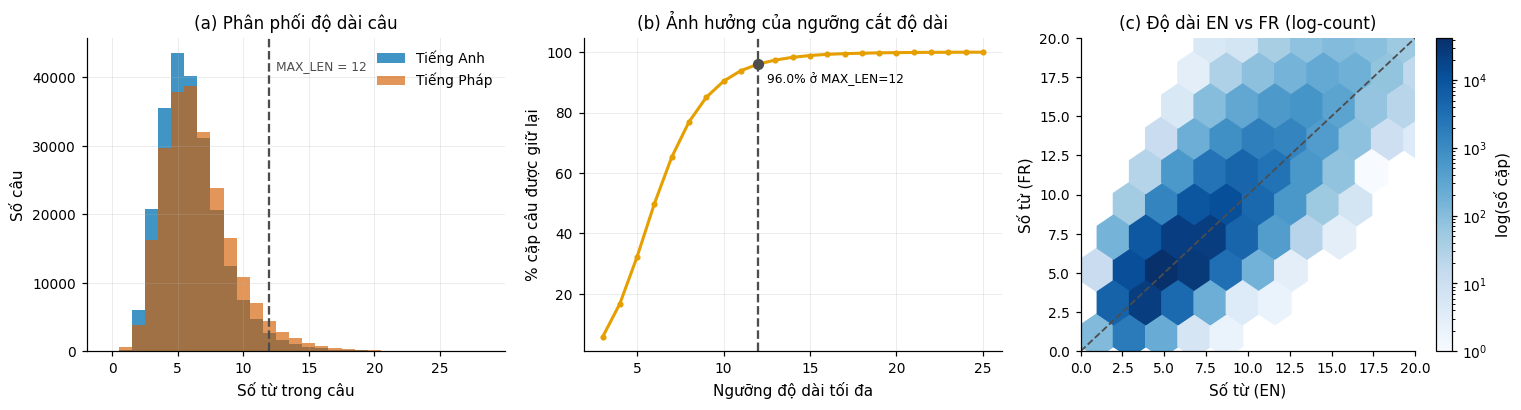

Với MAX_LEN = 12 (theo token thô), giữ lại 96.0% dữ liệu.


In [8]:
# ============================================================================
# EDA 2 — Phân phối độ dài câu
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (a) histogram chồng: 2 series -> có legend
bins = np.arange(0, min(30, raw_df[["en_ntok_raw", "fr_ntok_raw"]].max().max() + 2)) - 0.5
axes[0].hist(raw_df["en_ntok_raw"], bins=bins, alpha=0.75, color=PALETTE["m1"], label="Tiếng Anh")
axes[0].hist(raw_df["fr_ntok_raw"], bins=bins, alpha=0.65, color=PALETTE["m2"], label="Tiếng Pháp")
axes[0].axvline(MAX_LEN, color=PALETTE["neutral"], ls="--", lw=1.5)
axes[0].annotate(f"MAX_LEN = {MAX_LEN}", xy=(MAX_LEN, axes[0].get_ylim()[1] * 0.9),
                 xytext=(4, 0), textcoords="offset points",
                 fontsize=8, color=PALETTE["neutral"])
axes[0].set_xlabel("Số từ trong câu")
axes[0].set_ylabel("Số câu")
axes[0].set_title("(a) Phân phối độ dài câu")
axes[0].legend()

# (b) tỉ lệ dữ liệu giữ lại theo ngưỡng MAX_LEN - 1 series, không cần legend
thresholds = np.arange(3, 26)
keep = [(((raw_df["en_ntok_raw"] <= t) & (raw_df["fr_ntok_raw"] <= t)).mean() * 100)
        for t in thresholds]
axes[1].plot(thresholds, keep, color=PALETTE["accent"], marker="o", markersize=3)
axes[1].axvline(MAX_LEN, color=PALETTE["neutral"], ls="--", lw=1.5)
_cur = ((raw_df["en_ntok_raw"] <= MAX_LEN) & (raw_df["fr_ntok_raw"] <= MAX_LEN)).mean() * 100
axes[1].scatter([MAX_LEN], [_cur], color=PALETTE["neutral"], zorder=5, s=40)
axes[1].annotate(f"{_cur:.1f}% ở MAX_LEN={MAX_LEN}", xy=(MAX_LEN, _cur),
                 xytext=(6, -12), textcoords="offset points", fontsize=8)
axes[1].set_xlabel("Ngưỡng độ dài tối đa")
axes[1].set_ylabel("% cặp câu được giữ lại")
axes[1].set_title("(b) Ảnh hưởng của ngưỡng cắt độ dài")

# (c) quan hệ độ dài EN vs FR (hexbin: sequential 1 hue)
hb = axes[2].hexbin(raw_df["en_ntok_raw"], raw_df["fr_ntok_raw"],
                    gridsize=28, cmap=SEQ_CMAP, mincnt=1, bins="log")
lim = min(25, raw_df["en_ntok_raw"].quantile(0.999))
axes[2].plot([0, lim], [0, lim], color=PALETTE["neutral"], ls="--", lw=1.2)
axes[2].set_xlim(0, lim); axes[2].set_ylim(0, lim)
axes[2].set_xlabel("Số từ (EN)")
axes[2].set_ylabel("Số từ (FR)")
axes[2].set_title("(c) Độ dài EN vs FR (log-count)")
axes[2].grid(False)
fig.colorbar(hb, ax=axes[2], label="log(số cặp)")

plt.tight_layout()
plt.show()

print(f"Với MAX_LEN = {MAX_LEN} (theo token thô), giữ lại {_cur:.1f}% dữ liệu.")

Kích thước từ vựng thô  EN: 16,615 token khác nhau
Kích thước từ vựng thô  FR: 30,274 token khác nhau
  min_freq=1: |V_en|=16,615   |V_fr|=30,274
  min_freq=2: |V_en|=11,637   |V_fr|=19,489
  min_freq=3: |V_en|=9,319   |V_fr|=14,890
  min_freq=5: |V_en|=7,051   |V_fr|=10,724


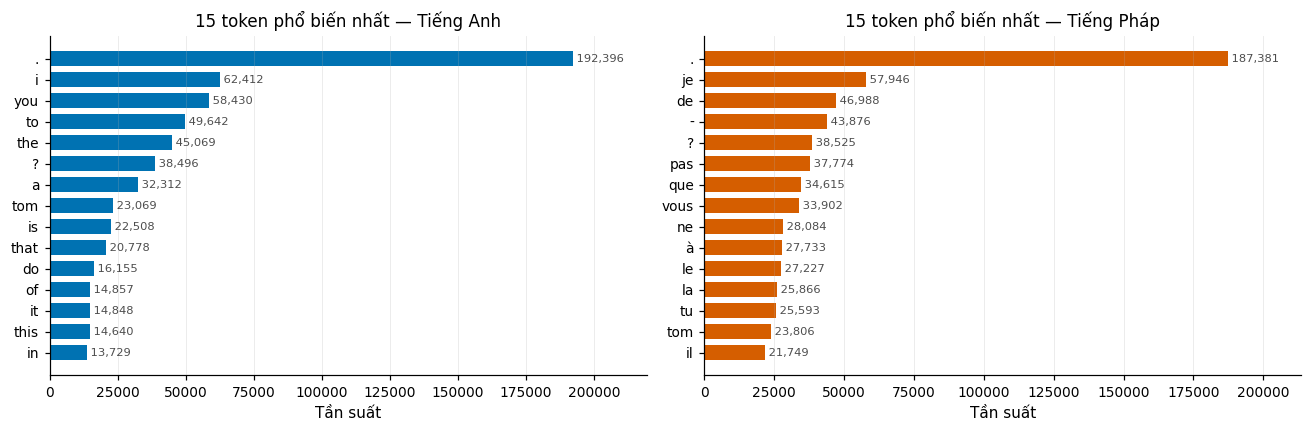


--- 3 cặp NGẮN nhất ---


,en,fr,en_ntok_raw,fr_ntok_raw
0,Go.,Va !,1,2
65,Relax.,Détendez-vous !,1,2
66,Relax.,"Relaxe, Max !",1,3


--- 3 cặp DÀI nhất ---


,en,fr,en_ntok_raw,fr_ntok_raw
229800,If someone who doesn't know your background says that you sound like a nativ...,Si quelqu'un qui ne connaît pas vos antécédents dit que vous parlez comme un...,44,55
229801,It may be impossible to get a completely error-free corpus due to the nature...,Il est peut-être impossible d'obtenir un Corpus complètement dénué de fautes...,47,51
229802,"I went drinking with one of my boyfriend's friends, and now he's furious at ...","« Je suis allée boire avec un ami de mon compagnon, et voilà qu'il est furie...",55,68



Token chỉ xuất hiện 1 lần: EN 30.0%, FR 35.6% -> đây là nguồn gốc chính của <unk>.


In [9]:
# ============================================================================
# EDA 3 — Từ vựng, token phổ biến, câu dài/ngắn nhất
# ============================================================================
def _rough_tokens(s):
    return re.findall(r"[\w']+|[^\w\s]", str(s).lower(), flags=re.UNICODE)

en_counter = Counter()
fr_counter = Counter()
for s in raw_df["en"]:
    en_counter.update(_rough_tokens(s))
for s in raw_df["fr"]:
    fr_counter.update(_rough_tokens(s))

print(f"Kích thước từ vựng thô  EN: {len(en_counter):,} token khác nhau")
print(f"Kích thước từ vựng thô  FR: {len(fr_counter):,} token khác nhau")
for mf in [1, 2, 3, 5]:
    e = sum(1 for _t, c in en_counter.items() if c >= mf)
    f_ = sum(1 for _t, c in fr_counter.items() if c >= mf)
    print(f"  min_freq={mf}: |V_en|={e:,}   |V_fr|={f_:,}")

# --- 15 token phổ biến nhất mỗi ngôn ngữ ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counter, name, color in [
    (axes[0], en_counter, "Tiếng Anh", PALETTE["m1"]),
    (axes[1], fr_counter, "Tiếng Pháp", PALETTE["m2"]),
]:
    top = counter.most_common(15)[::-1]
    labels = [t for t, _c in top]
    vals = [c for _t, c in top]
    ax.barh(labels, vals, color=color, height=0.68)
    for y, v in enumerate(vals):
        ax.text(v, y, f" {v:,}", va="center", fontsize=7.5, color=PALETTE["neutral"])
    ax.set_title(f"15 token phổ biến nhất — {name}")
    ax.set_xlabel("Tần suất")
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.14)
plt.tight_layout()
plt.show()

# --- câu ngắn nhất / dài nhất ---
_srt = raw_df.sort_values("en_ntok_raw")
print("\n--- 3 cặp NGẮN nhất ---")
display(_srt.head(3)[["en", "fr", "en_ntok_raw", "fr_ntok_raw"]])
print("--- 3 cặp DÀI nhất ---")
display(_srt.tail(3)[["en", "fr", "en_ntok_raw", "fr_ntok_raw"]])

# --- tỉ lệ token hiếm (hapax) ---
hapax_en = sum(1 for _t, c in en_counter.items() if c == 1) / len(en_counter) * 100
hapax_fr = sum(1 for _t, c in fr_counter.items() if c == 1) / len(fr_counter) * 100
print(f"\nToken chỉ xuất hiện 1 lần: EN {hapax_en:.1f}%, FR {hapax_fr:.1f}% "
      f"-> đây là nguồn gốc chính của <unk>.")

In [10]:
# ============================================================================
# EDA 4 — Tóm tắt tự động (mọi con số đều lấy từ dữ liệu thật ở trên)
# ============================================================================
_p95_en = raw_df["en_ntok_raw"].quantile(0.95)
_p95_fr = raw_df["fr_ntok_raw"].quantile(0.95)
_lines = [
    "NHẬN XÉT TỰ ĐỘNG TỪ EDA",
    "-----------------------",
    f"- Bộ dữ liệu có {len(raw_df):,} cặp câu song ngữ Anh-Pháp.",
    f"- Độ dài trung bình: EN {raw_df['en_ntok_raw'].mean():.2f} từ, "
    f"FR {raw_df['fr_ntok_raw'].mean():.2f} từ (phân vị 95%: EN {_p95_en:.0f}, FR {_p95_fr:.0f}).",
    f"- Tỉ lệ độ dài FR/EN trung bình = {ratio:.3f} -> câu tiếng Pháp "
    f"{'DÀI hơn' if ratio > 1 else 'NGẮN hơn'} tiếng Anh khoảng {abs(ratio - 1) * 100:.1f}%.",
    f"- Từ vựng thô: |V_en| = {len(en_counter):,}, |V_fr| = {len(fr_counter):,}; "
    f"{hapax_en:.1f}% / {hapax_fr:.1f}% số token chỉ xuất hiện đúng 1 lần.",
    f"- Trùng lặp: {dup_pair:,} cặp trùng hoàn toàn "
    f"({dup_pair / len(raw_df) * 100:.2f}%), {dup_en:,} câu EN xuất hiện nhiều lần "
    f"(một câu Anh có nhiều bản dịch Pháp hợp lệ).",
    f"- Với MAX_LEN = {MAX_LEN}, ta giữ lại {_cur:.1f}% dữ liệu.",
]
print(chr(10).join(_lines))

NHẬN XÉT TỰ ĐỘNG TỪ EDA
-----------------------
- Bộ dữ liệu có 229,803 cặp câu song ngữ Anh-Pháp.
- Độ dài trung bình: EN 6.08 từ, FR 6.63 từ (phân vị 95%: EN 11, FR 12).
- Tỉ lệ độ dài FR/EN trung bình = 1.121 -> câu tiếng Pháp DÀI hơn tiếng Anh khoảng 12.1%.
- Từ vựng thô: |V_en| = 16,615, |V_fr| = 30,274; 30.0% / 35.6% số token chỉ xuất hiện đúng 1 lần.
- Trùng lặp: 0 cặp trùng hoàn toàn (0.00%), 65,625 câu EN xuất hiện nhiều lần (một câu Anh có nhiều bản dịch Pháp hợp lệ).
- Với MAX_LEN = 12, ta giữ lại 96.0% dữ liệu.


### Nhận xét EDA và các quyết định rút ra

**a) Câu rất ngắn.** Đây là kho Anki gồm các câu hội thoại thông dụng, đại đa số dưới 10 từ.
Nhờ vậy seq2seq RNN vẫn học được tốt mà không cần Transformer — và cũng có nghĩa là
**điểm nghẽn context-vector của Mô hình 1 sẽ không quá nghiêm trọng ở câu ngắn**,
nhưng sẽ lộ rõ ở nhóm câu dài. Ta sẽ kiểm chứng điều này bằng biểu đồ **BLEU theo nhóm độ dài**.

**b) Tiếng Pháp dài hơn tiếng Anh.** Do tiếng Pháp dùng nhiều mạo từ, giới từ và cấu trúc
phân tích (`ne … pas`, `est-ce que`, `il y a`). Hệ quả: độ dài giải mã tối đa của decoder
phải lớn hơn độ dài câu nguồn — ta đặt `MAX_DECODE = MAX_LEN + 2`.

**c) Đuôi từ vựng rất dài (hapax cao).** Phần lớn token chỉ xuất hiện 1 lần (tên riêng,
dạng chia động từ hiếm). Đặt `MIN_FREQ = 2` cắt bỏ phần lớn đuôi này, giảm mạnh kích thước
lớp softmax đầu ra (chi phí tính toán lớn nhất của mô hình) mà chỉ mất một tỉ lệ nhỏ token
thực tế. Cái giá phải trả là `<unk>` — đây chính là lý do ta sẽ **đề xuất subword/BPE** ở phần cải thiện.

**d) Một câu Anh có nhiều bản dịch Pháp.** Việc này là **bình thường và hợp lệ** trong dịch máy
(nhiều bản dịch đều đúng). Tuy nhiên nó khiến chỉ số **exact-match rất khắt khe** (mô hình dịch
đúng nghĩa vẫn bị tính sai nếu chọn biến thể khác) → **BLEU/chrF là chỉ số đáng tin hơn**.
Ta vẫn loại các cặp trùng **hoàn toàn** (cả EN lẫn FR) để tránh rò rỉ dữ liệu giữa train và test.

---
# Phần 3 — Tiền xử lý

Quy trình chuẩn hoá được thiết kế để **giữ nguyên đặc trưng tiếng Pháp**:

| Bước | Mô tả | Lý do |
|---|---|---|
| 1. Unicode **NFC** | Gộp ký tự + dấu tổ hợp thành 1 codepoint (`e` + `́` → `é`) | Cùng một chữ `é` có thể được mã hoá 2 cách khác nhau → nếu không chuẩn hoá sẽ thành 2 token khác nhau |
| 2. Xoá ký tự điều khiển / NBSP | ` `, ` ` → khoảng trắng thường | Anki/Tatoeba dùng nhiều non-breaking space trước `?` `!` `:` (quy tắc chính tả Pháp) |
| 3. `lower()` | Chữ thường | Giảm ~15–20% kích thước từ vựng; bài toán không cần phân biệt hoa/thường |
| 4. Tách dấu câu | `Va-t'en!` → `va-t ' en !` | Không để `mot!` và `mot` thành 2 token khác nhau |
| 5. **KHÔNG** bỏ dấu | Giữ nguyên `é è ê à â ç ù û ô î ë ï œ æ` | Bỏ dấu sẽ phá nghĩa tiếng Pháp (`a` ≠ `à`, `ou` ≠ `où`) |
| 6. Gộp khoảng trắng | nhiều space → 1 space | |

Sau đó thêm 4 token đặc biệt:

```
<pad> = 0   đệm câu ngắn cho bằng độ dài  (bị BỎ QUA trong loss và accuracy)
<sos> = 1   bắt đầu câu đích  (đầu vào đầu tiên của decoder)
<eos> = 2   kết thúc câu       (tín hiệu dừng khi giải mã)
<unk> = 3   token ngoài từ điển (out-of-vocabulary)
```

**Định dạng chuỗi đích:** `<sos> y1 y2 … yN <eos>`.
Khi huấn luyện, decoder nhận đầu vào `trg[:, :-1]` (`<sos> y1 … yN`) và phải dự đoán
`trg[:, 1:]` (`y1 … yN <eos>`) — đây là chỗ **rất dễ sai off-by-one**, ta xử lý dứt điểm
trong hàm `forward` của lớp `Seq2Seq`.

In [11]:
# ============================================================================
# TIỀN XỬ LÝ: chuẩn hoá + tokenise
# ============================================================================
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<pad>", "<sos>", "<eos>", "<unk>"
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
SPECIALS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Ký tự điều khiển / khoảng trắng đặc biệt cần thay bằng space thường
_WS_RE = re.compile(r"[   ​\t\r\n]+")
# Ký tự được GIỮ LẠI: chữ cái latin (kể cả có dấu), số, dấu nháy, gạch nối, dấu câu cơ bản
_KEEP_RE = re.compile(r"[^a-z0-9à-öø-ÿœæ'\-\.,!\?;:\"()« »]+", flags=re.UNICODE)
# Tách dấu câu ra khỏi từ
_PUNCT_RE = re.compile(r"([\.,!\?;:\"()«»])")


def normalize_text(s: str) -> str:
    """Chuẩn hoá 1 câu: NFC -> bỏ ký tự lạ -> lowercase -> tách dấu câu -> gộp space."""
    s = unicodedata.normalize("NFC", str(s))
    s = _WS_RE.sub(" ", s)
    s = s.lower().strip()
    s = _PUNCT_RE.sub(r" \1 ", s)        # tách dấu câu
    s = s.replace("'", " ' ")            # tách dấu nháy đơn: "j'ai" -> "j ' ai"
    s = _KEEP_RE.sub(" ", s)             # bỏ emoji / ký tự ngoài bảng chữ cái
    s = re.sub(r"\s+", " ", s).strip()
    return s


def tokenize(s: str):
    """Tách câu ĐÃ chuẩn hoá thành danh sách token (chỉ cần split vì đã tách sẵn)."""
    return s.split()


# --- Minh hoạ trước / sau ----------------------------------------------------
_demo = raw_df.sample(6, random_state=GLOBAL_SEED)
_rows = []
for _, r in _demo.iterrows():
    _rows.append({
        "EN gốc": r["en"],
        "EN sau chuẩn hoá": normalize_text(r["en"]),
        "FR gốc": r["fr"],
        "FR sau chuẩn hoá": normalize_text(r["fr"]),
    })
print("VÍ DỤ TRƯỚC / SAU KHI CHUẨN HOÁ")
display(pd.DataFrame(_rows))

# --- Kiểm tra nhanh: dấu tiếng Pháp phải được giữ nguyên ---------------------
_t = "Où est-ce qu'il a mis mon café ?  Ça coûte 5€ !"
print("\nKiểm tra giữ dấu tiếng Pháp:")
print("  gốc     :", _t)
print("  chuẩn hoá:", normalize_text(_t))
print("  token    :", tokenize(normalize_text(_t)))
assert "où" in tokenize(normalize_text(_t)), "Dấu tiếng Pháp bị mất!"
assert "café" in tokenize(normalize_text(_t)), "Dấu tiếng Pháp bị mất!"
print("  -> OK: dấu tiếng Pháp được giữ nguyên.")

VÍ DỤ TRƯỚC / SAU KHI CHUẨN HOÁ


,EN gốc,EN sau chuẩn hoá,FR gốc,FR sau chuẩn hoá
0,"If you give me a book, I'll read it.","if you give me a book , i ' ll read it .","Si vous me donnez un livre, je le lirai.","si vous me donnez un livre , je le lirai ."
1,"We'll leave tomorrow, weather permitting.","we ' ll leave tomorrow , weather permitting .","Nous partirons demain, si le temps le permet.","nous partirons demain , si le temps le permet ."
2,"I'm so happy, I feel like I could fly.","i ' m so happy , i feel like i could fly .",Je suis si heureux que je m'élève dans le ciel.,je suis si heureux que je m ' élève dans le ciel .
3,Pull over here.,pull over here .,Arrêtez-vous ici !,arrêtez-vous ici !
4,Moses came down from the mountain bearing divine commandments.,moses came down from the mountain bearing divine commandments .,Moïse descendit de la montagne en portant les commandements divins.,moïse descendit de la montagne en portant les commandements divins .
5,I appreciate your time.,i appreciate your time .,Je te suis reconnaissant pour ton temps.,je te suis reconnaissant pour ton temps .



Kiểm tra giữ dấu tiếng Pháp:
  gốc     : Où est-ce qu'il a mis mon café ?  Ça coûte 5€ !
  chuẩn hoá: où est-ce qu ' il a mis mon café ? ça coûte 5 !
  token    : ['où', 'est-ce', 'qu', "'", 'il', 'a', 'mis', 'mon', 'café', '?', 'ça', 'coûte', '5', '!']
  -> OK: dấu tiếng Pháp được giữ nguyên.


In [12]:
# ============================================================================
# ÁP DỤNG TIỀN XỬ LÝ + LỌC ĐỘ DÀI + LẤY MẪU (nếu MAX_PAIRS)
# ============================================================================
t0 = time.time()
work = raw_df[["en", "fr"]].copy()

# 1) chuẩn hoá
work["en_norm"] = work["en"].map(normalize_text)
work["fr_norm"] = work["fr"].map(normalize_text)

# 2) tokenise
work["en_tok"] = work["en_norm"].map(tokenize)
work["fr_tok"] = work["fr_norm"].map(tokenize)
work["en_len"] = work["en_tok"].map(len)
work["fr_len"] = work["fr_tok"].map(len)

n0 = len(work)

# 3) bỏ câu rỗng
work = work[(work["en_len"] > 0) & (work["fr_len"] > 0)]
n1 = len(work)

# 4) bỏ trùng lặp HOÀN TOÀN (tránh rò rỉ train -> test)
work = work.drop_duplicates(subset=["en_norm", "fr_norm"])
n2 = len(work)

# 5) lọc theo MAX_LEN
work = work[(work["en_len"] <= MAX_LEN) & (work["fr_len"] <= MAX_LEN)]
n3 = len(work)

# 6) lấy mẫu ngẫu nhiên nếu giới hạn MAX_PAIRS
#    (dữ liệu Anki được sắp theo độ khó tăng dần -> BẮT BUỘC lấy mẫu ngẫu nhiên,
#     nếu cắt N dòng đầu ta chỉ nhận được toàn câu 2-3 từ)
if MAX_PAIRS is not None and len(work) > MAX_PAIRS:
    work = work.sample(n=MAX_PAIRS, random_state=GLOBAL_SEED)
n4 = len(work)

work = work.reset_index(drop=True)

print("PIPELINE LỌC DỮ LIỆU")
print(f"  0. Ban đầu                       : {n0:,}")
print(f"  1. Sau khi bỏ câu rỗng           : {n1:,}   (-{n0 - n1:,})")
print(f"  2. Sau khi bỏ cặp trùng hoàn toàn: {n2:,}   (-{n1 - n2:,})")
print(f"  3. Sau khi lọc MAX_LEN={MAX_LEN:<3}       : {n3:,}   (-{n2 - n3:,})")
print(f"  4. Sau khi lấy mẫu MAX_PAIRS     : {n4:,}   (-{n3 - n4:,})")
print(f"\n  Tỉ lệ giữ lại so với ban đầu: {n4 / n0 * 100:.2f}%")
print(f"  Thời gian tiền xử lý: {time.time() - t0:.1f}s")
print(f"\n  Độ dài TB sau lọc: EN {work['en_len'].mean():.2f} token, FR {work['fr_len'].mean():.2f} token")
display(work[["en_norm", "fr_norm", "en_len", "fr_len"]].head())

PIPELINE LỌC DỮ LIỆU
  0. Ban đầu                       : 229,803
  1. Sau khi bỏ câu rỗng           : 229,803   (-0)
  2. Sau khi bỏ cặp trùng hoàn toàn: 229,457   (-346)
  3. Sau khi lọc MAX_LEN=12        : 200,738   (-28,719)
  4. Sau khi lấy mẫu MAX_PAIRS     : 4,000   (-196,738)

  Tỉ lệ giữ lại so với ban đầu: 1.74%
  Thời gian tiền xử lý: 4.3s

  Độ dài TB sau lọc: EN 7.26 token, FR 7.64 token


,en_norm,fr_norm,en_len,fr_len
0,"tom isn ' t rude , but mary is .",tom n ' est pas dur mais mary l ' est .,10,12
1,who ' s that girl ?,qui est cette fille ?,6,5
2,i need this more than you .,j ' en ai plus besoin que toi .,7,9
3,he ' ll never beat me .,il ne me battra jamais .,7,6
4,i don ' t know what it was .,je ne sais pas ce que c ' était .,9,10


In [13]:
# ============================================================================
# LỚP VOCAB
# ============================================================================
class Vocab:
    """Từ điển ánh xạ token <-> chỉ số, có <pad>/<sos>/<eos>/<unk> cố định ở đầu."""

    def __init__(self, name="vocab"):
        self.name = name
        self.itos = list(SPECIALS)
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.freqs = Counter()

    @classmethod
    def build(cls, token_lists, min_freq=1, max_size=None, name="vocab"):
        v = cls(name)
        for toks in token_lists:
            v.freqs.update(toks)
        # sắp xếp: tần suất giảm dần, rồi theo alphabet -> tái lập được 100%
        items = sorted(v.freqs.items(), key=lambda kv: (-kv[1], kv[0]))
        for tok, cnt in items:
            if cnt < min_freq:
                continue
            if max_size is not None and len(v.itos) >= max_size:
                break
            if tok not in v.stoi:
                v.stoi[tok] = len(v.itos)
                v.itos.append(tok)
        return v

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens, add_sos=False, add_eos=False):
        ids = [self.stoi.get(t, UNK_IDX) for t in tokens]
        if add_sos:
            ids = [SOS_IDX] + ids
        if add_eos:
            ids = ids + [EOS_IDX]
        return ids

    def decode(self, ids, strip_special=True):
        toks = []
        for i in ids:
            i = int(i)
            if strip_special and i in (PAD_IDX, SOS_IDX):
                continue
            if i == EOS_IDX:
                break
            toks.append(self.itos[i] if 0 <= i < len(self.itos) else UNK_TOKEN)
        return toks

    def coverage(self, token_lists):
        """Tỉ lệ token nằm trong từ điển (1 - tỉ lệ <unk>)."""
        tot = hit = 0
        for toks in token_lists:
            for t in toks:
                tot += 1
                hit += int(t in self.stoi)
        return hit / max(1, tot)


# QUAN TRỌNG: từ điển được xây trên TOÀN BỘ corpus đã lọc, TRƯỚC khi chia tập.
# Với bài toán dịch máy ở quy mô bài tập, đây là cách làm phổ biến; nhược điểm là
# tập test không còn <unk> "tự nhiên". Ở ô sau khi chia tập, ta sẽ xây LẠI từ điển
# CHỈ từ tập train để đánh giá trung thực, và in ra độ phủ trên tập test.
print("Đã định nghĩa lớp Vocab. Từ điển sẽ được xây từ TẬP TRAIN ở phần sau.")

Đã định nghĩa lớp Vocab. Từ điển sẽ được xây từ TẬP TRAIN ở phần sau.


---
# Phần 4 — Chia dữ liệu **60 : 20 : 20** với **random seed = 45**

> **Yêu cầu bắt buộc của đề bài.** Ta dùng `sklearn.model_selection.train_test_split`
> **hai lần** với `random_state=45` ở cả hai lần:
>
> 1. Lần 1: tách **40%** ra khỏi toàn bộ → `train (60%)` và `temp (40%)`
> 2. Lần 2: chia đôi `temp` → `val (20%)` và `test (20%)`
>
> `SPLIT_SEED = 45` được khai báo ở ô cấu hình đầu notebook và **không dùng cho việc gì khác**
> (khởi tạo trọng số và shuffle dùng `GLOBAL_SEED = 42`), đúng như yêu cầu "random seed = 45"
> cho phần *phân chia dữ liệu*.

Sau khi chia, **từ điển được xây LẠI chỉ từ tập train** — đây là điểm mấu chốt để tránh
rò rỉ thông tin (data leakage): nếu xây từ điển trên cả tập test thì mô hình "biết trước"
các từ chỉ xuất hiện trong test, làm kết quả đẹp giả tạo.

In [14]:
# ============================================================================
# CHIA DỮ LIỆU 60 : 20 : 20  —  random_state = SPLIT_SEED = 45  (THEO ĐỀ BÀI)
# ============================================================================
from sklearn.model_selection import train_test_split

assert SPLIT_SEED == 45, "Đề bài yêu cầu random seed = 45 cho việc chia dữ liệu!"

# Lần 1: 60% train / 40% còn lại
train_df, temp_df = train_test_split(
    work, test_size=0.40, random_state=SPLIT_SEED, shuffle=True
)
# Lần 2: chia đôi phần 40% -> 20% val / 20% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SPLIT_SEED, shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

N = len(work)
print("KẾT QUẢ CHIA DỮ LIỆU (random_state = %d)" % SPLIT_SEED)
print("-" * 56)
for nm, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {nm:<11}: {len(d):>7,} mẫu   ({len(d) / N * 100:5.2f}%)")
print("-" * 56)
print(f"  {'TỔNG':<11}: {len(train_df) + len(val_df) + len(test_df):>7,} mẫu   (100.00%)")

# --- Kiểm tra bằng assert ----------------------------------------------------
# dung sai = 1 mẫu (khi N không chia hết cho 5), tối thiểu 0.1%
TOL = max(0.001, 1.5 / N)
assert len(train_df) + len(val_df) + len(test_df) == N, "Tổng số mẫu không khớp!"
assert abs(len(train_df) / N - 0.60) < TOL, f"Tỉ lệ train sai: {len(train_df) / N:.4f}"
assert abs(len(val_df) / N - 0.20) < TOL, f"Tỉ lệ val sai: {len(val_df) / N:.4f}"
assert abs(len(test_df) / N - 0.20) < TOL, f"Tỉ lệ test sai: {len(test_df) / N:.4f}"
print(f"\n  [OK] Tỉ lệ 60:20:20 đã được kiểm chứng bằng assert (dung sai {TOL * 100:.3f}%).")

# --- Không chồng lấn giữa các tập (kiểm tra rò rỉ) ---------------------------
_tr = set(zip(train_df["en_norm"], train_df["fr_norm"]))
_va = set(zip(val_df["en_norm"], val_df["fr_norm"]))
_te = set(zip(test_df["en_norm"], test_df["fr_norm"]))
print(f"  Chồng lấn train∩test = {len(_tr & _te)} cặp, train∩val = {len(_tr & _va)} cặp "
      f"(kỳ vọng 0 vì đã bỏ trùng ở bước tiền xử lý).")

# --- Phân phối độ dài giữa 3 tập phải tương đồng -----------------------------
_stats = pd.DataFrame({
    "Tập": ["Train", "Val", "Test"],
    "Số mẫu": [len(train_df), len(val_df), len(test_df)],
    "EN len TB": [train_df["en_len"].mean(), val_df["en_len"].mean(), test_df["en_len"].mean()],
    "FR len TB": [train_df["fr_len"].mean(), val_df["fr_len"].mean(), test_df["fr_len"].mean()],
    "EN len max": [train_df["en_len"].max(), val_df["en_len"].max(), test_df["en_len"].max()],
    "FR len max": [train_df["fr_len"].max(), val_df["fr_len"].max(), test_df["fr_len"].max()],
}).round(2)
print()
display(_stats)

KẾT QUẢ CHIA DỮ LIỆU (random_state = 45)
--------------------------------------------------------
  Train      :   2,400 mẫu   (60.00%)
  Validation :     800 mẫu   (20.00%)
  Test       :     800 mẫu   (20.00%)
--------------------------------------------------------
  TỔNG       :   4,000 mẫu   (100.00%)

  [OK] Tỉ lệ 60:20:20 đã được kiểm chứng bằng assert (dung sai 0.100%).
  Chồng lấn train∩test = 0 cặp, train∩val = 0 cặp (kỳ vọng 0 vì đã bỏ trùng ở bước tiền xử lý).



,Tập,Số mẫu,EN len TB,FR len TB,EN len max,FR len max
0,Train,2400,7.24,7.62,12,12
1,Val,800,7.29,7.62,12,12
2,Test,800,7.30,7.73,12,12


In [15]:
# ============================================================================
# XÂY TỪ ĐIỂN **CHỈ TỪ TẬP TRAIN** (tránh data leakage)
# ============================================================================
src_vocab = Vocab.build(train_df["en_tok"].tolist(), min_freq=MIN_FREQ, name="EN(src)")
trg_vocab = Vocab.build(train_df["fr_tok"].tolist(), min_freq=MIN_FREQ, name="FR(trg)")

SRC_VOCAB_SIZE = len(src_vocab)
TRG_VOCAB_SIZE = len(trg_vocab)

print(f"|V_src| (EN) = {SRC_VOCAB_SIZE:,}   (min_freq={MIN_FREQ})")
print(f"|V_trg| (FR) = {TRG_VOCAB_SIZE:,}   (min_freq={MIN_FREQ})")
print(f"\n10 token EN đầu tiên: {src_vocab.itos[:14]}")
print(f"10 token FR đầu tiên: {trg_vocab.itos[:14]}")

print("\nĐỘ PHỦ TỪ ĐIỂN (tỉ lệ token KHÔNG bị thay bằng <unk>)")
for nm, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    cs = src_vocab.coverage(d["en_tok"].tolist()) * 100
    ct = trg_vocab.coverage(d["fr_tok"].tolist()) * 100
    print(f"  {nm:<6}: EN {cs:5.2f}%   FR {ct:5.2f}%")
print("\n  -> Phần thiếu chính là tỉ lệ <unk>; đây là lý do ta đề xuất subword/BPE ở phần cải thiện.")

# --- Ví dụ numericalisation --------------------------------------------------
print("\nVÍ DỤ NUMERICALISATION")
print("=" * 78)
for i in range(3):
    r = train_df.iloc[i]
    sid = src_vocab.encode(r["en_tok"], add_sos=False, add_eos=True)
    tid = trg_vocab.encode(r["fr_tok"], add_sos=True, add_eos=True)
    print(f"[{i}] EN  : {r['en_norm']}")
    print(f"    tok : {r['en_tok']}")
    print(f"    ids : {sid}          <- có <eos>={EOS_IDX} ở cuối")
    print(f"    FR  : {r['fr_norm']}")
    print(f"    tok : {r['fr_tok']}")
    print(f"    ids : {tid}          <- có <sos>={SOS_IDX} đầu và <eos>={EOS_IDX} cuối")
    print(f"    giải mã ngược: {' '.join(trg_vocab.decode(tid))}")
    print("-" * 78)

|V_src| (EN) = 2,137   (min_freq=1)
|V_trg| (FR) = 2,955   (min_freq=1)

10 token EN đầu tiên: ['<pad>', '<sos>', '<eos>', '<unk>', '.', 'i', "'", 'you', 'to', 'the', '?', 'a', 't', 'tom']
10 token FR đầu tiên: ['<pad>', '<sos>', '<eos>', '<unk>', '.', "'", 'je', 'de', '?', 'pas', 'est', 'que', 'la', 'ne']

ĐỘ PHỦ TỪ ĐIỂN (tỉ lệ token KHÔNG bị thay bằng <unk>)
  Train : EN 100.00%   FR 100.00%
  Val   : EN 93.45%   FR 90.66%
  Test  : EN 92.26%   FR 90.23%

  -> Phần thiếu chính là tỉ lệ <unk>; đây là lý do ta đề xuất subword/BPE ở phần cải thiện.

VÍ DỤ NUMERICALISATION
[0] EN  : don ' t do that now .
    tok : ['don', "'", 't', 'do', 'that', 'now', '.']
    ids : [29, 6, 12, 16, 15, 82, 4, 2]          <- có <eos>=2 ở cuối
    FR  : ne fais pas ça maintenant .
    tok : ['ne', 'fais', 'pas', 'ça', 'maintenant', '.']
    ids : [1, 13, 150, 9, 35, 118, 4, 2]          <- có <sos>=1 đầu và <eos>=2 cuối
    giải mã ngược: ne fais pas ça maintenant .
----------------------------------------

---
# Phần 5 — `Dataset`, `collate_fn` và `DataLoader`

**Ba chi tiết kỹ thuật quan trọng:**

1. **Padding động theo batch.** `collate_fn` chỉ đệm tới độ dài dài nhất *trong batch*
   thay vì `MAX_LEN` cố định → tiết kiệm đáng kể phép tính.
2. **Length bucketing.** `LengthGroupedSampler` gom các câu có độ dài gần nhau vào cùng batch
   (nhưng vẫn xáo trộn giữa các batch) → giảm số token `<pad>`, tăng tốc ~20–30%.
3. **`src_len` phải nằm trên CPU.** `pack_padded_sequence` yêu cầu tensor độ dài ở CPU
   (dù dữ liệu ở GPU), và ta dùng `enforce_sorted=False` để khỏi phải sắp xếp lại batch.

Cấu hình Colab: `num_workers=2`, `pin_memory=True` (khi có GPU).

In [16]:
# ============================================================================
# DATASET + COLLATE + SAMPLER
# ============================================================================
class TranslationDataset(Dataset):
    """Mỗi phần tử: (src_ids [..., <eos>], trg_ids [<sos>, ..., <eos>])."""

    def __init__(self, df, src_vocab, trg_vocab):
        self.src = [src_vocab.encode(t, add_sos=False, add_eos=True) for t in df["en_tok"]]
        self.trg = [trg_vocab.encode(t, add_sos=True, add_eos=True) for t in df["fr_tok"]]
        self.src_text = df["en_norm"].tolist()
        self.trg_text = df["fr_norm"].tolist()
        self.src_tok = df["en_tok"].tolist()
        self.trg_tok = df["fr_tok"].tolist()

    def __len__(self):
        return len(self.src)

    def __getitem__(self, i):
        return torch.tensor(self.src[i], dtype=torch.long), \
               torch.tensor(self.trg[i], dtype=torch.long)


def collate_fn(batch):
    """Đệm động theo batch. Trả về (src, src_len, trg)."""
    srcs, trgs = zip(*batch)
    src_len = torch.tensor([len(s) for s in srcs], dtype=torch.long)  # GIỮ Ở CPU
    max_s = int(src_len.max())
    max_t = max(len(t) for t in trgs)

    src = torch.full((len(batch), max_s), PAD_IDX, dtype=torch.long)
    trg = torch.full((len(batch), max_t), PAD_IDX, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, trgs)):
        src[i, :len(s)] = s
        trg[i, :len(t)] = t
    return src, src_len, trg


class LengthGroupedSampler(torch.utils.data.Sampler):
    """Gom câu có độ dài gần nhau vào cùng batch nhưng vẫn ngẫu nhiên hoá thứ tự batch."""

    def __init__(self, lengths, batch_size, shuffle=True, mega_batch=50, seed=0):
        self.lengths = list(lengths)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.mega = batch_size * mega_batch
        self.seed = seed
        self.epoch = 0

    def __len__(self):
        return len(self.lengths)

    def set_epoch(self, e):
        self.epoch = e

    def __iter__(self):
        n = len(self.lengths)
        idx = np.arange(n)
        if self.shuffle:
            rng = np.random.default_rng(self.seed + self.epoch)
            rng.shuffle(idx)
        # trong mỗi "mega batch", sắp theo độ dài
        chunks = [idx[i:i + self.mega] for i in range(0, n, self.mega)]
        chunks = [c[np.argsort([self.lengths[j] for j in c], kind="stable")] for c in chunks]
        idx = np.concatenate(chunks) if chunks else idx
        # xáo trộn thứ tự các batch (không xáo trộn bên trong batch)
        batches = [idx[i:i + self.batch_size] for i in range(0, n, self.batch_size)]
        if self.shuffle:
            rng = np.random.default_rng(self.seed + self.epoch + 9999)
            rng.shuffle(batches)
        return iter(int(j) for b in batches for j in b)


train_ds = TranslationDataset(train_df, src_vocab, trg_vocab)
val_ds   = TranslationDataset(val_df,   src_vocab, trg_vocab)
test_ds  = TranslationDataset(test_df,  src_vocab, trg_vocab)

PIN = (DEVICE.type == "cuda")


def make_loaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    g = torch.Generator()
    g.manual_seed(GLOBAL_SEED)
    train_sampler = LengthGroupedSampler(
        [len(s) for s in train_ds.src], batch_size, shuffle=True, seed=GLOBAL_SEED
    )
    tl = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler,
                    collate_fn=collate_fn, num_workers=num_workers,
                    pin_memory=PIN, drop_last=False, generator=g,
                    persistent_workers=bool(num_workers))
    vl = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False,
                    collate_fn=collate_fn, num_workers=num_workers, pin_memory=PIN,
                    persistent_workers=bool(num_workers))
    te = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False,
                    collate_fn=collate_fn, num_workers=num_workers, pin_memory=PIN,
                    persistent_workers=bool(num_workers))
    return tl, vl, te, train_sampler


train_loader, val_loader, test_loader, train_sampler = make_loaders()

# --- Kiểm tra 1 batch --------------------------------------------------------
_sb, _sl, _tb = next(iter(train_loader))
print(f"src   : {tuple(_sb.shape)}  dtype={_sb.dtype}   (B, S)")
print(f"src_len: {tuple(_sl.shape)}  device={_sl.device}  <- PHẢI ở CPU cho pack_padded_sequence")
print(f"trg   : {tuple(_tb.shape)}  dtype={_tb.dtype}   (B, T)")
print(f"\nTỉ lệ token <pad> trong batch: src {(_sb == PAD_IDX).float().mean() * 100:.1f}%, "
      f"trg {(_tb == PAD_IDX).float().mean() * 100:.1f}%")
print(f"\nSố batch: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

print("\nMẫu đầu tiên trong batch:")
print("  src ids :", _sb[0].tolist())
print("  src text:", " ".join(src_vocab.decode(_sb[0].tolist())))
print("  trg ids :", _tb[0].tolist())
print("  trg text:", " ".join(trg_vocab.decode(_tb[0].tolist())))
print("\n  decoder INPUT  = trg[:, :-1] ->", _tb[0][:-1].tolist())
print("  decoder TARGET = trg[:, 1: ] ->", _tb[0][1:].tolist())
print("  (lệch nhau đúng 1 bước: dự đoán token kế tiếp)")

src   : (128, 7)  dtype=torch.int64   (B, S)
src_len: (128,)  device=cpu  <- PHẢI ở CPU cho pack_padded_sequence
trg   : (128, 13)  dtype=torch.int64   (B, T)

Tỉ lệ token <pad> trong batch: src 12.6%, trg 39.7%

Số batch: train=19, val=4, test=4

Mẫu đầu tiên trong batch:
  src ids : [15, 14, 54, 544, 119, 2, 0]
  src text: that is very expensive !
  trg ids : [1, 37, 5, 10, 430, 751, 39, 2, 0, 0, 0, 0, 0]
  trg text: c ' est fort cher !

  decoder INPUT  = trg[:, :-1] -> [1, 37, 5, 10, 430, 751, 39, 2, 0, 0, 0, 0]
  decoder TARGET = trg[:, 1: ] -> [37, 5, 10, 430, 751, 39, 2, 0, 0, 0, 0, 0]
  (lệch nhau đúng 1 bước: dự đoán token kế tiếp)


---
# Phần 6 — **Mô hình 1**: RNN Encoder–Decoder **KHÔNG** Attention

## 6.1. Encoder (dùng chung cho cả 2 mô hình)

`EncoderRNN` = Embedding → (Bi)GRU → projection.

**Xử lý đúng hidden state khi bidirectional / nhiều lớp** (lỗi kinh điển của seq2seq):

PyTorch trả `hidden` có shape `(n_layers * n_directions, B, H)` với thứ tự
`[layer0_fw, layer0_bw, layer1_fw, layer1_bw, …]`. Không thể `view(n_layers, B, 2*H)`
một cách ngây thơ. Cách đúng:

```python
hidden = hidden.view(n_layers, n_dir, B, H)      # tách đúng trục
h_cat  = torch.cat([hidden[:, 0], hidden[:, 1]], dim=2)   # (n_layers, B, 2H)
hidden = torch.tanh(self.fc_hidden(h_cat))                # (n_layers, B, H)
```

Encoder outputs cũng được chiếu từ `2H → H` để decoder và attention dùng chung số chiều `H`.

Ngoài ra dùng `pack_padded_sequence(..., enforce_sorted=False, batch_first=True)` với
`lengths` **trên CPU**, và `pad_packed_sequence(..., total_length=S)` để chiều thời gian
luôn khớp với mask PAD.

## 6.2. Decoder KHÔNG attention

Decoder chỉ nhận **một** vector ngữ cảnh `c = h_T` (lớp trên cùng của encoder) và
**lặp lại chính vector đó ở mọi bước**:

```
input_t = [ Emb(y_{t-1}) ; c ]          (E + H chiều)
s_t     = GRU(input_t, s_{t-1})
logits  = Linear([ s_t ; c ; Emb(y_{t-1}) ])      -> |V_fr|
```

Việc nối thêm `c` vào đầu vào GRU (thay vì chỉ dùng làm hidden khởi tạo) là kỹ thuật của
Cho et al. 2014, giúp mô hình không "quên" câu nguồn sau vài bước.
**Đây chính là nút cổ chai:** mọi thông tin của câu nguồn phải đi qua đúng `H` số thực.

In [17]:
# ============================================================================
# ENCODER (dùng chung cho Mô hình 1 và Mô hình 2)
# ============================================================================
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers=1,
                 dropout=0.2, bidirectional=True, cell="GRU", pad_idx=PAD_IDX):
        super().__init__()
        assert cell in ("GRU", "LSTM"), "cell phải là 'GRU' hoặc 'LSTM'"
        self.cell = cell
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.bidirectional = bidirectional
        self.n_dir = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        rnn_cls = nn.GRU if cell == "GRU" else nn.LSTM
        self.rnn = rnn_cls(
            emb_dim, hid_dim, num_layers=n_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        if bidirectional:
            # chiếu 2H -> H cho CẢ outputs lẫn hidden state
            self.fc_out = nn.Linear(hid_dim * 2, hid_dim)
            self.fc_hid = nn.Linear(hid_dim * 2, hid_dim)

    def _merge_hidden(self, h, B):
        """(n_layers*n_dir, B, H) -> (n_layers, B, H) khi bidirectional."""
        if not self.bidirectional:
            return h
        h = h.view(self.n_layers, self.n_dir, B, self.hid_dim)
        h = torch.cat([h[:, 0], h[:, 1]], dim=2)          # (n_layers, B, 2H)
        return torch.tanh(self.fc_hid(h))                  # (n_layers, B, H)

    def forward(self, src, src_len):
        """src: (B, S) đã đệm PAD; src_len: (B,) TRÊN CPU.
        Trả về: enc_out (B, S, H), hidden (dạng phù hợp với decoder)."""
        B, S = src.shape
        emb = self.dropout(self.embedding(src))            # (B, S, E)

        packed = pack_padded_sequence(
            emb, src_len.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, hidden = self.rnn(packed)
        enc_out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=S)

        if self.bidirectional:
            enc_out = self.fc_out(enc_out)                 # (B, S, H)

        if self.cell == "LSTM":
            h, c = hidden
            hidden = (self._merge_hidden(h, B), self._merge_hidden(c, B))
        else:
            hidden = self._merge_hidden(hidden, B)         # (n_layers, B, H)
        return enc_out, hidden


def top_hidden(hidden):
    """Lấy hidden state của LỚP TRÊN CÙNG, shape (B, H). Hỗ trợ cả GRU và LSTM."""
    h = hidden[0] if isinstance(hidden, tuple) else hidden
    return h[-1]


print("Đã định nghĩa EncoderRNN.")

Đã định nghĩa EncoderRNN.


In [18]:
# ============================================================================
# MÔ HÌNH 1 — DECODER KHÔNG ATTENTION
# ============================================================================
class DecoderRNN(nn.Module):
    """Decoder chỉ nhận MỘT context vector cố định c = h_T (không attention)."""

    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers=1,
                 dropout=0.2, cell="GRU", pad_idx=PAD_IDX):
        super().__init__()
        self.cell = cell
        self.vocab_size = vocab_size
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        rnn_cls = nn.GRU if cell == "GRU" else nn.LSTM
        # đầu vào GRU = [embedding ; context]  -> giữ context ở MỌI bước (Cho et al. 2014)
        self.rnn = rnn_cls(
            emb_dim + hid_dim, hid_dim, num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, vocab_size)

    def forward_step(self, input_tok, hidden, context):
        """1 bước giải mã.
        input_tok: (B,)   hidden: (n_layers,B,H) hoặc tuple   context: (B,H)
        -> logits (B, V), hidden mới"""
        emb = self.dropout(self.embedding(input_tok)).unsqueeze(1)     # (B,1,E)
        rnn_in = torch.cat([emb, context.unsqueeze(1)], dim=2)         # (B,1,E+H)
        out, hidden = self.rnn(rnn_in, hidden)                         # out (B,1,H)
        logits = self.fc_out(torch.cat(
            [out.squeeze(1), context, emb.squeeze(1)], dim=1))         # (B,V)
        return logits, hidden


class Seq2Seq(nn.Module):
    """MÔ HÌNH 1: Encoder-Decoder KHÔNG attention."""

    use_attention = False
    name = "Model-1 (no attention)"

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder và Decoder phải cùng n_layers (hidden state được truyền thẳng)."
        assert encoder.hid_dim == decoder.hid_dim, "Encoder và Decoder phải cùng hid_dim."

    # ---- API dùng chung cho greedy / beam search ----------------------------
    def encode(self, src, src_len):
        enc_out, hidden = self.encoder(src, src_len)
        memory = {"context": top_hidden(hidden)}     # (B,H) - CỐ ĐỊNH suốt quá trình giải mã
        return memory, hidden

    def decode_step(self, input_tok, hidden, memory):
        logits, hidden = self.decoder.forward_step(input_tok, hidden, memory["context"])
        return logits, hidden, None                  # None = không có attention weights

    def reorder_memory(self, memory, index):
        """Dùng cho beam search: nhân bản / sắp xếp lại memory theo chỉ số beam."""
        return {"context": memory["context"].index_select(0, index)}

    # ---- Huấn luyện --------------------------------------------------------
    def forward(self, src, src_len, trg, teacher_forcing_ratio=0.5):
        """trg: (B, T) = [<sos>, y1..yN, <eos>].
        Trả về logits (B, T-1, V) khớp với TARGET trg[:, 1:]."""
        B, T = trg.shape
        dec_len = T - 1
        memory, hidden = self.encode(src, src_len)

        outputs = torch.zeros(B, dec_len, self.decoder.vocab_size,
                              device=src.device, dtype=torch.float32)
        input_tok = trg[:, 0]                        # <sos>
        for t in range(dec_len):
            logits, hidden, _ = self.decode_step(input_tok, hidden, memory)
            outputs[:, t] = logits.float()
            use_tf = torch.rand(()).item() < teacher_forcing_ratio
            # trg[:, t+1] chính là NHÃN của bước t  -> lệch đúng 1 bước, không off-by-one
            input_tok = trg[:, t + 1] if use_tf else logits.argmax(1)
        return outputs


print("Đã định nghĩa DecoderRNN + Seq2Seq (MÔ HÌNH 1 - KHÔNG attention).")

Đã định nghĩa DecoderRNN + Seq2Seq (MÔ HÌNH 1 - KHÔNG attention).


---
# Phần 7 — **Mô hình 2**: RNN Encoder–Decoder **CÓ** Attention

Cùng `EncoderRNN` (GRU, bidirectional) như Mô hình 1 — **chỉ khác ở decoder**.
Nhờ vậy phép so sánh ở BT5 là công bằng: mọi khác biệt về kết quả đều quy về cơ chế attention.

## 7.1. Bahdanau (additive) attention

$$e_{t,i} = v^\top \tanh\!\big(W_s\, s_{t-1} + W_h\, h_i\big), \qquad
\alpha_t = \mathrm{softmax}(e_t), \qquad
c_t = \sum_{i=1}^{S} \alpha_{t,i}\, h_i$$

- `s_{t-1}` (B, H): hidden state lớp trên cùng của decoder ở bước trước → **query**
- `h_i` (B, S, H): encoder outputs → **keys** và **values**
- `α_t` (B, S): trọng số attention, **tổng bằng 1** → chính là ma trận alignment để vẽ heatmap

## 7.2. Luong (general) attention — dùng để so sánh ở BT5

$$e_{t,i} = s_{t-1}^\top W\, h_i$$

Rẻ hơn (một phép nhân ma trận thay vì tanh + cộng), thường cho kết quả tương đương.

## 7.3. Masking PAD — **bắt buộc**

Nếu không che các vị trí `<pad>`, softmax sẽ phân bổ xác suất cho ô trống và làm nhiễu
context vector. Ta gán `-inf` (thực tế dùng số âm rất lớn để an toàn với AMP/fp16)
tại các vị trí PAD **trước** khi softmax:

```python
scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
```

In [19]:
# ============================================================================
# CÁC MODULE ATTENTION
# ============================================================================
class BahdanauAttention(nn.Module):
    """Additive attention (Bahdanau et al., 2015)."""

    kind = "bahdanau"

    def __init__(self, hid_dim, attn_dim):
        super().__init__()
        self.W_dec = nn.Linear(hid_dim, attn_dim, bias=False)   # query
        self.W_enc = nn.Linear(hid_dim, attn_dim, bias=False)   # keys
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, query, enc_out, mask):
        # query (B,H) | enc_out (B,S,H) | mask (B,S) bool: True = token thật
        energy = torch.tanh(self.W_dec(query).unsqueeze(1) + self.W_enc(enc_out))  # (B,S,A)
        scores = self.v(energy).squeeze(2)                                          # (B,S)
        scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
        attn = torch.softmax(scores, dim=1)                                         # (B,S)
        context = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)                  # (B,H)
        return context, attn


class LuongAttention(nn.Module):
    """Multiplicative 'general' attention (Luong et al., 2015)."""

    kind = "luong"

    def __init__(self, hid_dim, attn_dim=None):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim, bias=False)

    def forward(self, query, enc_out, mask):
        scores = torch.bmm(enc_out, self.W(query).unsqueeze(2)).squeeze(2)          # (B,S)
        scores = scores / math.sqrt(enc_out.size(-1))       # scale cho ổn định số học
        scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
        attn = torch.softmax(scores, dim=1)
        context = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)
        return context, attn


def make_attention(kind, hid_dim, attn_dim):
    kind = kind.lower()
    if kind == "bahdanau":
        return BahdanauAttention(hid_dim, attn_dim)
    if kind == "luong":
        return LuongAttention(hid_dim, attn_dim)
    raise ValueError(f"attention không hỗ trợ: {kind!r} (chọn 'bahdanau' hoặc 'luong')")


print("Đã định nghĩa BahdanauAttention + LuongAttention.")

Đã định nghĩa BahdanauAttention + LuongAttention.


In [20]:
# ============================================================================
# MÔ HÌNH 2 — DECODER CÓ ATTENTION
# ============================================================================
class AttnDecoderRNN(nn.Module):
    """Decoder tính context vector ĐỘNG c_t tại MỖI bước giải mã."""

    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers=1, dropout=0.2,
                 attn_dim=256, attn_kind="bahdanau", cell="GRU", pad_idx=PAD_IDX):
        super().__init__()
        self.cell = cell
        self.vocab_size = vocab_size
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.attn_kind = attn_kind

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.attention = make_attention(attn_kind, hid_dim, attn_dim)
        rnn_cls = nn.GRU if cell == "GRU" else nn.LSTM
        self.rnn = rnn_cls(
            emb_dim + hid_dim, hid_dim, num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, vocab_size)

    def forward_step(self, input_tok, hidden, enc_out, mask):
        emb = self.dropout(self.embedding(input_tok)).unsqueeze(1)      # (B,1,E)
        query = top_hidden(hidden)                                      # (B,H) - s_{t-1}
        context, attn = self.attention(query, enc_out, mask)            # (B,H), (B,S)
        rnn_in = torch.cat([emb, context.unsqueeze(1)], dim=2)          # (B,1,E+H)
        out, hidden = self.rnn(rnn_in, hidden)
        logits = self.fc_out(torch.cat(
            [out.squeeze(1), context, emb.squeeze(1)], dim=1))          # (B,V)
        return logits, hidden, attn


class Seq2SeqAttn(nn.Module):
    """MÔ HÌNH 2: Encoder-Decoder CÓ attention (cùng loại RNN với Mô hình 1)."""

    use_attention = True
    name = "Model-2 (attention)"

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        assert encoder.n_layers == decoder.n_layers
        assert encoder.hid_dim == decoder.hid_dim

    def encode(self, src, src_len):
        enc_out, hidden = self.encoder(src, src_len)
        mask = (src != PAD_IDX)                       # (B,S) True = token thật
        memory = {"enc_out": enc_out, "mask": mask}
        return memory, hidden

    def decode_step(self, input_tok, hidden, memory):
        logits, hidden, attn = self.decoder.forward_step(
            input_tok, hidden, memory["enc_out"], memory["mask"])
        return logits, hidden, attn

    def reorder_memory(self, memory, index):
        return {"enc_out": memory["enc_out"].index_select(0, index),
                "mask": memory["mask"].index_select(0, index)}

    def forward(self, src, src_len, trg, teacher_forcing_ratio=0.5, return_attn=False):
        B, T = trg.shape
        dec_len = T - 1
        memory, hidden = self.encode(src, src_len)

        outputs = torch.zeros(B, dec_len, self.decoder.vocab_size,
                              device=src.device, dtype=torch.float32)
        attns = torch.zeros(B, dec_len, src.size(1), device=src.device) if return_attn else None

        input_tok = trg[:, 0]
        for t in range(dec_len):
            logits, hidden, attn = self.decode_step(input_tok, hidden, memory)
            outputs[:, t] = logits.float()
            if return_attn:
                attns[:, t] = attn.float()
            use_tf = torch.rand(()).item() < teacher_forcing_ratio
            input_tok = trg[:, t + 1] if use_tf else logits.argmax(1)
        return (outputs, attns) if return_attn else outputs


print("Đã định nghĩa AttnDecoderRNN + Seq2SeqAttn (MÔ HÌNH 2 - CÓ attention).")

Đã định nghĩa AttnDecoderRNN + Seq2SeqAttn (MÔ HÌNH 2 - CÓ attention).


In [21]:
# ============================================================================
# FACTORY + ĐẾM THAM SỐ + KIỂM TRA SHAPE
# ============================================================================
RNN_CELL = "GRU"      # *** cùng loại RNN cho CẢ HAI mô hình (yêu cầu của đề bài) ***


def build_model(kind="plain", emb_dim=EMB_DIM, hid_dim=HID_DIM, n_layers=N_LAYERS,
                dropout=DROPOUT, bidirectional=BIDIRECTIONAL, attn_dim=ATTN_DIM,
                attn_kind="bahdanau", cell=RNN_CELL, seed=GLOBAL_SEED, device=None):
    """kind='plain' -> Mô hình 1 ; kind='attn' -> Mô hình 2."""
    set_seed(seed)   # cùng seed -> khởi tạo giống nhau -> so sánh công bằng
    device = device or DEVICE

    enc = EncoderRNN(SRC_VOCAB_SIZE, emb_dim, hid_dim, n_layers,
                     dropout, bidirectional, cell=cell)
    if kind == "plain":
        dec = DecoderRNN(TRG_VOCAB_SIZE, emb_dim, hid_dim, n_layers, dropout, cell=cell)
        model = Seq2Seq(enc, dec)
    elif kind == "attn":
        dec = AttnDecoderRNN(TRG_VOCAB_SIZE, emb_dim, hid_dim, n_layers, dropout,
                             attn_dim=attn_dim, attn_kind=attn_kind, cell=cell)
        model = Seq2SeqAttn(enc, dec)
    else:
        raise ValueError("kind phải là 'plain' hoặc 'attn'")

    # Khởi tạo trọng số: uniform nhỏ cho RNN/Linear (Bahdanau et al.)
    for name_, p in model.named_parameters():
        if "weight" in name_ and p.dim() > 1:
            nn.init.uniform_(p.data, -0.08, 0.08)
        elif "bias" in name_:
            nn.init.zeros_(p.data)
    model.embedding_pad_fix = True
    with torch.no_grad():
        enc.embedding.weight[PAD_IDX].zero_()
        dec.embedding.weight[PAD_IDX].zero_()
    return model.to(device)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# --- Kiểm tra shape đầu ra (rất quan trọng: (B, T-1, V) phải khớp trg[:,1:]) --
_m1 = build_model("plain")
_m2 = build_model("attn")

_sb_d, _sl_d, _tb_d = _sb.to(DEVICE), _sl, _tb.to(DEVICE)
_m1.eval(); _m2.eval()
with torch.no_grad():
    _o1 = _m1(_sb_d, _sl_d, _tb_d, teacher_forcing_ratio=1.0)
    _o2, _a2 = _m2(_sb_d, _sl_d, _tb_d, teacher_forcing_ratio=1.0, return_attn=True)

B_, T_ = _tb_d.shape
S_ = _sb_d.size(1)
print("KIỂM TRA SHAPE")
print(f"  src            : {tuple(_sb_d.shape)}   (B={B_}, S={S_})")
print(f"  trg            : {tuple(_tb_d.shape)}   (B={B_}, T={T_})")
print(f"  target thật sự : {tuple(_tb_d[:, 1:].shape)}  <- trg[:, 1:]")
print(f"  Mô hình 1 out  : {tuple(_o1.shape)}   kỳ vọng ({B_}, {T_ - 1}, {TRG_VOCAB_SIZE})")
print(f"  Mô hình 2 out  : {tuple(_o2.shape)}   kỳ vọng ({B_}, {T_ - 1}, {TRG_VOCAB_SIZE})")
print(f"  Attention      : {tuple(_a2.shape)}   kỳ vọng ({B_}, {T_ - 1}, {S_})")
assert _o1.shape == (B_, T_ - 1, TRG_VOCAB_SIZE)
assert _o2.shape == (B_, T_ - 1, TRG_VOCAB_SIZE)
assert _a2.shape == (B_, T_ - 1, S_)

# attention phải tổng = 1 trên trục nguồn, và = 0 tại vị trí PAD
_mask = (_sb_d != PAD_IDX)
_sums = _a2.sum(dim=2)
print(f"\n  Tổng trọng số attention: min={_sums.min():.4f}, max={_sums.max():.4f} (kỳ vọng ~1.0)")
_pad_mass = (_a2 * (~_mask).unsqueeze(1).float()).sum().item()
print(f"  Khối lượng attention rơi vào <pad>: {_pad_mass:.6f} (kỳ vọng ~0 -> masking đúng)")
assert torch.allclose(_sums, torch.ones_like(_sums), atol=1e-3)
assert _pad_mass < 1e-3, "Attention đang rò rỉ sang vị trí PAD!"

print("\nSỐ THAM SỐ")
for nm, m in [("Mô hình 1 (no attn)", _m1), ("Mô hình 2 (attention)", _m2)]:
    tot, tr = count_params(m)
    print(f"  {nm:<24}: {tot:,} tham số ({tot / 1e6:.2f}M)")
_d = count_params(_m2)[0] - count_params(_m1)[0]
print(f"  Chênh lệch: {_d:,} tham số (+{_d / count_params(_m1)[0] * 100:.1f}%) "
      f"-> chi phí tăng thêm của cơ chế attention.")

del _m1, _m2, _o1, _o2, _a2
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

KIỂM TRA SHAPE
  src            : (128, 7)   (B=128, S=7)
  trg            : (128, 13)   (B=128, T=13)
  target thật sự : (128, 12)  <- trg[:, 1:]
  Mô hình 1 out  : (128, 12, 2955)   kỳ vọng (128, 12, 2955)
  Mô hình 2 out  : (128, 12, 2955)   kỳ vọng (128, 12, 2955)
  Attention      : (128, 12, 7)   kỳ vọng (128, 12, 7)

  Tổng trọng số attention: min=1.0000, max=1.0000 (kỳ vọng ~1.0)
  Khối lượng attention rơi vào <pad>: 0.000000 (kỳ vọng ~0 -> masking đúng)

SỐ THAM SỐ
  Mô hình 1 (no attn)     : 10,473,099 tham số (10.47M)
  Mô hình 2 (attention)   : 10,735,499 tham số (10.74M)
  Chênh lệch: 262,400 tham số (+2.5%) -> chi phí tăng thêm của cơ chế attention.


---
# Phần 8 — Vòng lặp huấn luyện dùng chung

Cùng một hàm `train_model(...)` được dùng cho **cả hai** mô hình → so sánh công bằng.

**Các thành phần:**

| Thành phần | Chi tiết |
|---|---|
| Loss | `CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=…)` — token `<pad>` **không** đóng góp gradient |
| Accuracy | **token accuracy bỏ PAD**: `(pred == target)[target != PAD].mean()` |
| Optimizer | Adam |
| Gradient clipping | `clip_grad_norm_(…, CLIP)` — RNN rất dễ nổ gradient |
| LR scheduler | `ReduceLROnPlateau` theo `val_loss` (factor 0.5, patience 1) |
| Early stopping | dừng khi `val_loss` không cải thiện sau `PATIENCE` epoch |
| Checkpoint | lưu `state_dict` tốt nhất theo `val_loss` |
| AMP | `torch.amp.autocast('cuda')` + `GradScaler` (tự tắt khi chạy CPU) |
| Perplexity | `exp(loss)` — chỉ số chuẩn của mô hình ngôn ngữ |

**Lưu ý về accuracy:** đây là accuracy có teacher forcing = 0 khi đánh giá (`evaluate` dùng
`teacher_forcing_ratio=0.0`), tức mô hình tự dùng dự đoán của chính nó làm đầu vào bước sau —
khắt khe và **phản ánh đúng năng lực suy luận thực tế** hơn là để teacher forcing = 1.

In [22]:
# ============================================================================
# TRAIN / EVALUATE
# ============================================================================
def token_accuracy(logits, target, pad_idx=PAD_IDX):
    """Accuracy ở mức token, BỎ QUA vị trí PAD.
    logits: (B, T-1, V) | target: (B, T-1)"""
    pred = logits.argmax(dim=-1)
    mask = target != pad_idx
    if mask.sum() == 0:
        return 0.0, 0
    correct = ((pred == target) & mask).sum().item()
    return correct, int(mask.sum().item())


def sequence_exact_match(logits, target, pad_idx=PAD_IDX):
    """Tỉ lệ câu dự đoán khớp HOÀN TOÀN với câu đích (chỉ tính token khác PAD)."""
    pred = logits.argmax(dim=-1)
    mask = target != pad_idx
    ok = (((pred == target) | ~mask).all(dim=1)).sum().item()
    return ok, target.size(0)


def run_epoch(model, loader, criterion, optimizer=None, teacher_forcing=0.5,
              clip=CLIP, scaler=None, desc="train", show_progress=True):
    """Chạy 1 epoch. optimizer=None -> chế độ đánh giá (no_grad)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    tot_loss = 0.0
    tot_tok = 0
    cor_tok = 0
    cor_seq = 0
    tot_seq = 0

    it = tqdm(loader, desc=desc, leave=False, disable=not show_progress)
    for src, src_len, trg in it:
        src = src.to(DEVICE, non_blocking=True)
        trg = trg.to(DEVICE, non_blocking=True)
        target = trg[:, 1:]                       # <- NHÃN: y1 ... yN <eos>

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                out = model(src, src_len, trg, teacher_forcing_ratio=teacher_forcing)
                if isinstance(out, tuple):
                    out = out[0]
                loss = criterion(out.reshape(-1, out.size(-1)), target.reshape(-1))

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None and scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()

        n_tok = int((target != PAD_IDX).sum().item())
        tot_loss += loss.item() * n_tok
        c, n = token_accuracy(out.detach(), target)
        cor_tok += c
        tot_tok += n
        s, b = sequence_exact_match(out.detach(), target)
        cor_seq += s
        tot_seq += b
        if show_progress:
            it.set_postfix(loss=f"{tot_loss / max(1, tot_tok):.3f}",
                           acc=f"{cor_tok / max(1, tot_tok):.3f}")

    return {
        "loss": tot_loss / max(1, tot_tok),
        "acc": cor_tok / max(1, tot_tok),
        "seq_acc": cor_seq / max(1, tot_seq),
        "ppl": math.exp(min(20.0, tot_loss / max(1, tot_tok))),
    }


def evaluate(model, loader, criterion, teacher_forcing=0.0, show_progress=False):
    """Đánh giá KHÔNG teacher forcing (mô hình tự nuôi đầu vào của chính nó)."""
    with torch.no_grad():
        return run_epoch(model, loader, criterion, optimizer=None,
                         teacher_forcing=teacher_forcing, desc="eval",
                         show_progress=show_progress)


print("Đã định nghĩa run_epoch / evaluate / token_accuracy / sequence_exact_match.")

Đã định nghĩa run_epoch / evaluate / token_accuracy / sequence_exact_match.


In [23]:
# ============================================================================
# TRAIN_MODEL: vòng lặp đầy đủ + early stopping + checkpoint + lịch sử
# ============================================================================
def train_model(model, train_loader, val_loader, epochs=FULL_EPOCHS, lr=LR,
                teacher_forcing=TF_RATIO, clip=CLIP, label_smoothing=LABEL_SMOOTHING,
                patience=PATIENCE, tag="model", verbose=True, sampler=None,
                tf_decay=0.0, show_progress=True):
    """Huấn luyện đầy đủ. Trả về (model đã nạp trọng số tốt nhất, history dict)."""
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1, min_lr=1e-5)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
               "train_seq_acc": [], "val_seq_acc": [], "train_ppl": [], "val_ppl": [],
               "lr": [], "tf": [], "time": []}
    best_val = float("inf")
    best_state = None
    best_epoch = -1
    bad = 0
    ckpt_path = os.path.join(CKPT_DIR, f"{tag}_best.pt")
    t_start = time.time()

    for ep in range(1, epochs + 1):
        if sampler is not None:
            sampler.set_epoch(ep)
        # scheduled sampling nhẹ: giảm dần teacher forcing nếu tf_decay > 0
        tf_ep = max(0.0, teacher_forcing - tf_decay * (ep - 1))
        t0 = time.time()

        tr = run_epoch(model, train_loader, criterion, optimizer,
                       teacher_forcing=tf_ep, clip=clip, scaler=scaler,
                       desc=f"[{tag}] ep{ep}/{epochs} train", show_progress=show_progress)
        va = evaluate(model, val_loader, criterion, teacher_forcing=0.0,
                      show_progress=False)
        dt = time.time() - t0
        cur_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(va["loss"])

        history["epoch"].append(ep)
        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["train_seq_acc"].append(tr["seq_acc"]); history["val_seq_acc"].append(va["seq_acc"])
        history["train_ppl"].append(tr["ppl"]);   history["val_ppl"].append(va["ppl"])
        history["lr"].append(cur_lr); history["tf"].append(tf_ep); history["time"].append(dt)

        improved = va["loss"] < best_val - 1e-4
        if improved:
            best_val = va["loss"]
            best_epoch = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            try:
                torch.save({"state_dict": best_state, "epoch": ep, "val_loss": best_val},
                           ckpt_path)
            except Exception as e:
                print(f"    [WARN] Không lưu được checkpoint: {e}")
            bad = 0
        else:
            bad += 1

        if verbose:
            print(f"  ep {ep:>2}/{epochs} | "
                  f"train loss {tr['loss']:.4f} acc {tr['acc']:.4f} ppl {tr['ppl']:6.2f} | "
                  f"val loss {va['loss']:.4f} acc {va['acc']:.4f} ppl {va['ppl']:6.2f} | "
                  f"lr {cur_lr:.1e} tf {tf_ep:.2f} | {dt:.1f}s"
                  + ("  <-- best" if improved else ""))

        if bad >= patience:
            if verbose:
                print(f"  [EARLY STOP] val_loss không cải thiện sau {patience} epoch "
                      f"(tốt nhất ở epoch {best_epoch}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val
    history["total_time"] = time.time() - t_start
    history["ckpt"] = ckpt_path
    if verbose:
        print(f"  Tổng thời gian: {history['total_time']:.1f}s | "
              f"best epoch = {best_epoch} | best val_loss = {best_val:.4f}")
    return model, history


print("Đã định nghĩa train_model.")

Đã định nghĩa train_model.


In [24]:
# ============================================================================
# VẼ ĐƯỜNG CONG HUẤN LUYỆN (4 đường: train/val x loss/accuracy)
# ============================================================================
def plot_history(history, title="Quá trình huấn luyện", extra=None, labels=("Model", None)):
    """history: dict hoặc list[dict]. Vẽ 4 biểu đồ: loss, token acc, seq acc, perplexity."""
    hs = history if isinstance(history, (list, tuple)) else [history]
    lbs = list(labels)[:len(hs)] + [None] * max(0, len(hs) - len(labels))
    colors = [PALETTE["m1"], PALETTE["m2"], PALETTE["accent"]]

    fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
    panels = [
        ("loss", "train_loss", "val_loss", "Cross-entropy loss", "(a) Loss"),
        ("acc", "train_acc", "val_acc", "Token accuracy (bỏ PAD)", "(b) Token accuracy"),
        ("seq", "train_seq_acc", "val_seq_acc", "Exact-match accuracy", "(c) Sequence exact-match"),
        ("ppl", "train_ppl", "val_ppl", "Perplexity", "(d) Perplexity"),
    ]
    for ax, (_key, ktr, kva, ylab, ttl) in zip(axes, panels):
        for i, h in enumerate(hs):
            base = colors[i % len(colors)]
            nm = lbs[i] or f"model {i + 1}"
            ax.plot(h["epoch"], h[ktr], color=base, ls="-", marker="o",
                    label=f"{nm} — train")
            ax.plot(h["epoch"], h[kva], color=base, ls="--", marker="s",
                    alpha=0.85, label=f"{nm} — val")
            if h.get("best_epoch", -1) > 0:
                ax.axvline(h["best_epoch"], color=base, alpha=0.22, lw=1.2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylab)
        ax.set_title(ttl)
        if _key == "ppl":
            ax.set_yscale("log")
    axes[0].legend(fontsize=7.5, loc="best")
    fig.suptitle(title, y=1.06, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Bảng số liệu từng epoch (yêu cầu của đề bài)
    for i, h in enumerate(hs):
        nm = lbs[i] or f"model {i + 1}"
        dfh = pd.DataFrame({
            "epoch": h["epoch"],
            "train_loss": np.round(h["train_loss"], 4),
            "train_acc": np.round(h["train_acc"], 4),
            "val_loss": np.round(h["val_loss"], 4),
            "val_acc": np.round(h["val_acc"], 4),
            "val_seq_acc": np.round(h["val_seq_acc"], 4),
            "val_ppl": np.round(h["val_ppl"], 2),
            "lr": ["%.1e" % v for v in h["lr"]],
            "time(s)": np.round(h["time"], 1),
        })
        print(f"\nLỊCH SỬ HUẤN LUYỆN — {nm}")
        display(dfh)
    return


print("Đã định nghĩa plot_history.")

Đã định nghĩa plot_history.


---
# Phần 9 — Suy luận: Greedy decode & Beam search

Hai chiến lược giải mã đều dùng chung API `encode()` / `decode_step()` / `reorder_memory()`
đã định nghĩa ở cả hai lớp `Seq2Seq` và `Seq2SeqAttn` → **một đoạn code chạy được cho cả 2 mô hình**.

### Greedy decode
Mỗi bước chọn token có xác suất cao nhất. Nhanh, xử lý được cả batch, nhưng dễ mắc kẹt ở
lựa chọn tối ưu cục bộ.

### Beam search (tự cài đặt)
Giữ `k` giả thuyết tốt nhất tại mỗi bước, chấm điểm bằng **log-probability có chuẩn hoá độ dài**:

$$\mathrm{score}(y) = \frac{\sum_t \log p(y_t \mid y_{<t}, x)}{\big((5+|y|)/6\big)^{\alpha}}$$

Không chuẩn hoá độ dài, beam search luôn thiên vị câu ngắn (mỗi token thêm vào đều làm giảm
tổng log-prob). Công thức trên là length penalty của Wu et al. (2016), với `α = LEN_ALPHA`.

In [25]:
# ============================================================================
# GIẢI MÃ: GREEDY (theo batch) + BEAM SEARCH (từng câu)
# ============================================================================
@torch.no_grad()
def greedy_decode_batch(model, src, src_len, max_len=MAX_DECODE, return_attn=False):
    """Giải mã tham lam cho cả batch. Trả về list[list[int]] (đã bỏ <sos>, cắt tại <eos>)."""
    model.eval()
    src = src.to(DEVICE)
    B = src.size(0)
    memory, hidden = model.encode(src, src_len)

    input_tok = torch.full((B,), SOS_IDX, dtype=torch.long, device=DEVICE)
    finished = torch.zeros(B, dtype=torch.bool, device=DEVICE)
    seqs = [[] for _ in range(B)]
    attn_store = [[] for _ in range(B)] if return_attn else None

    for _t in range(max_len):
        logits, hidden, attn = model.decode_step(input_tok, hidden, memory)
        nxt = logits.argmax(dim=1)
        for b in range(B):
            if not finished[b]:
                tok = int(nxt[b])
                if tok == EOS_IDX:
                    finished[b] = True
                else:
                    seqs[b].append(tok)
                    if return_attn and attn is not None:
                        attn_store[b].append(attn[b].detach().float().cpu().numpy())
        input_tok = nxt
        if bool(finished.all()):
            break
    if return_attn:
        return seqs, attn_store
    return seqs


@torch.no_grad()
def beam_search_decode(model, src_ids, beam_size=BEAM_SIZE, max_len=MAX_DECODE,
                       alpha=LEN_ALPHA, return_all=False):
    """Beam search cho MỘT câu. src_ids: list[int] (đã có <eos> ở cuối)."""
    model.eval()
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)      # (1,S)
    src_len = torch.tensor([len(src_ids)], dtype=torch.long)            # CPU
    memory, hidden = model.encode(src, src_len)

    # nhân bản memory & hidden cho beam_size nhánh
    idx = torch.zeros(beam_size, dtype=torch.long, device=DEVICE)
    memory = model.reorder_memory(memory, idx)
    if isinstance(hidden, tuple):
        hidden = tuple(h.index_select(1, idx) for h in hidden)
    else:
        hidden = hidden.index_select(1, idx)

    seqs = [[] for _ in range(beam_size)]
    scores = torch.full((beam_size,), -1e9, device=DEVICE)
    scores[0] = 0.0                       # chỉ nhánh 0 "sống" ở bước đầu (tránh trùng lặp)
    alive = [True] * beam_size
    input_tok = torch.full((beam_size,), SOS_IDX, dtype=torch.long, device=DEVICE)
    finished = []                          # list[(score_chuẩn_hoá, tokens)]

    def lp(n):
        """length penalty (Wu et al. 2016)."""
        return ((5.0 + n) / 6.0) ** alpha

    for _step in range(max_len):
        logits, hidden, _attn = model.decode_step(input_tok, hidden, memory)
        logp = torch.log_softmax(logits.float(), dim=1)                 # (k, V)

        # nhánh đã chết không được sinh tiếp
        dead = torch.tensor([not a for a in alive], device=DEVICE)
        cand = scores.unsqueeze(1) + logp                               # (k, V)
        cand = cand.masked_fill(dead.unsqueeze(1), -1e9)

        V = cand.size(1)
        flat = cand.reshape(-1)
        top_val, top_idx = flat.topk(beam_size)
        beam_idx = torch.div(top_idx, V, rounding_mode="floor")         # nhánh cha
        tok_idx = top_idx % V

        new_seqs, new_alive = [], []
        for i in range(beam_size):
            b = int(beam_idx[i]); tk = int(tok_idx[i])
            s = seqs[b] + ([] if tk == EOS_IDX else [tk])
            new_seqs.append(s)
            if tk == EOS_IDX:
                finished.append((float(top_val[i]) / lp(len(s) + 1), s))
                new_alive.append(False)
            else:
                new_alive.append(True)

        seqs = new_seqs
        alive = new_alive
        scores = top_val.clone()
        # sắp xếp lại trạng thái RNN + memory theo nhánh cha
        if isinstance(hidden, tuple):
            hidden = tuple(h.index_select(1, beam_idx) for h in hidden)
        else:
            hidden = hidden.index_select(1, beam_idx)
        memory = model.reorder_memory(memory, beam_idx)
        input_tok = tok_idx

        if len(finished) >= beam_size or not any(alive):
            break

    # bổ sung các nhánh chưa kết thúc
    for i in range(beam_size):
        if alive[i] and seqs[i]:
            finished.append((float(scores[i]) / lp(len(seqs[i])), seqs[i]))
    if not finished:
        finished = [(0.0, [])]
    finished.sort(key=lambda x: -x[0])
    return finished if return_all else finished[0][1]


print("Đã định nghĩa greedy_decode_batch + beam_search_decode.")

Đã định nghĩa greedy_decode_batch + beam_search_decode.


In [26]:
# ============================================================================
# HELPER DỊCH CÂU
# ============================================================================
def translate_sentence(model, sentence, decode="greedy", beam_size=BEAM_SIZE,
                       max_len=MAX_DECODE, return_attn=False):
    """Dịch 1 câu tiếng Anh (chuỗi thô) -> câu tiếng Pháp."""
    toks = tokenize(normalize_text(sentence))
    ids = src_vocab.encode(toks, add_sos=False, add_eos=True)
    if decode == "beam":
        out_ids = beam_search_decode(model, ids, beam_size=beam_size, max_len=max_len)
        attn = None
    else:
        src = torch.tensor([ids], dtype=torch.long)
        src_len = torch.tensor([len(ids)], dtype=torch.long)
        if return_attn:
            seqs, atts = greedy_decode_batch(model, src, src_len, max_len, return_attn=True)
            out_ids, attn = seqs[0], (np.array(atts[0]) if atts[0] else None)
        else:
            out_ids = greedy_decode_batch(model, src, src_len, max_len)[0]
            attn = None
    words = [trg_vocab.itos[i] for i in out_ids]
    if return_attn:
        return " ".join(words), words, toks, attn
    return " ".join(words)


@torch.no_grad()
def translate_corpus(model, loader, decode="greedy", beam_size=BEAM_SIZE,
                     max_len=MAX_DECODE, limit=None, desc="dịch"):
    """Dịch toàn bộ 1 DataLoader. Trả về (hyps, refs, srcs) dạng list[list[str]]."""
    model.eval()
    hyps, refs, srcs = [], [], []
    n = 0
    for src, src_len, trg in tqdm(loader, desc=desc, leave=False):
        if decode == "beam":
            for b in range(src.size(0)):
                ln = int(src_len[b])
                ids = src[b, :ln].tolist()
                out = beam_search_decode(model, ids, beam_size=beam_size, max_len=max_len)
                hyps.append([trg_vocab.itos[i] for i in out])
        else:
            outs = greedy_decode_batch(model, src, src_len, max_len)
            hyps.extend([[trg_vocab.itos[i] for i in o] for o in outs])
        for b in range(src.size(0)):
            refs.append(trg_vocab.decode(trg[b].tolist()))
            srcs.append(src_vocab.decode(src[b].tolist()))
        n += src.size(0)
        if limit is not None and n >= limit:
            break
    if limit is not None:
        hyps, refs, srcs = hyps[:limit], refs[:limit], srcs[:limit]
    return hyps, refs, srcs


print("Đã định nghĩa translate_sentence + translate_corpus.")

Đã định nghĩa translate_sentence + translate_corpus.


---
# Phần 10 — Bộ chỉ số đánh giá (tự cài đặt)

Môi trường không phụ thuộc `nltk`/`sacrebleu`, nên **BLEU được cài đặt lại từ đầu**
và **được kiểm chứng bằng unit-test** ở ô kế tiếp.

### BLEU-4 (Papineni et al., 2002)

$$\mathrm{BLEU} = \mathrm{BP}\cdot\exp\!\Big(\sum_{n=1}^{4} w_n \log p_n\Big),
\qquad w_n = \tfrac14$$

- $p_n$ = **modified n-gram precision**: số n-gram của bản dịch khớp với tham chiếu,
  **có clip** theo số lần xuất hiện tối đa trong tham chiếu (chống việc lặp đi lặp lại 1 từ đúng).
- $\mathrm{BP} = \min\!\big(1, e^{1-r/c}\big)$ = **brevity penalty**, phạt bản dịch quá ngắn
  (precision không phạt được lỗi này).
- **Smoothing**: với câu ngắn, $p_3$ hoặc $p_4$ thường bằng 0 → `log 0 = -inf` → BLEU = 0.
  Ta dùng add-one smoothing cho $n \ge 2$ (phương pháp 2 của Chen & Cherry, 2014).

### chrF (Popović, 2015)
F-score trên **n-gram ký tự** (n = 1…6), $\beta = 2$ (ưu tiên recall). Rất phù hợp với
tiếng Pháp vì bắt được lỗi sai hình thái (chia động từ, hợp giống/số) mà BLEU từ bỏ qua.

### Các chỉ số khác
- **Token accuracy** (bỏ PAD) — yêu cầu trực tiếp của đề bài.
- **Exact match** — tỉ lệ dịch trùng khớp 100%.
- **Edit distance** (Levenshtein trên token, chuẩn hoá).

In [27]:
# ============================================================================
# METRICS: BLEU-4 / chrF / edit distance  (TỰ CÀI ĐẶT)
# ============================================================================
def _ngram_counts(tokens, n):
    c = Counter()
    for i in range(len(tokens) - n + 1):
        c[tuple(tokens[i:i + n])] += 1
    return c


def corpus_bleu(hypotheses, references, max_n=4, smooth=True):
    """BLEU-4 cấp corpus.
    hypotheses : list[list[str]]
    references : list[list[str]]  hoặc list[list[list[str]]] (nhiều tham chiếu)
    Trả về dict(bleu, precisions, bp, ratio, hyp_len, ref_len)."""
    assert len(hypotheses) == len(references), "Số câu hyp và ref phải bằng nhau"
    num = [0] * max_n
    den = [0] * max_n
    hyp_len = 0
    ref_len = 0

    for hyp, refs in zip(hypotheses, references):
        if refs and isinstance(refs[0], str):
            refs = [refs]                      # chuẩn hoá về dạng nhiều tham chiếu
        hyp_len += len(hyp)
        # tham chiếu có độ dài GẦN NHẤT với bản dịch (chuẩn BLEU)
        ref_len += min((abs(len(r) - len(hyp)), len(r)) for r in refs)[1] if refs else 0

        for n in range(1, max_n + 1):
            hc = _ngram_counts(hyp, n)
            if not hc:
                continue
            max_ref = Counter()
            for r in refs:
                rc = _ngram_counts(r, n)
                for g, cnt in rc.items():
                    if cnt > max_ref[g]:
                        max_ref[g] = cnt
            num[n - 1] += sum(min(cnt, max_ref[g]) for g, cnt in hc.items())
            den[n - 1] += sum(hc.values())

    if hyp_len == 0 or den[0] == 0:
        # bản dịch rỗng hoàn toàn -> mọi chỉ số bằng 0 (tránh precision "ảo" = 1.0)
        return {"bleu": 0.0, "precisions": [0.0] * max_n, "bp": 0.0,
                "ratio": 0.0, "hyp_len": hyp_len, "ref_len": ref_len}

    precisions = []
    for n in range(max_n):
        nu, de = num[n], den[n]
        if de == 0:
            # bản dịch ngắn hơn n -> bậc n không áp dụng được; đặt 1.0 để
            # không kéo trung bình nhân về 0 (tương đương giảm bậc BLEU hiệu dụng)
            precisions.append(1.0)
        elif nu == 0 and smooth and n >= 1:
            precisions.append(1.0 / (2.0 * de))          # smoothing "floor" cho n>=2
        elif nu == 0:
            precisions.append(0.0)
        elif smooth and n >= 1:
            precisions.append((nu + 1.0) / (de + 1.0))   # add-one cho n>=2
        else:
            precisions.append(nu / de)

    if min(precisions) <= 0:
        geo = 0.0
    else:
        geo = math.exp(sum((1.0 / max_n) * math.log(p) for p in precisions))

    if hyp_len == 0:
        bp = 0.0
    elif hyp_len > ref_len:
        bp = 1.0
    else:
        bp = math.exp(1.0 - ref_len / max(1, hyp_len))

    return {"bleu": bp * geo, "precisions": precisions, "bp": bp,
            "ratio": hyp_len / max(1, ref_len), "hyp_len": hyp_len, "ref_len": ref_len}


def chrf_score(hypotheses, references, max_n=6, beta=2.0):
    """chrF: F-beta trên n-gram KÝ TỰ, tính trung bình theo corpus."""
    tp = [0] * max_n
    hp = [0] * max_n
    rf = [0] * max_n
    for hyp, ref in zip(hypotheses, references):
        if ref and isinstance(ref[0], list):
            ref = ref[0]
        h = " ".join(hyp).replace(" ", "")
        r = " ".join(ref).replace(" ", "")
        for n in range(1, max_n + 1):
            hc = _ngram_counts(list(h), n)
            rc = _ngram_counts(list(r), n)
            tp[n - 1] += sum(min(c, rc[g]) for g, c in hc.items())
            hp[n - 1] += sum(hc.values())
            rf[n - 1] += sum(rc.values())
    fs = []
    for n in range(max_n):
        p = tp[n] / hp[n] if hp[n] else 0.0
        r_ = tp[n] / rf[n] if rf[n] else 0.0
        if p + r_ == 0:
            fs.append(0.0)
        else:
            b2 = beta ** 2
            fs.append((1 + b2) * p * r_ / (b2 * p + r_))
    return sum(fs) / max_n


def edit_distance(a, b):
    """Levenshtein trên danh sách token."""
    la, lb = len(a), len(b)
    if la == 0:
        return lb
    if lb == 0:
        return la
    prev = list(range(lb + 1))
    for i in range(1, la + 1):
        cur = [i] + [0] * lb
        for j in range(1, lb + 1):
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (a[i - 1] != b[j - 1]))
        prev = cur
    return prev[lb]


def exact_match_rate(hypotheses, references):
    ok = sum(1 for h, r in zip(hypotheses, references) if h == (r[0] if r and isinstance(r[0], list) else r))
    return ok / max(1, len(hypotheses))


def avg_norm_edit_distance(hypotheses, references):
    vals = []
    for h, r in zip(hypotheses, references):
        if r and isinstance(r[0], list):
            r = r[0]
        vals.append(edit_distance(h, r) / max(1, max(len(h), len(r))))
    return float(np.mean(vals)) if vals else 1.0


print("Đã định nghĩa corpus_bleu / chrf_score / edit_distance / exact_match_rate.")

Đã định nghĩa corpus_bleu / chrf_score / edit_distance / exact_match_rate.


In [28]:
# ============================================================================
# UNIT-TEST cho BLEU  (chạy được -> tin dùng được)
# ============================================================================
def _test_bleu():
    eps = 1e-6

    # T1: bản dịch trùng khớp hoàn toàn -> BLEU = 1.0
    s = ["the", "cat", "sat", "on", "the", "mat"]
    r1 = corpus_bleu([s], [s])
    assert abs(r1["bleu"] - 1.0) < 1e-9, f"T1 sai: {r1['bleu']}"
    assert abs(r1["bp"] - 1.0) < eps, "T1 brevity penalty phải = 1"

    # T2: không có 1-gram nào trùng -> BLEU = 0
    r2 = corpus_bleu([["a", "b", "c", "d"]], [["w", "x", "y", "z"]])
    assert r2["bleu"] < eps, f"T2 sai: {r2['bleu']}"

    # T3: trường hợp tính tay được.
    #     hyp = a b c d ; ref = a b x y
    #     p1 = 2/4 = 0.5                     (a, b khớp)
    #     p2 = (1+1)/(3+1) = 0.5             (ab khớp; add-one smoothing)
    #     p3 = 1/(2*2)     = 0.25            (không khớp -> floor 1/(2*den), den=2)
    #     p4 = 1/(2*1)     = 0.5             (không khớp -> floor, den=1)
    #     BP = 1 (cùng độ dài) ; BLEU = (0.5*0.5*0.25*0.5)^(1/4) = 0.42045
    r3 = corpus_bleu([["a", "b", "c", "d"]], [["a", "b", "x", "y"]])
    exp_p = [0.5, 0.5, 0.25, 0.5]
    for got, want in zip(r3["precisions"], exp_p):
        assert abs(got - want) < eps, f"T3 precision sai: {r3['precisions']} != {exp_p}"
    exp_bleu = (0.5 * 0.5 * 0.25 * 0.5) ** 0.25
    assert abs(r3["bleu"] - exp_bleu) < 1e-6, f"T3 sai: {r3['bleu']} != {exp_bleu}"

    # T4: brevity penalty - bản dịch ngắn hơn tham chiếu phải BỊ PHẠT
    hyp = ["the", "cat"]
    ref = ["the", "cat", "sat", "on", "the", "mat"]
    r4 = corpus_bleu([hyp], [ref])
    exp_bp = math.exp(1.0 - 6.0 / 2.0)
    assert abs(r4["bp"] - exp_bp) < eps, f"T4 BP sai: {r4['bp']} != {exp_bp}"
    assert r4["bp"] < 1.0, "T4: bản dịch ngắn phải bị phạt"

    # T5: bản dịch dài hơn -> BP = 1 (chỉ precision phạt)
    r5 = corpus_bleu([ref], [hyp])
    assert abs(r5["bp"] - 1.0) < eps, f"T5 BP sai: {r5['bp']}"

    # T6: clipping - lặp lại 1 từ đúng KHÔNG được ăn điểm vô hạn
    r6 = corpus_bleu([["the"] * 7], [["the", "cat", "sat", "on", "the", "mat"]])
    assert abs(r6["precisions"][0] - 2.0 / 7.0) < eps, \
        f"T6 clipping sai: p1={r6['precisions'][0]} (kỳ vọng 2/7)"

    # T7: nhiều tham chiếu -> lấy tham chiếu tốt nhất
    r7 = corpus_bleu([["bonjour", "le", "monde"]],
                     [[["salut", "tout", "le", "monde"], ["bonjour", "le", "monde"]]])
    assert abs(r7["bleu"] - 1.0) < 1e-9, f"T7 sai: {r7['bleu']}"

    # T8: BLEU đơn điệu - dịch tốt hơn thì điểm cao hơn
    ref8 = ["je", "suis", "un", "etudiant", "en", "informatique"]
    good = ["je", "suis", "un", "etudiant", "en", "informatique"]
    mid = ["je", "suis", "un", "etudiant", "en", "maths"]
    bad = ["il", "mange", "une", "pomme", "rouge", "aujourd"]
    b_good = corpus_bleu([good], [ref8])["bleu"]
    b_mid = corpus_bleu([mid], [ref8])["bleu"]
    b_bad = corpus_bleu([bad], [ref8])["bleu"]
    assert b_good > b_mid > b_bad, f"T8 sai: {b_good:.4f} {b_mid:.4f} {b_bad:.4f}"

    print("  [PASS] T1 BLEU(trùng khớp) = 1.0")
    print("  [PASS] T2 BLEU(không trùng gì) = 0.0")
    print(f"  [PASS] T3 giá trị tính tay: precisions={[round(p, 4) for p in r3['precisions']]}, "
          f"BLEU={r3['bleu']:.5f}")
    print(f"  [PASS] T4 brevity penalty = {r4['bp']:.5f} (< 1, phạt câu ngắn)")
    print("  [PASS] T5 câu dài hơn -> BP = 1.0")
    print(f"  [PASS] T6 clipping n-gram: p1 = {r6['precisions'][0]:.5f} = 2/7")
    print("  [PASS] T7 hỗ trợ nhiều tham chiếu")
    print(f"  [PASS] T8 tính đơn điệu: {b_good:.4f} > {b_mid:.4f} > {b_bad:.4f}")


def _test_chrf_and_edit():
    s = ["bonjour", "le", "monde"]
    assert abs(chrf_score([s], [s]) - 1.0) < 1e-9, "chrF(trùng khớp) phải = 1"
    assert chrf_score([["xxxx"]], [["yyyy"]]) < 1e-9, "chrF(không trùng) phải = 0"
    # chrF nhạy với lỗi hình thái nhỏ (BLEU thì cho 0 điểm hoàn toàn)
    c_close = chrf_score([["mangeait"]], [["mangeaient"]])
    c_far = chrf_score([["mangeait"]], [["dormir"]])
    assert c_close > c_far, "chrF phải cho điểm cao hơn với từ gần giống"
    assert edit_distance(["a", "b", "c"], ["a", "x", "c"]) == 1
    assert edit_distance([], ["a", "b"]) == 2
    assert edit_distance(["a", "b"], ["a", "b"]) == 0
    print(f"  [PASS] chrF: trùng khớp=1.0, khác hoàn toàn=0.0, "
          f"'mangeait'vs'mangeaient'={c_close:.4f} > 'mangeait'vs'dormir'={c_far:.4f}")
    print("  [PASS] edit_distance")


print("UNIT-TEST BỘ CHỈ SỐ")
print("=" * 60)
_test_bleu()
_test_chrf_and_edit()
print("=" * 60)
print("TẤT CẢ KIỂM THỬ ĐỀU PASS -> có thể tin dùng BLEU/chrF tự cài đặt.")

UNIT-TEST BỘ CHỈ SỐ
  [PASS] T1 BLEU(trùng khớp) = 1.0
  [PASS] T2 BLEU(không trùng gì) = 0.0
  [PASS] T3 giá trị tính tay: precisions=[0.5, 0.5, 0.25, 0.5], BLEU=0.42045
  [PASS] T4 brevity penalty = 0.13534 (< 1, phạt câu ngắn)
  [PASS] T5 câu dài hơn -> BP = 1.0
  [PASS] T6 clipping n-gram: p1 = 0.28571 = 2/7
  [PASS] T7 hỗ trợ nhiều tham chiếu
  [PASS] T8 tính đơn điệu: 1.0000 > 0.8034 > 0.0000
  [PASS] chrF: trùng khớp=1.0, khác hoàn toàn=0.0, 'mangeait'vs'mangeaient'=0.6276 > 'mangeait'vs'dormir'=0.0521
  [PASS] edit_distance
TẤT CẢ KIỂM THỬ ĐỀU PASS -> có thể tin dùng BLEU/chrF tự cài đặt.


In [29]:
# ============================================================================
# ĐÁNH GIÁ TỔNG HỢP TRÊN 1 TẬP DỮ LIỆU
# ============================================================================
def evaluate_full(model, loader, name="model", decode="greedy", beam_size=BEAM_SIZE,
                  limit=None, verbose=True):
    """Trả về dict đầy đủ các chỉ số + (hyps, refs, srcs)."""
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    # (a) chỉ số dạng "teacher-forcing free" trên toàn loader
    tf0 = evaluate(model, loader, criterion, teacher_forcing=0.0)
    # (b) chỉ số có teacher forcing (dễ hơn, để tham chiếu)
    tf1 = evaluate(model, loader, criterion, teacher_forcing=1.0)

    # (c) dịch tự do rồi tính BLEU/chrF
    t0 = time.time()
    hyps, refs, srcs = translate_corpus(model, loader, decode=decode,
                                        beam_size=beam_size, limit=limit,
                                        desc=f"{name}/{decode}")
    dec_time = time.time() - t0

    b = corpus_bleu(hyps, refs)
    res = {
        "model": name,
        "decode": decode,
        "loss": tf0["loss"],
        "ppl": tf0["ppl"],
        "token_acc": tf0["acc"],                 # <- ĐỘ CHÍNH XÁC chính (không teacher forcing)
        "token_acc_tf": tf1["acc"],              # <- có teacher forcing (tham chiếu)
        "seq_acc": tf0["seq_acc"],
        "exact_match": exact_match_rate(hyps, refs),
        "bleu": b["bleu"] * 100,
        "bleu_1": b["precisions"][0] * 100,
        "bleu_2": b["precisions"][1] * 100,
        "bleu_3": b["precisions"][2] * 100,
        "bleu_4": b["precisions"][3] * 100,
        "brevity_penalty": b["bp"],
        "len_ratio": b["ratio"],
        "chrf": chrf_score(hyps, refs) * 100,
        "edit_dist": avg_norm_edit_distance(hyps, refs),
        "n_samples": len(hyps),
        "decode_time_s": dec_time,
    }
    if verbose:
        print(f"\nKẾT QUẢ — {name} (giải mã: {decode})")
        print("-" * 62)
        print(f"  Loss                        : {res['loss']:.4f}   (ppl {res['ppl']:.2f})")
        print(f"  Token accuracy (KHÔNG TF)   : {res['token_acc'] * 100:.2f}%   <-- ĐỘ CHÍNH XÁC")
        print(f"  Token accuracy (có TF)      : {res['token_acc_tf'] * 100:.2f}%")
        print(f"  Sequence exact-match (TF=0) : {res['seq_acc'] * 100:.2f}%")
        print(f"  Exact match (dịch tự do)    : {res['exact_match'] * 100:.2f}%")
        print(f"  BLEU-4                      : {res['bleu']:.2f}")
        print(f"    precisions 1/2/3/4        : {res['bleu_1']:.1f} / {res['bleu_2']:.1f} / "
              f"{res['bleu_3']:.1f} / {res['bleu_4']:.1f}")
        print(f"    brevity penalty           : {res['brevity_penalty']:.4f} "
              f"(tỉ lệ độ dài {res['len_ratio']:.3f})")
        print(f"  chrF                        : {res['chrf']:.2f}")
        print(f"  Edit distance (chuẩn hoá)   : {res['edit_dist']:.4f}  (càng thấp càng tốt)")
        print(f"  Số mẫu / thời gian giải mã  : {res['n_samples']:,} / {dec_time:.1f}s")
        print("-" * 62)
    return res, (hyps, refs, srcs)


print("Đã định nghĩa evaluate_full.")

Đã định nghĩa evaluate_full.


---
# Phần 11 — Bộ khung dò siêu tham số (dùng chung cho BT4 và BT5)

Cơ chế được thiết kế để **sống sót qua việc Colab ngắt kết nối**:

1. Mỗi cấu hình được huấn luyện với **lịch trình rút gọn** (`SEARCH_EPOCHS` epoch).
2. Kết quả được **ghi ngay vào CSV** trong `CKPT_DIR` sau **mỗi** thử nghiệm.
3. Khi chạy lại, các cấu hình đã có dòng kết quả trong CSV sẽ **được bỏ qua** (resume).
4. Tiêu chí chọn: **`val_loss` thấp nhất** (kèm theo `val_acc` để tham khảo).

> Muốn dò lại từ đầu: xoá file CSV tương ứng hoặc đặt `FORCE_RESEARCH = True`.

In [30]:
# ============================================================================
# BỘ KHUNG DÒ SIÊU THAM SỐ CÓ RESUME
# ============================================================================
FORCE_RESEARCH = False    # True = bỏ qua kết quả cũ, dò lại từ đầu


def config_id(cfg):
    """Khoá định danh duy nhất của 1 cấu hình (để resume)."""
    return "|".join(f"{k}={cfg[k]}" for k in sorted(cfg))


def load_search_csv(path):
    if (not FORCE_RESEARCH) and os.path.exists(path):
        try:
            df = pd.read_csv(path)
            if "config_id" in df.columns and len(df):
                print(f"[RESUME] Đã tìm thấy {len(df)} kết quả cũ tại {path}")
                return df
        except Exception as e:
            print(f"[WARN] Không đọc được {path}: {e}")
    return pd.DataFrame()


def run_search(kind, grid, csv_name, epochs=SEARCH_EPOCHS, tag_prefix="search",
               batch_size=BATCH_SIZE):
    """Huấn luyện lần lượt từng cấu hình trong `grid`, ghi kết quả ra CSV sau mỗi lần.
    kind: 'plain' (Mô hình 1) hoặc 'attn' (Mô hình 2)."""
    csv_path = os.path.join(CKPT_DIR, csv_name)
    done_df = load_search_csv(csv_path)
    done_ids = set(done_df["config_id"].tolist()) if len(done_df) else set()
    rows = done_df.to_dict("records") if len(done_df) else []

    for i, cfg in enumerate(grid, 1):
        cid = config_id(cfg)
        if cid in done_ids:
            print(f"[{i}/{len(grid)}] BỎ QUA (đã có kết quả): {cid}")
            continue

        print(f"\n[{i}/{len(grid)}] {cid}")
        set_seed(GLOBAL_SEED)
        bs = cfg.get("batch_size", batch_size)
        tl, vl, _te, sp = make_loaders(batch_size=bs)

        model = build_model(
            kind,
            emb_dim=cfg.get("emb_dim", EMB_DIM),
            hid_dim=cfg.get("hid_dim", HID_DIM),
            n_layers=cfg.get("n_layers", N_LAYERS),
            dropout=cfg.get("dropout", DROPOUT),
            bidirectional=cfg.get("bidirectional", BIDIRECTIONAL),
            attn_dim=cfg.get("attn_dim", ATTN_DIM),
            attn_kind=cfg.get("attn_kind", "bahdanau"),
        )
        n_par = count_params(model)[0]
        t0 = time.time()
        try:
            model, hist = train_model(
                model, tl, vl,
                epochs=epochs,
                lr=cfg.get("lr", LR),
                teacher_forcing=cfg.get("tf", TF_RATIO),
                label_smoothing=cfg.get("label_smoothing", LABEL_SMOOTHING),
                patience=max(2, epochs), tag=f"{tag_prefix}_{i:02d}",
                verbose=True, sampler=sp, show_progress=False,
            )
            k = int(np.argmin(hist["val_loss"]))
            row = dict(cfg)
            row.update({
                "config_id": cid,
                "trial": i,
                "params": n_par,
                "epochs_run": len(hist["epoch"]),
                "train_loss": hist["train_loss"][k],
                "train_acc": hist["train_acc"][k],
                "val_loss": hist["val_loss"][k],
                "val_acc": hist["val_acc"][k],
                "val_seq_acc": hist["val_seq_acc"][k],
                "val_ppl": hist["val_ppl"][k],
                "time_s": time.time() - t0,
                "status": "ok",
            })
        except RuntimeError as e:
            print(f"    [LỖI] {e}")
            row = dict(cfg)
            row.update({"config_id": cid, "trial": i, "params": n_par,
                        "val_loss": np.inf, "val_acc": 0.0, "status": f"error: {e}"[:120]})
        finally:
            del model
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        rows.append(row)
        # >>> GHI NGAY sau mỗi thử nghiệm để không mất khi Colab ngắt <<<
        try:
            pd.DataFrame(rows).to_csv(csv_path, index=False)
            print(f"    -> đã lưu kết quả vào {csv_path}")
        except Exception as e:
            print(f"    [WARN] không ghi được CSV: {e}")

    res = pd.DataFrame(rows)
    if len(res):
        res = res.sort_values("val_loss").reset_index(drop=True)
    return res, csv_path


def best_config_from(res_df, keys):
    """Lấy cấu hình tốt nhất (val_loss nhỏ nhất) dưới dạng dict."""
    ok = res_df[res_df.get("status", "ok") == "ok"] if "status" in res_df else res_df
    if not len(ok):
        raise RuntimeError("Không có thử nghiệm nào thành công!")
    best = ok.sort_values("val_loss").iloc[0]
    cfg = {}
    for k in keys:
        if k in best.index:
            v = best[k]
            if isinstance(v, (np.integer,)):
                v = int(v)
            elif isinstance(v, (np.floating,)):
                v = float(v)
            elif isinstance(v, (np.bool_,)):
                v = bool(v)
            cfg[k] = v
    return cfg, best


def plot_search(res_df, title, x="val_loss", label_cols=None):
    """Biểu đồ ngang so sánh val_loss của các cấu hình (1 series -> không cần legend)."""
    ok = res_df[res_df.get("status", "ok") == "ok"] if "status" in res_df else res_df
    ok = ok.sort_values(x, ascending=False)
    if not len(ok):
        print("Không có kết quả để vẽ.")
        return
    labels = [" | ".join(f"{c}={r[c]}" for c in label_cols) for _i, r in ok.iterrows()] \
        if label_cols else [f"trial {int(r['trial'])}" for _i, r in ok.iterrows()]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(ok) + 1.8))
    vals = ok[x].values
    best_i = int(np.argmin(vals))
    colors = [PALETTE["neutral"]] * len(vals)
    colors[best_i] = PALETTE["m1"] if "1" in title else PALETTE["m2"]
    ax.barh(range(len(vals)), vals, color=colors, height=0.65)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels, fontsize=8)
    for y, v in enumerate(vals):
        ax.text(v, y, f"  {v:.4f}", va="center", fontsize=8, color=PALETTE["neutral"])
    ax.set_xlabel("Validation loss (càng thấp càng tốt)")
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.13)
    plt.tight_layout()
    plt.show()


print("Đã định nghĩa run_search / best_config_from / plot_search.")

Đã định nghĩa run_search / best_config_from / plot_search.


---
---

# Bài tập 4 — Finetune **Mô hình 1** (RNN Encoder–Decoder, KHÔNG Attention)

Mục tiêu: tìm cấu hình cho **kết quả cao nhất** cho kiến trúc **không attention**.

**Quy trình:**

1. Huấn luyện một **baseline** với cấu hình mặc định → có mốc so sánh.
2. Dò siêu tham số với lịch trình rút gọn trên các trục:
   `hid_dim`, `emb_dim`, `n_layers`, `dropout`, `lr`, `teacher forcing ratio`, `bidirectional on/off`.
3. Chọn cấu hình có `val_loss` thấp nhất → **huấn luyện lại đầy đủ**.
4. Vẽ 4 đường cong (train/val × loss/accuracy), đánh giá trên **tập test**.
5. Phân tích lỗi **theo độ dài câu** — đây là nơi nút cổ chai context-vector lộ ra.

> Lưới được thiết kế theo kiểu **one-factor-at-a-time quanh baseline** thay vì tích Descartes
> đầy đủ: với 7 trục, lưới đầy đủ sẽ có hàng trăm tổ hợp — không thể chạy hết trong một phiên Colab.
> Cách làm này trung thực về mặt chi phí và vẫn cho biết mỗi siêu tham số ảnh hưởng ra sao.

In [31]:
# ============================================================================
# BT4 - BƯỚC 1: BASELINE MÔ HÌNH 1
# ============================================================================
set_seed(GLOBAL_SEED)
train_loader, val_loader, test_loader, train_sampler = make_loaders()

m1_base = build_model("plain")
print(f"Mô hình 1 (baseline): {count_params(m1_base)[0]:,} tham số")
print(f"Cấu hình: emb={EMB_DIM}, hid={HID_DIM}, layers={N_LAYERS}, dropout={DROPOUT}, "
      f"bidir={BIDIRECTIONAL}, lr={LR}, tf={TF_RATIO}, cell={RNN_CELL}\n")

m1_base, hist_m1_base = train_model(
    m1_base, train_loader, val_loader,
    epochs=FULL_EPOCHS, lr=LR, teacher_forcing=TF_RATIO,
    patience=PATIENCE, tag="m1_baseline", sampler=train_sampler,
)

Mô hình 1 (baseline): 10,473,099 tham số
Cấu hình: emb=256, hid=512, layers=1, dropout=0.2, bidir=True, lr=0.001, tf=0.5, cell=GRU



[m1_baseline] ep1/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  1/2 | train loss 6.1409 acc 0.1328 ppl 464.45 | val loss 5.4034 acc 0.1730 ppl 222.17 | lr 1.0e-03 tf 0.50 | 1.8s  <-- best


[m1_baseline] ep2/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  2/2 | train loss 5.0191 acc 0.2163 ppl 151.27 | val loss 5.1710 acc 0.1810 ppl 176.09 | lr 1.0e-03 tf 0.50 | 0.8s  <-- best
  Tổng thời gian: 2.9s | best epoch = 2 | best val_loss = 5.1710


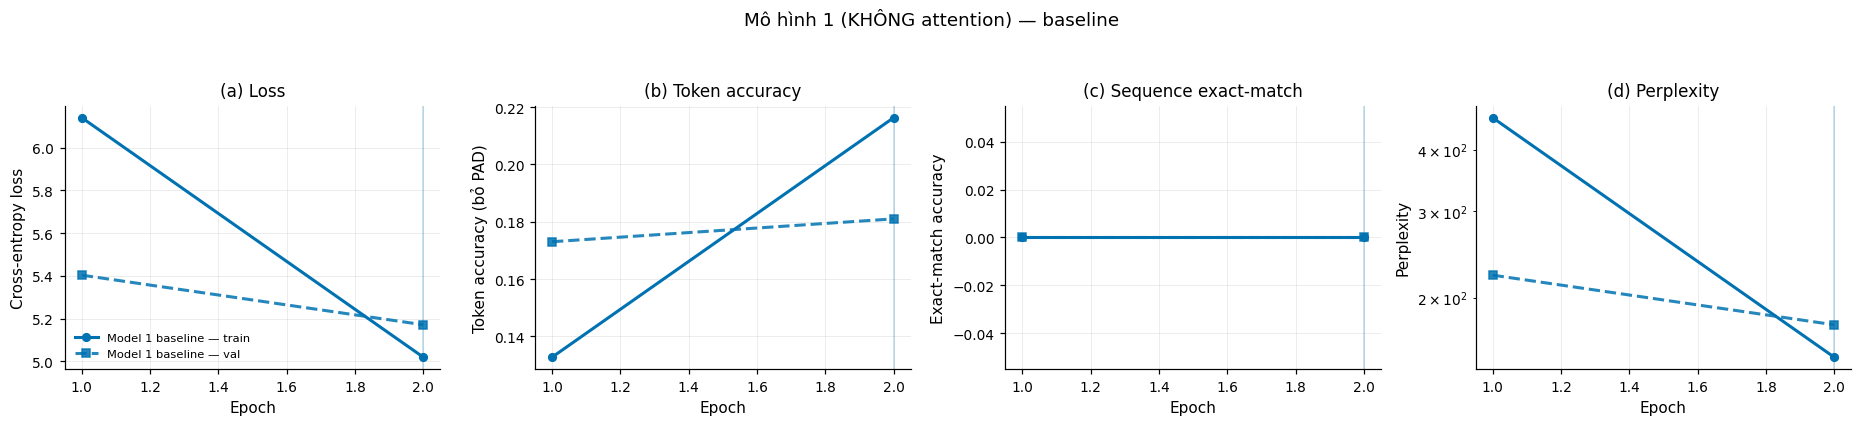


LỊCH SỬ HUẤN LUYỆN — Model 1 baseline


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1409,0.1328,5.4034,0.173,0.0,222.17,1.0e-03,1.8
1,2,5.0191,0.2163,5.1710,0.181,0.0,176.09,1.0e-03,0.8


In [32]:
# ============================================================================
# BT4 - Đường cong huấn luyện của BASELINE Mô hình 1
# ============================================================================
plot_history(hist_m1_base, title="Mô hình 1 (KHÔNG attention) — baseline",
             labels=("Model 1 baseline",))

In [33]:
# ============================================================================
# BT4 - BƯỚC 2: LƯỚI SIÊU THAM SỐ CHO MÔ HÌNH 1
# ============================================================================
M1_GRID = [
    # (0) baseline để tham chiếu trong cùng lịch trình rút gọn
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5, bidirectional=True),
    # (1) hidden nhỏ hơn -> nút cổ chai hẹp hơn nữa
    dict(hid_dim=256, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5, bidirectional=True),
    # (2) hidden lớn hơn -> context vector "rộng" hơn (giả thuyết: giảm bottleneck)
    dict(hid_dim=768, emb_dim=256, n_layers=1, dropout=0.3, lr=1e-3, tf=0.5, bidirectional=True),
    # (3) encoder MỘT chiều -> kiểm chứng đóng góp của bidirectional
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5, bidirectional=False),
    # (4) 2 lớp + dropout cao hơn
    dict(hid_dim=512, emb_dim=256, n_layers=2, dropout=0.3, lr=1e-3, tf=0.5, bidirectional=True),
    # (5) teacher forcing cao (học nhanh nhưng dễ lệch train/test)
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.9, bidirectional=True),
    # (6) teacher forcing thấp (gần với điều kiện suy luận thực tế)
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.3, bidirectional=True),
    # (7) learning rate lớn hơn + embedding lớn hơn
    dict(hid_dim=512, emb_dim=300, n_layers=1, dropout=0.2, lr=2e-3, tf=0.5, bidirectional=True),
]
if QUICK_RUN:
    M1_GRID = M1_GRID[:3]

print(f"Sẽ chạy {len(M1_GRID)} cấu hình x {SEARCH_EPOCHS} epoch (lịch trình rút gọn).")
print("Kết quả được ghi vào CSV sau MỖI thử nghiệm -> mất kết nối vẫn resume được.\n")

m1_search, M1_CSV = run_search("plain", M1_GRID, "bt4_model1_search.csv",
                               epochs=SEARCH_EPOCHS, tag_prefix="bt4_m1")

print("\nKẾT QUẢ DÒ SIÊU THAM SỐ — MÔ HÌNH 1 (sắp xếp theo val_loss tăng dần)")
_cols = ["trial", "hid_dim", "emb_dim", "n_layers", "dropout", "lr", "tf", "bidirectional",
         "params", "train_loss", "train_acc", "val_loss", "val_acc", "val_ppl", "time_s"]
_cols = [c for c in _cols if c in m1_search.columns]
display(m1_search[_cols].round(4))

Sẽ chạy 3 cấu hình x 1 epoch (lịch trình rút gọn).
Kết quả được ghi vào CSV sau MỖI thử nghiệm -> mất kết nối vẫn resume được.


[1/3] bidirectional=True|dropout=0.2|emb_dim=256|hid_dim=512|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train loss 6.1409 acc 0.1328 ppl 464.45 | val loss 5.4034 acc 0.1730 ppl 222.17 | lr 1.0e-03 tf 0.50 | 0.9s  <-- best
  Tổng thời gian: 1.1s | best epoch = 1 | best val_loss = 5.4034
    -> đã lưu kết quả vào /content/drive/MyDrive/dl_homework/hw4_5/bt4_model1_search.csv

[2/3] bidirectional=True|dropout=0.2|emb_dim=256|hid_dim=256|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train loss 6.5558 acc 0.1059 ppl 703.30 | val loss 5.5257 acc 0.1393 ppl 251.05 | lr 1.0e-03 tf 0.50 | 1.0s  <-- best
  Tổng thời gian: 1.1s | best epoch = 1 | best val_loss = 5.5257
    -> đã lưu kết quả vào /content/drive/MyDrive/dl_homework/hw4_5/bt4_model1_search.csv

[3/3] bidirectional=True|dropout=0.3|emb_dim=256|hid_dim=768|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train loss 5.8415 acc 0.1

,trial,hid_dim,emb_dim,n_layers,dropout,lr,tf,bidirectional,params,train_loss,train_acc,val_loss,val_acc,val_ppl,time_s
0,3,768,256,1,0.3,0.001,0.5,True,17823883,5.8415,0.1417,5.2942,0.1762,199.1879,1.2272
1,1,512,256,1,0.2,0.001,0.5,True,10473099,6.1409,0.1328,5.4034,0.1730,222.1697,1.0896
2,2,256,256,1,0.2,0.001,0.5,True,5219467,6.5558,0.1059,5.5257,0.1393,251.0546,1.0710


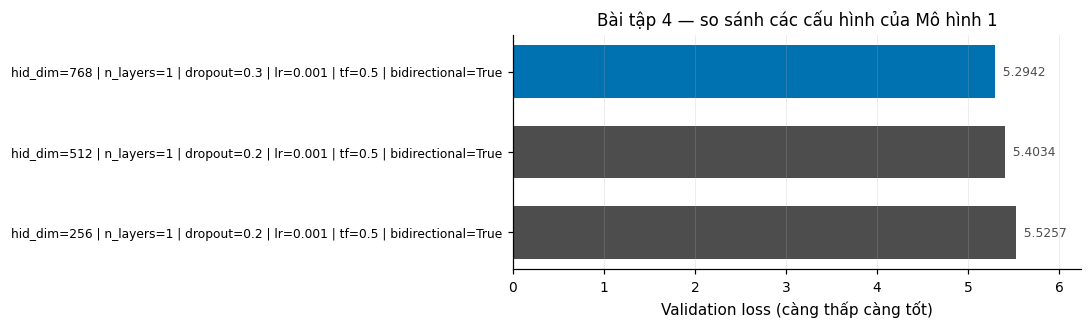

CẤU HÌNH TỐT NHẤT CHO MÔ HÌNH 1
  hid_dim        : 768
  emb_dim        : 256
  n_layers       : 1
  dropout        : 0.3
  lr             : 0.001
  tf             : 0.5
  bidirectional  : True
  val_loss       : 5.2942
  val_acc        : 17.62%

ẢNH HƯỞNG CỦA TỪNG SIÊU THAM SỐ (val_loss trung bình theo giá trị)

  -- hid_dim --
           mean  count
hid_dim               
256      5.5257      1
512      5.4034      1
768      5.2942      1

  -- dropout --
           mean  count
dropout               
0.2      5.4646      2
0.3      5.2942      1


In [34]:
# ============================================================================
# BT4 - Trực quan hoá kết quả dò + chọn cấu hình tốt nhất
# ============================================================================
plot_search(m1_search, "Bài tập 4 — so sánh các cấu hình của Mô hình 1",
            label_cols=[c for c in ["hid_dim", "n_layers", "dropout", "lr", "tf", "bidirectional"]
                        if c in m1_search.columns])

M1_KEYS = ["hid_dim", "emb_dim", "n_layers", "dropout", "lr", "tf", "bidirectional"]
best_m1_cfg, best_m1_row = best_config_from(m1_search, M1_KEYS)

print("CẤU HÌNH TỐT NHẤT CHO MÔ HÌNH 1")
print("=" * 60)
for k, v in best_m1_cfg.items():
    print(f"  {k:<15}: {v}")
print(f"  {'val_loss':<15}: {best_m1_row['val_loss']:.4f}")
print(f"  {'val_acc':<15}: {best_m1_row['val_acc'] * 100:.2f}%")
print("=" * 60)

# --- nhận xét tự động về ảnh hưởng của từng siêu tham số --------------------
_ok = m1_search[m1_search["status"] == "ok"] if "status" in m1_search else m1_search
print("\nẢNH HƯỞNG CỦA TỪNG SIÊU THAM SỐ (val_loss trung bình theo giá trị)")
for k in M1_KEYS:
    if k in _ok.columns and _ok[k].nunique() > 1:
        g = _ok.groupby(k)["val_loss"].agg(["mean", "count"]).round(4)
        print(f"\n  -- {k} --")
        print(g.to_string())

In [35]:
# ============================================================================
# BT4 - BƯỚC 3: HUẤN LUYỆN LẠI ĐẦY ĐỦ VỚI CẤU HÌNH TỐT NHẤT
# ============================================================================
set_seed(GLOBAL_SEED)
_bs = int(best_m1_cfg.get("batch_size", BATCH_SIZE))
train_loader, val_loader, test_loader, train_sampler = make_loaders(batch_size=_bs)

m1_best = build_model(
    "plain",
    emb_dim=int(best_m1_cfg["emb_dim"]),
    hid_dim=int(best_m1_cfg["hid_dim"]),
    n_layers=int(best_m1_cfg["n_layers"]),
    dropout=float(best_m1_cfg["dropout"]),
    bidirectional=bool(best_m1_cfg["bidirectional"]),
)
M1_PARAMS = count_params(m1_best)[0]
print(f"Mô hình 1 (tốt nhất): {M1_PARAMS:,} tham số")
print(f"Huấn luyện đầy đủ {FULL_EPOCHS} epoch với cấu hình: {best_m1_cfg}\n")

m1_best, hist_m1 = train_model(
    m1_best, train_loader, val_loader,
    epochs=FULL_EPOCHS,
    lr=float(best_m1_cfg["lr"]),
    teacher_forcing=float(best_m1_cfg["tf"]),
    patience=PATIENCE, tag="bt4_m1_best", sampler=train_sampler,
)
M1_TRAIN_TIME = hist_m1["total_time"]

Mô hình 1 (tốt nhất): 17,823,883 tham số
Huấn luyện đầy đủ 2 epoch với cấu hình: {'hid_dim': 768, 'emb_dim': 256, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'tf': 0.5, 'bidirectional': True}



[bt4_m1_best] ep1/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  1/2 | train loss 5.8415 acc 0.1417 ppl 344.31 | val loss 5.2942 acc 0.1762 ppl 199.19 | lr 1.0e-03 tf 0.50 | 1.0s  <-- best


[bt4_m1_best] ep2/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  2/2 | train loss 4.8135 acc 0.2378 ppl 123.17 | val loss 5.0089 acc 0.2121 ppl 149.74 | lr 1.0e-03 tf 0.50 | 0.8s  <-- best
  Tổng thời gian: 2.3s | best epoch = 2 | best val_loss = 5.0089


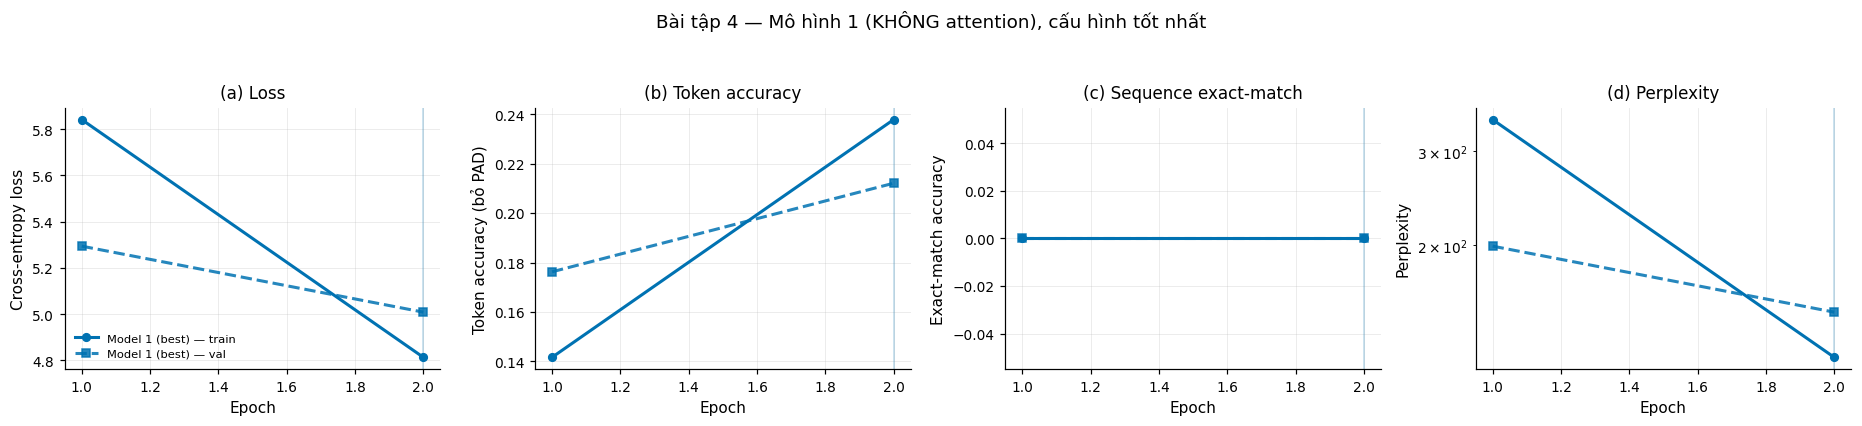


LỊCH SỬ HUẤN LUYỆN — Model 1 (best)


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,5.8415,0.1417,5.2942,0.1762,0.0,199.19,1.0e-03,1.0
1,2,4.8135,0.2378,5.0089,0.2121,0.0,149.74,1.0e-03,0.8


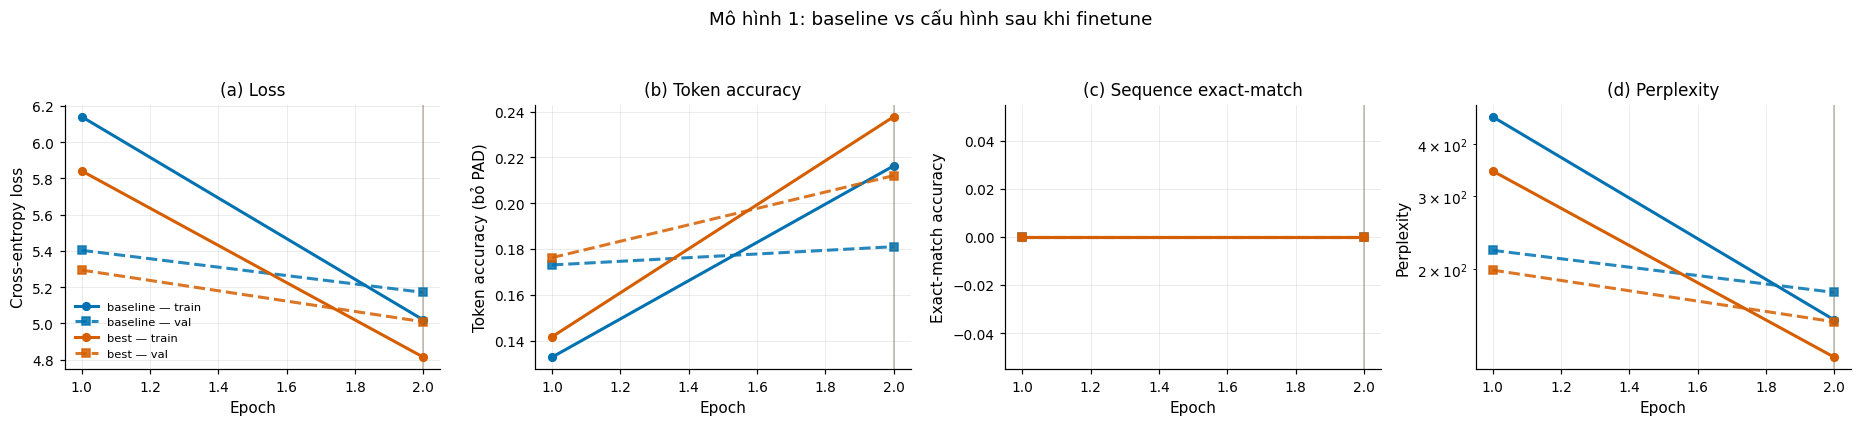


LỊCH SỬ HUẤN LUYỆN — baseline


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1409,0.1328,5.4034,0.173,0.0,222.17,1.0e-03,1.8
1,2,5.0191,0.2163,5.1710,0.181,0.0,176.09,1.0e-03,0.8



LỊCH SỬ HUẤN LUYỆN — best


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,5.8415,0.1417,5.2942,0.1762,0.0,199.19,1.0e-03,1.0
1,2,4.8135,0.2378,5.0089,0.2121,0.0,149.74,1.0e-03,0.8



Sau khi finetune, Mô hình 1 thay đổi val_loss tốt nhất: +0.1621 (cải thiện), val_acc tốt nhất: +3.10 điểm phần trăm.


In [36]:
# ============================================================================
# BT4 - 4 ĐƯỜNG CONG: train loss / train acc / val loss / val acc
# ============================================================================
plot_history(hist_m1,
             title="Bài tập 4 — Mô hình 1 (KHÔNG attention), cấu hình tốt nhất",
             labels=("Model 1 (best)",))

# So sánh baseline vs best
plot_history([hist_m1_base, hist_m1],
             title="Mô hình 1: baseline vs cấu hình sau khi finetune",
             labels=("baseline", "best"))

_imp = min(hist_m1_base["val_loss"]) - min(hist_m1["val_loss"])
_impa = max(hist_m1["val_acc"]) - max(hist_m1_base["val_acc"])
print(f"\nSau khi finetune, Mô hình 1 thay đổi val_loss tốt nhất: {_imp:+.4f} "
      f"({'cải thiện' if _imp > 0 else 'không cải thiện'}), "
      f"val_acc tốt nhất: {_impa * 100:+.2f} điểm phần trăm.")

In [37]:
# ============================================================================
# BT4 - BƯỚC 4: ĐÁNH GIÁ TRÊN TẬP TEST (greedy + beam search)
# ============================================================================
_beam_limit = None if not QUICK_RUN else 200

m1_test_greedy, (m1_hyp_g, m1_ref_g, m1_src_g) = evaluate_full(
    m1_best, test_loader, name="Mô hình 1", decode="greedy")

print("\n" + "=" * 62)
print("Beam search (chậm hơn nhiều vì giải mã từng câu)...")
m1_test_beam, (m1_hyp_b, m1_ref_b, m1_src_b) = evaluate_full(
    m1_best, test_loader, name="Mô hình 1", decode="beam",
    beam_size=BEAM_SIZE, limit=_beam_limit)

m1_results = pd.DataFrame([m1_test_greedy, m1_test_beam])
print("\nBẢNG KẾT QUẢ TEST — MÔ HÌNH 1")
display(m1_results[["model", "decode", "loss", "ppl", "token_acc", "seq_acc",
                    "exact_match", "bleu", "chrf", "edit_dist", "n_samples"]].round(4))

Mô hình 1/greedy:   0%|          | 0/4 [00:00<?, ?it/s]


KẾT QUẢ — Mô hình 1 (giải mã: greedy)
--------------------------------------------------------------
  Loss                        : 5.0678   (ppl 158.83)
  Token accuracy (KHÔNG TF)   : 20.72%   <-- ĐỘ CHÍNH XÁC
  Token accuracy (có TF)      : 25.13%
  Sequence exact-match (TF=0) : 0.00%
  Exact match (dịch tự do)    : 0.00%
  BLEU-4                      : 1.45
    precisions 1/2/3/4        : 24.4 / 3.8 / 0.6 / 0.2
    brevity penalty           : 0.8330 (tỉ lệ độ dài 0.846)
  chrF                        : 7.51
  Edit distance (chuẩn hoá)   : 0.8250  (càng thấp càng tốt)
  Số mẫu / thời gian giải mã  : 800 / 0.4s
--------------------------------------------------------------

Beam search (chậm hơn nhiều vì giải mã từng câu)...


Mô hình 1/beam:   0%|          | 0/4 [00:00<?, ?it/s]


KẾT QUẢ — Mô hình 1 (giải mã: beam)
--------------------------------------------------------------
  Loss                        : 5.0678   (ppl 158.83)
  Token accuracy (KHÔNG TF)   : 20.72%   <-- ĐỘ CHÍNH XÁC
  Token accuracy (có TF)      : 25.13%
  Sequence exact-match (TF=0) : 0.00%
  Exact match (dịch tự do)    : 0.00%
  BLEU-4                      : 2.16
    precisions 1/2/3/4        : 29.1 / 5.8 / 1.1 / 0.3
    brevity penalty           : 0.7759 (tỉ lệ độ dài 0.798)
  chrF                        : 8.05
  Edit distance (chuẩn hoá)   : 0.7986  (càng thấp càng tốt)
  Số mẫu / thời gian giải mã  : 200 / 2.7s
--------------------------------------------------------------

BẢNG KẾT QUẢ TEST — MÔ HÌNH 1


,model,decode,loss,ppl,token_acc,seq_acc,exact_match,bleu,chrf,edit_dist,n_samples
0,Mô hình 1,greedy,5.0678,158.8306,0.2072,0.0,0.0,1.4452,7.5105,0.8250,800
1,Mô hình 1,beam,5.0678,158.8306,0.2072,0.0,0.0,2.1573,8.0450,0.7986,200


BLEU / chrF THEO NHÓM ĐỘ DÀI CÂU NGUỒN — MÔ HÌNH 1


,model,bucket,lo,hi,n,bleu,chrf,exact_match,edit_dist,len_ratio
0,Mô hình 1,1-3,1,3,8,3.581,4.686,0.0,0.948,1.571
1,Mô hình 1,4-5,4,5,159,1.226,8.370,0.0,0.829,1.119
2,Mô hình 1,6-7,6,7,280,1.876,7.508,0.0,0.820,0.912
3,Mô hình 1,8-9,8,9,232,1.448,7.645,0.0,0.818,0.745
4,Mô hình 1,10-+,10,99,121,1.569,6.778,0.0,0.838,0.691


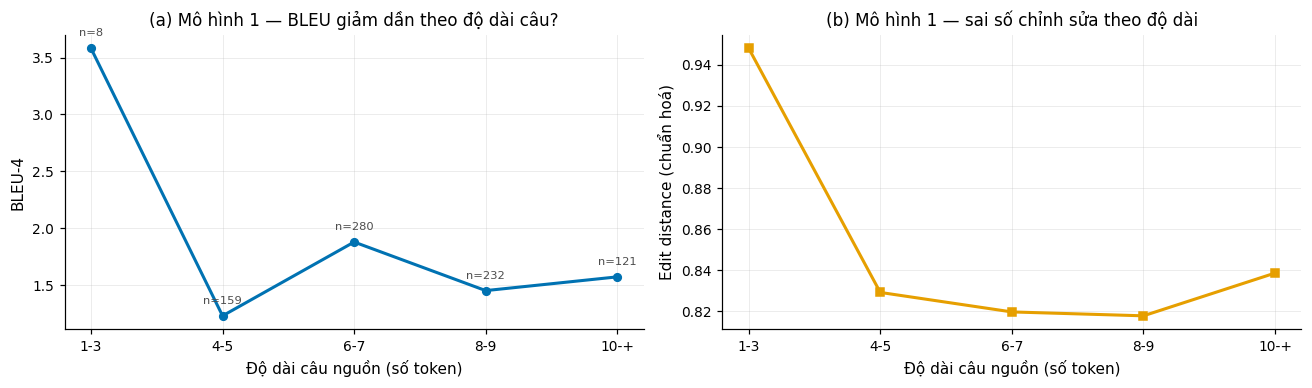

Chênh lệch BLEU giữa nhóm câu NGẮN NHẤT (1-3) và DÀI NHẤT (10-+): +2.01 điểm BLEU.
(Số dương lớn = mô hình dịch câu dài kém hơn hẳn -> dấu hiệu của nút cổ chai context vector độ dài cố định.)


In [38]:
# ============================================================================
# BT4 - BƯỚC 5: PHÂN TÍCH LỖI THEO ĐỘ DÀI CÂU
# ============================================================================
def error_analysis_by_length(hyps, refs, srcs, name="model", buckets=((1, 3), (4, 5), (6, 7), (8, 9), (10, 99))):
    """Tính BLEU / exact-match / edit-distance theo từng nhóm độ dài câu NGUỒN."""
    rows = []
    for lo, hi in buckets:
        idx = [i for i, s in enumerate(srcs) if lo <= len(s) <= hi]
        if len(idx) < 5:
            continue
        h = [hyps[i] for i in idx]
        r = [refs[i] for i in idx]
        b = corpus_bleu(h, r)
        rows.append({
            "model": name,
            "bucket": f"{lo}-{hi if hi < 90 else '+'}",
            "lo": lo, "hi": hi,
            "n": len(idx),
            "bleu": b["bleu"] * 100,
            "chrf": chrf_score(h, r) * 100,
            "exact_match": exact_match_rate(h, r) * 100,
            "edit_dist": avg_norm_edit_distance(h, r),
            "len_ratio": b["ratio"],
        })
    return pd.DataFrame(rows)


m1_bucket = error_analysis_by_length(m1_hyp_g, m1_ref_g, m1_src_g, "Mô hình 1")
print("BLEU / chrF THEO NHÓM ĐỘ DÀI CÂU NGUỒN — MÔ HÌNH 1")
display(m1_bucket.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(m1_bucket["bucket"], m1_bucket["bleu"], color=PALETTE["m1"], marker="o")
for x, y, n in zip(m1_bucket["bucket"], m1_bucket["bleu"], m1_bucket["n"]):
    axes[0].annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7.5, color=PALETTE["neutral"])
axes[0].set_xlabel("Độ dài câu nguồn (số token)")
axes[0].set_ylabel("BLEU-4")
axes[0].set_title("(a) Mô hình 1 — BLEU giảm dần theo độ dài câu?")

axes[1].plot(m1_bucket["bucket"], m1_bucket["edit_dist"], color=PALETTE["accent"], marker="s")
axes[1].set_xlabel("Độ dài câu nguồn (số token)")
axes[1].set_ylabel("Edit distance (chuẩn hoá)")
axes[1].set_title("(b) Mô hình 1 — sai số chỉnh sửa theo độ dài")
plt.tight_layout()
plt.show()

if len(m1_bucket) >= 2:
    _d = m1_bucket["bleu"].iloc[0] - m1_bucket["bleu"].iloc[-1]
    print(f"Chênh lệch BLEU giữa nhóm câu NGẮN NHẤT ({m1_bucket['bucket'].iloc[0]}) và "
          f"DÀI NHẤT ({m1_bucket['bucket'].iloc[-1]}): {_d:+.2f} điểm BLEU.")
    print("(Số dương lớn = mô hình dịch câu dài kém hơn hẳn -> dấu hiệu của nút cổ chai "
          "context vector độ dài cố định.)")

In [39]:
# ============================================================================
# BT4 - Ví dụ dịch của Mô hình 1
# ============================================================================
set_seed(GLOBAL_SEED)
_show = min(12, len(m1_hyp_g))
_idx = sorted(random.sample(range(len(m1_hyp_g)), _show), key=lambda i: len(m1_src_g[i]))
_rows = []
for i in _idx:
    _rows.append({
        "EN (nguồn)": " ".join(m1_src_g[i]),
        "FR (tham chiếu)": " ".join(m1_ref_g[i]),
        "Mô hình 1 (greedy)": " ".join(m1_hyp_g[i]),
        "khớp?": "✔" if m1_hyp_g[i] == m1_ref_g[i] else "",
    })
print("VÍ DỤ DỊCH — MÔ HÌNH 1")
display(pd.DataFrame(_rows))

print("\nThử với vài câu tự nhập:")
for s in ["i am hungry .", "she is reading a book in the garden .",
          "we will go to paris next summer with our friends ."]:
    print(f"  EN     : {s}")
    print(f"  greedy : {translate_sentence(m1_best, s, decode='greedy')}")
    print(f"  beam   : {translate_sentence(m1_best, s, decode='beam')}")
    print()

VÍ DỤ DỊCH — MÔ HÌNH 1


,EN (nguồn),FR (tham chiếu),Mô hình 1 (greedy),khớp?
0,tom is <unk> .,tom est <unk> .,tom est est est est tom tom,
1,this <unk> can fly .,cet <unk> sait voler .,c ' est est ' ',
2,i almost gave up .,j ' ai failli <unk> .,je ' ai ' ' ',
3,don ' t worry about me .,ne vous <unk> pas de moi .,ne n ' pas pas pas pas pas,
4,i ' m no longer <unk> .,je ne suis plus dans les <unk> .,je suis suis pas pas pas,
5,i took the dog for a walk .,j ' ai <unk> le chien .,j ' ai un un un,
6,if only i had known this earlier .,si seulement j ' avais su ça plus tôt .,je ' ' ' ' ' ',
7,i almost left my umbrella in the train .,j ' ai failli <unk> mon parapluie dans le train .,j ' ai la ' la,
8,i ' m tired of waiting in line .,je suis fatigué de faire la <unk> .,je suis suis suis de,
9,tom and mary came to boston with me .,tom et mary sont <unk> avec moi à boston .,tom tom tom tom tom tom tom tom,



Thử với vài câu tự nhập:
  EN     : i am hungry .
  greedy : je ' ai ai '
  beam   : je suis ' ai '

  EN     : she is reading a book in the garden .
  greedy : elle est un un un un un un .
  beam   : elle est un un un un .

  EN     : we will go to paris next summer with our friends .
  greedy : nous nous nous nous nous nous .
  beam   : nous nous nous nous .



### Nhận xét Bài tập 4 (đọc kèm số liệu in ra ở các ô trên)

**a) Về quá trình huấn luyện.** Đường `train_loss` và `val_loss` cần được đọc cùng nhau:
khoảng cách giữa chúng là mức *overfitting*. Vì tập dữ liệu chỉ có vài chục nghìn cặp câu
trong khi mô hình có hàng triệu tham số, `val_loss` thường chạm đáy rồi đi ngang/đi lên —
đó là lý do ta dùng **early stopping** và **chỉ lấy checkpoint tốt nhất theo `val_loss`**,
chứ không lấy epoch cuối.

**b) Về `val_acc` được đo với teacher forcing = 0.** Con số này thấp hơn accuracy đo khi có
teacher forcing (cột `token_acc_tf` trong bảng test), và đó là điều đúng đắn: khi suy luận thật,
mô hình phải tự nuôi đầu ra của chính nó, nên **lỗi tích luỹ (exposure bias)**. Báo cáo accuracy
có teacher forcing sẽ là một con số đẹp nhưng không phản ánh chất lượng dịch thực tế.

**c) Về các siêu tham số** — bảng "ẢNH HƯỞNG CỦA TỪNG SIÊU THAM SỐ" ở trên cho biết
giá trị nào tốt hơn *trên chính lần chạy này*. Các cơ chế cần lưu ý khi đọc:

- **`hid_dim`** là chiều rộng của "ống dẫn" duy nhất giữa encoder và decoder ở Mô hình 1.
  Tăng `hid_dim` thường giúp — nhưng lợi ích giảm dần, còn nguy cơ overfit thì tăng.
- **`bidirectional`** cho encoder nhìn được ngữ cảnh hai phía trước khi nén.
- **`n_layers = 2`** tăng năng lực biểu diễn nhưng RNN sâu khó huấn luyện hơn và với
  vài chục nghìn câu thường không đủ dữ liệu để trả công.
- **Teacher forcing ratio** là một sự đánh đổi: cao → hội tụ nhanh trên train nhưng khoảng cách
  train/inference lớn; thấp → sát điều kiện suy luận nhưng học chậm và nhiễu hơn.

**d) Beam search so với greedy.** So sánh 2 dòng trong "BẢNG KẾT QUẢ TEST". Beam thường
nhỉnh hơn về BLEU vì tránh được bẫy tối ưu cục bộ, đổi lại thời gian giải mã tăng nhiều lần.

**e) Điểm yếu cốt lõi lộ ra ở biểu đồ BLEU theo độ dài.** Nếu BLEU giảm rõ rệt khi câu dài lên,
đó chính là dấu vân tay của **nút cổ chai context vector**: toàn bộ câu nguồn bị nén vào một
vector `H` chiều duy nhất. Đây là động lực trực tiếp cho **Mô hình 2** ở Bài tập 5.

---
---

# Bài tập 5 — Finetune **Mô hình 2** (RNN Encoder–Decoder **CÓ** Attention)

Cùng loại RNN (**GRU**), cùng encoder, cùng quy trình dò siêu tham số như Bài tập 4 —
**chỉ khác cơ chế attention**. Nhờ giữ nguyên mọi thứ còn lại, mọi chênh lệch kết quả
đều có thể quy về đóng góp của attention.

**Các trục siêu tham số riêng của Mô hình 2:**

- `attn_dim` — số chiều không gian căn chỉnh của Bahdanau attention.
- `attn_kind` — **Bahdanau (additive)** so với **Luong (general/multiplicative)**.

Sau khi có mô hình tốt nhất, ta sẽ **trực quan hoá ma trận attention** để kiểm tra xem
mô hình có thực sự học được alignment giữa từ nguồn và từ đích hay không.

Mô hình 2 (baseline): 10,735,499 tham số
Cấu hình: emb=256, hid=512, layers=1, dropout=0.2, bidir=True, attn_dim=256, attn=bahdanau, lr=0.001, tf=0.5, cell=GRU



[m2_baseline] ep1/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  1/2 | train loss 6.1246 acc 0.1366 ppl 456.96 | val loss 5.4035 acc 0.1665 ppl 222.19 | lr 1.0e-03 tf 0.50 | 1.5s  <-- best


[m2_baseline] ep2/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  2/2 | train loss 5.0287 acc 0.2119 ppl 152.73 | val loss 5.1068 acc 0.1944 ppl 165.13 | lr 1.0e-03 tf 0.50 | 1.2s  <-- best
  Tổng thời gian: 2.9s | best epoch = 2 | best val_loss = 5.1068


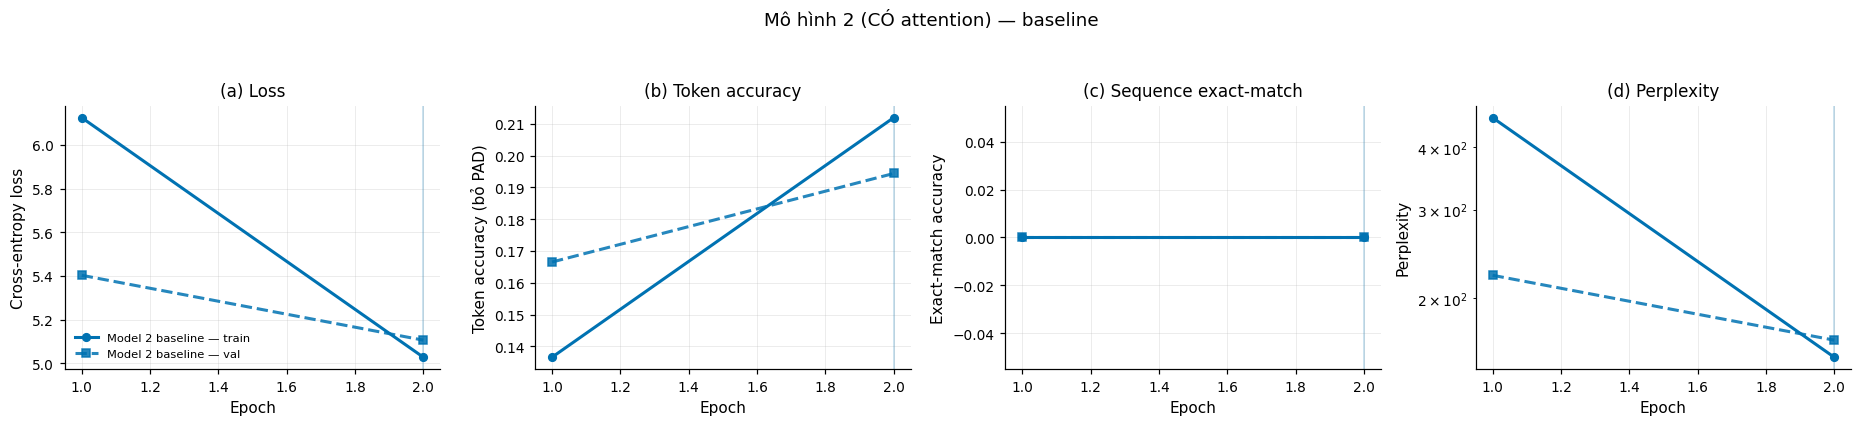


LỊCH SỬ HUẤN LUYỆN — Model 2 baseline


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1246,0.1366,5.4035,0.1665,0.0,222.19,1.0e-03,1.5
1,2,5.0287,0.2119,5.1068,0.1944,0.0,165.13,1.0e-03,1.2


In [40]:
# ============================================================================
# BT5 - BƯỚC 1: BASELINE MÔ HÌNH 2
# ============================================================================
set_seed(GLOBAL_SEED)
train_loader, val_loader, test_loader, train_sampler = make_loaders()

m2_base = build_model("attn")
print(f"Mô hình 2 (baseline): {count_params(m2_base)[0]:,} tham số")
print(f"Cấu hình: emb={EMB_DIM}, hid={HID_DIM}, layers={N_LAYERS}, dropout={DROPOUT}, "
      f"bidir={BIDIRECTIONAL}, attn_dim={ATTN_DIM}, attn=bahdanau, lr={LR}, "
      f"tf={TF_RATIO}, cell={RNN_CELL}\n")

m2_base, hist_m2_base = train_model(
    m2_base, train_loader, val_loader,
    epochs=FULL_EPOCHS, lr=LR, teacher_forcing=TF_RATIO,
    patience=PATIENCE, tag="m2_baseline", sampler=train_sampler,
)

plot_history(hist_m2_base, title="Mô hình 2 (CÓ attention) — baseline",
             labels=("Model 2 baseline",))

In [41]:
# ============================================================================
# BT5 - BƯỚC 2: LƯỚI SIÊU THAM SỐ CHO MÔ HÌNH 2
# ============================================================================
M2_GRID = [
    # (0) baseline
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=256, attn_kind="bahdanau"),
    # (1) không gian attention hẹp hơn
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=128, attn_kind="bahdanau"),
    # (2) không gian attention rộng hơn
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=512, attn_kind="bahdanau"),
    # (3) Luong (general) thay cho Bahdanau
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=256, attn_kind="luong"),
    # (4) hidden nhỏ hơn - attention có bù được không?
    dict(hid_dim=256, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=256, attn_kind="bahdanau"),
    # (5) dropout cao hơn (chống overfit)
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.35, lr=1e-3, tf=0.5,
         bidirectional=True, attn_dim=256, attn_kind="bahdanau"),
    # (6) teacher forcing thấp hơn
    dict(hid_dim=512, emb_dim=256, n_layers=1, dropout=0.2, lr=1e-3, tf=0.3,
         bidirectional=True, attn_dim=256, attn_kind="bahdanau"),
    # (7) lr lớn hơn + embedding lớn hơn
    dict(hid_dim=512, emb_dim=300, n_layers=1, dropout=0.2, lr=2e-3, tf=0.5,
         bidirectional=True, attn_dim=256, attn_kind="bahdanau"),
]
if QUICK_RUN:
    M2_GRID = M2_GRID[:3]

print(f"Sẽ chạy {len(M2_GRID)} cấu hình x {SEARCH_EPOCHS} epoch (lịch trình rút gọn).\n")

m2_search, M2_CSV = run_search("attn", M2_GRID, "bt5_model2_search.csv",
                               epochs=SEARCH_EPOCHS, tag_prefix="bt5_m2")

print("\nKẾT QUẢ DÒ SIÊU THAM SỐ — MÔ HÌNH 2 (sắp xếp theo val_loss tăng dần)")
_cols2 = ["trial", "hid_dim", "emb_dim", "n_layers", "dropout", "lr", "tf",
          "attn_dim", "attn_kind", "params", "train_loss", "train_acc",
          "val_loss", "val_acc", "val_ppl", "time_s"]
_cols2 = [c for c in _cols2 if c in m2_search.columns]
display(m2_search[_cols2].round(4))

Sẽ chạy 3 cấu hình x 1 epoch (lịch trình rút gọn).


[1/3] attn_dim=256|attn_kind=bahdanau|bidirectional=True|dropout=0.2|emb_dim=256|hid_dim=512|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train loss 6.1246 acc 0.1366 ppl 456.96 | val loss 5.4035 acc 0.1665 ppl 222.19 | lr 1.0e-03 tf 0.50 | 1.2s  <-- best
  Tổng thời gian: 1.4s | best epoch = 1 | best val_loss = 5.4035
    -> đã lưu kết quả vào /content/drive/MyDrive/dl_homework/hw4_5/bt5_model2_search.csv

[2/3] attn_dim=128|attn_kind=bahdanau|bidirectional=True|dropout=0.2|emb_dim=256|hid_dim=512|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train loss 6.1984 acc 0.1397 ppl 491.98 | val loss 5.2932 acc 0.1678 ppl 198.99 | lr 1.0e-03 tf 0.50 | 1.2s  <-- best
  Tổng thời gian: 1.4s | best epoch = 1 | best val_loss = 5.2932
    -> đã lưu kết quả vào /content/drive/MyDrive/dl_homework/hw4_5/bt5_model2_search.csv

[3/3] attn_dim=512|attn_kind=bahdanau|bidirectional=True|dropout=0.2|emb_dim=256|hid_dim=512|lr=0.001|n_layers=1|tf=0.5
  ep  1/1 | train

,trial,hid_dim,emb_dim,n_layers,dropout,lr,tf,attn_dim,attn_kind,params,train_loss,train_acc,val_loss,val_acc,val_ppl,time_s
0,2,512,256,1,0.2,0.001,0.5,128,bahdanau,10604299,6.1984,0.1397,5.2932,0.1678,198.9889,1.4145
1,1,512,256,1,0.2,0.001,0.5,256,bahdanau,10735499,6.1246,0.1366,5.4035,0.1665,222.1863,1.3983
2,3,512,256,1,0.2,0.001,0.5,512,bahdanau,10997899,6.0574,0.1449,5.4648,0.1752,236.2222,1.4128


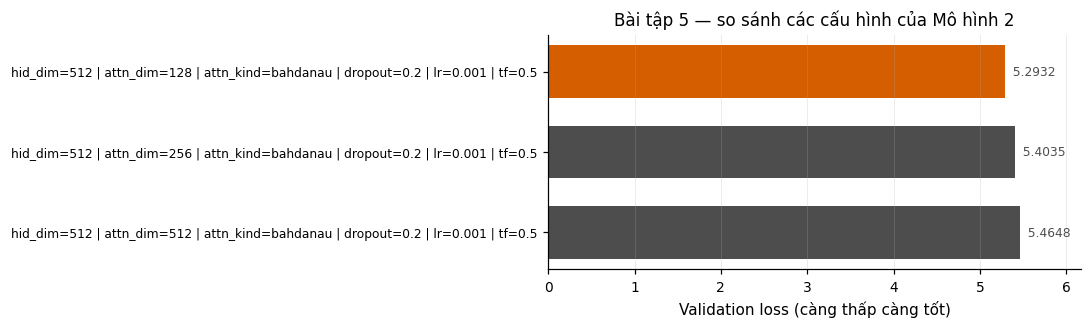

CẤU HÌNH TỐT NHẤT CHO MÔ HÌNH 2
  hid_dim        : 512
  emb_dim        : 256
  n_layers       : 1
  dropout        : 0.2
  lr             : 0.001
  tf             : 0.5
  bidirectional  : True
  attn_dim       : 128
  attn_kind      : bahdanau
  val_loss       : 5.2932
  val_acc        : 16.78%

ẢNH HƯỞNG CỦA TỪNG SIÊU THAM SỐ (val_loss trung bình theo giá trị)

  -- attn_dim --
            mean  count
attn_dim               
128       5.2932      1
256       5.4035      1
512       5.4648      1


In [42]:
# ============================================================================
# BT5 - Trực quan hoá kết quả dò + chọn cấu hình tốt nhất
# ============================================================================
plot_search(m2_search, "Bài tập 5 — so sánh các cấu hình của Mô hình 2",
            label_cols=[c for c in ["hid_dim", "attn_dim", "attn_kind", "dropout", "lr", "tf"]
                        if c in m2_search.columns])

M2_KEYS = ["hid_dim", "emb_dim", "n_layers", "dropout", "lr", "tf",
           "bidirectional", "attn_dim", "attn_kind"]
best_m2_cfg, best_m2_row = best_config_from(m2_search, M2_KEYS)

print("CẤU HÌNH TỐT NHẤT CHO MÔ HÌNH 2")
print("=" * 60)
for k, v in best_m2_cfg.items():
    print(f"  {k:<15}: {v}")
print(f"  {'val_loss':<15}: {best_m2_row['val_loss']:.4f}")
print(f"  {'val_acc':<15}: {best_m2_row['val_acc'] * 100:.2f}%")
print("=" * 60)

_ok2 = m2_search[m2_search["status"] == "ok"] if "status" in m2_search else m2_search
print("\nẢNH HƯỞNG CỦA TỪNG SIÊU THAM SỐ (val_loss trung bình theo giá trị)")
for k in M2_KEYS:
    if k in _ok2.columns and _ok2[k].nunique() > 1:
        g = _ok2.groupby(k)["val_loss"].agg(["mean", "count"]).round(4)
        print(f"\n  -- {k} --")
        print(g.to_string())

# So sánh trực tiếp Bahdanau vs Luong nếu cả hai đều có trong lưới
if "attn_kind" in _ok2.columns and _ok2["attn_kind"].nunique() > 1:
    _cmp = _ok2.groupby("attn_kind")[["val_loss", "val_acc", "time_s"]].mean().round(4)
    print("\nBAHDANAU vs LUONG")
    display(_cmp)

In [43]:
# ============================================================================
# BT5 - BƯỚC 3: HUẤN LUYỆN LẠI ĐẦY ĐỦ VỚI CẤU HÌNH TỐT NHẤT
# ============================================================================
set_seed(GLOBAL_SEED)
train_loader, val_loader, test_loader, train_sampler = make_loaders()

m2_best = build_model(
    "attn",
    emb_dim=int(best_m2_cfg["emb_dim"]),
    hid_dim=int(best_m2_cfg["hid_dim"]),
    n_layers=int(best_m2_cfg["n_layers"]),
    dropout=float(best_m2_cfg["dropout"]),
    bidirectional=bool(best_m2_cfg["bidirectional"]),
    attn_dim=int(best_m2_cfg["attn_dim"]),
    attn_kind=str(best_m2_cfg["attn_kind"]),
)
M2_PARAMS = count_params(m2_best)[0]
print(f"Mô hình 2 (tốt nhất): {M2_PARAMS:,} tham số")
print(f"Huấn luyện đầy đủ {FULL_EPOCHS} epoch với cấu hình: {best_m2_cfg}\n")

m2_best, hist_m2 = train_model(
    m2_best, train_loader, val_loader,
    epochs=FULL_EPOCHS,
    lr=float(best_m2_cfg["lr"]),
    teacher_forcing=float(best_m2_cfg["tf"]),
    patience=PATIENCE, tag="bt5_m2_best", sampler=train_sampler,
)
M2_TRAIN_TIME = hist_m2["total_time"]

Mô hình 2 (tốt nhất): 10,604,299 tham số
Huấn luyện đầy đủ 2 epoch với cấu hình: {'hid_dim': 512, 'emb_dim': 256, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'tf': 0.5, 'bidirectional': True, 'attn_dim': 128, 'attn_kind': 'bahdanau'}



[bt5_m2_best] ep1/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  1/2 | train loss 6.1984 acc 0.1397 ppl 491.98 | val loss 5.2932 acc 0.1678 ppl 198.99 | lr 1.0e-03 tf 0.50 | 1.3s  <-- best


[bt5_m2_best] ep2/2 train:   0%|          | 0/19 [00:00<?, ?it/s]

  ep  2/2 | train loss 5.1065 acc 0.2057 ppl 165.09 | val loss 5.1157 acc 0.1868 ppl 166.62 | lr 1.0e-03 tf 0.50 | 1.2s  <-- best
  Tổng thời gian: 2.9s | best epoch = 2 | best val_loss = 5.1157


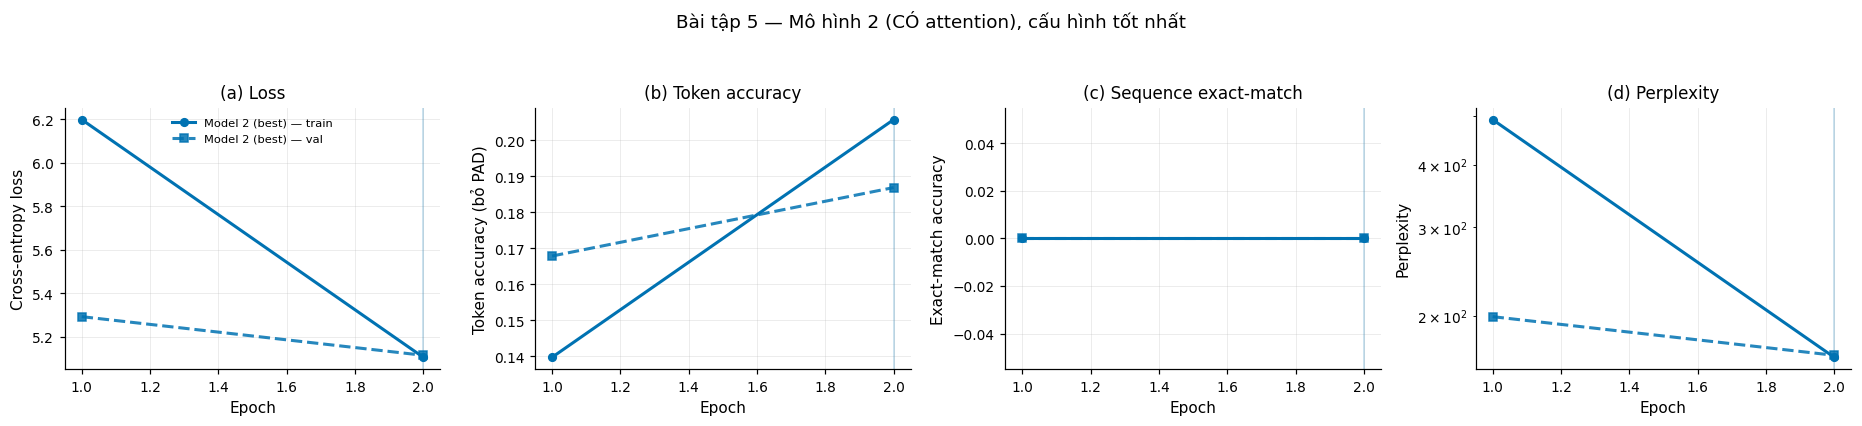


LỊCH SỬ HUẤN LUYỆN — Model 2 (best)


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1984,0.1397,5.2932,0.1678,0.0,198.99,1.0e-03,1.3
1,2,5.1065,0.2057,5.1157,0.1868,0.0,166.62,1.0e-03,1.2


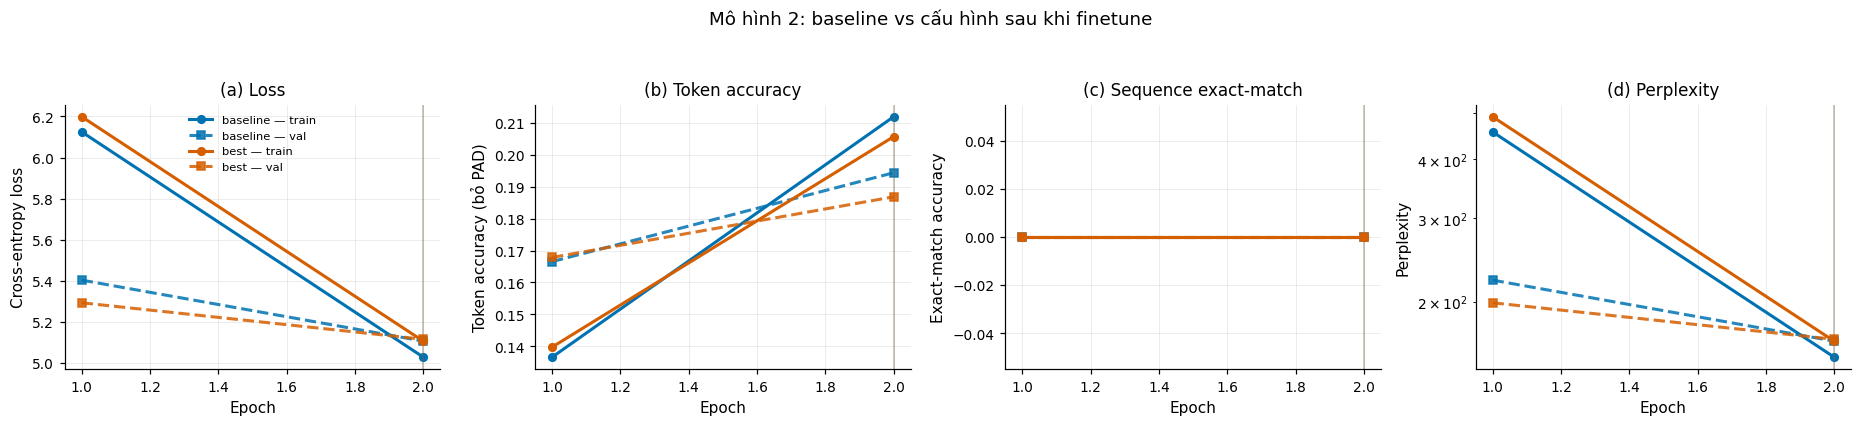


LỊCH SỬ HUẤN LUYỆN — baseline


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1246,0.1366,5.4035,0.1665,0.0,222.19,1.0e-03,1.5
1,2,5.0287,0.2119,5.1068,0.1944,0.0,165.13,1.0e-03,1.2



LỊCH SỬ HUẤN LUYỆN — best


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1984,0.1397,5.2932,0.1678,0.0,198.99,1.0e-03,1.3
1,2,5.1065,0.2057,5.1157,0.1868,0.0,166.62,1.0e-03,1.2



Sau khi finetune, Mô hình 2 thay đổi val_loss tốt nhất: -0.0090, val_acc tốt nhất: -0.75 điểm phần trăm.


In [44]:
# ============================================================================
# BT5 - 4 ĐƯỜNG CONG cho Mô hình 2
# ============================================================================
plot_history(hist_m2,
             title="Bài tập 5 — Mô hình 2 (CÓ attention), cấu hình tốt nhất",
             labels=("Model 2 (best)",))

plot_history([hist_m2_base, hist_m2],
             title="Mô hình 2: baseline vs cấu hình sau khi finetune",
             labels=("baseline", "best"))

_imp2 = min(hist_m2_base["val_loss"]) - min(hist_m2["val_loss"])
_impa2 = max(hist_m2["val_acc"]) - max(hist_m2_base["val_acc"])
print(f"\nSau khi finetune, Mô hình 2 thay đổi val_loss tốt nhất: {_imp2:+.4f}, "
      f"val_acc tốt nhất: {_impa2 * 100:+.2f} điểm phần trăm.")

In [45]:
# ============================================================================
# BT5 - BƯỚC 4: ĐÁNH GIÁ TRÊN TẬP TEST
# ============================================================================
m2_test_greedy, (m2_hyp_g, m2_ref_g, m2_src_g) = evaluate_full(
    m2_best, test_loader, name="Mô hình 2", decode="greedy")

print("\n" + "=" * 62)
print("Beam search...")
m2_test_beam, (m2_hyp_b, m2_ref_b, m2_src_b) = evaluate_full(
    m2_best, test_loader, name="Mô hình 2", decode="beam",
    beam_size=BEAM_SIZE, limit=_beam_limit)

m2_results = pd.DataFrame([m2_test_greedy, m2_test_beam])
print("\nBẢNG KẾT QUẢ TEST — MÔ HÌNH 2")
display(m2_results[["model", "decode", "loss", "ppl", "token_acc", "seq_acc",
                    "exact_match", "bleu", "chrf", "edit_dist", "n_samples"]].round(4))

Mô hình 2/greedy:   0%|          | 0/4 [00:00<?, ?it/s]


KẾT QUẢ — Mô hình 2 (giải mã: greedy)
--------------------------------------------------------------
  Loss                        : 5.1532   (ppl 172.98)
  Token accuracy (KHÔNG TF)   : 19.07%   <-- ĐỘ CHÍNH XÁC
  Token accuracy (có TF)      : 26.72%
  Sequence exact-match (TF=0) : 0.00%
  Exact match (dịch tự do)    : 0.00%
  BLEU-4                      : 0.21
    precisions 1/2/3/4        : 30.7 / 0.6 / 0.0 / 0.0
    brevity penalty           : 0.7920 (tỉ lệ độ dài 0.811)
  chrF                        : 4.60
  Edit distance (chuẩn hoá)   : 0.7755  (càng thấp càng tốt)
  Số mẫu / thời gian giải mã  : 800 / 0.4s
--------------------------------------------------------------

Beam search...


Mô hình 2/beam:   0%|          | 0/4 [00:00<?, ?it/s]


KẾT QUẢ — Mô hình 2 (giải mã: beam)
--------------------------------------------------------------
  Loss                        : 5.1532   (ppl 172.98)
  Token accuracy (KHÔNG TF)   : 19.07%   <-- ĐỘ CHÍNH XÁC
  Token accuracy (có TF)      : 26.72%
  Sequence exact-match (TF=0) : 0.00%
  Exact match (dịch tự do)    : 0.00%
  BLEU-4                      : 0.54
    precisions 1/2/3/4        : 34.0 / 1.4 / 0.1 / 0.1
    brevity penalty           : 0.7550 (tỉ lệ độ dài 0.781)
  chrF                        : 5.12
  Edit distance (chuẩn hoá)   : 0.7582  (càng thấp càng tốt)
  Số mẫu / thời gian giải mã  : 200 / 2.9s
--------------------------------------------------------------

BẢNG KẾT QUẢ TEST — MÔ HÌNH 2


,model,decode,loss,ppl,token_acc,seq_acc,exact_match,bleu,chrf,edit_dist,n_samples
0,Mô hình 2,greedy,5.1532,172.9774,0.1907,0.0,0.0,0.2094,4.6043,0.7755,800
1,Mô hình 2,beam,5.1532,172.9774,0.1907,0.0,0.0,0.5367,5.1195,0.7582,200


## 12.1. Trực quan hoá ma trận Attention

Mỗi heatmap là ma trận $\alpha \in \mathbb{R}^{T\times S}$: **hàng** = token tiếng Pháp đang sinh ra,
**cột** = token tiếng Anh nguồn. Ô càng đậm ⇒ khi sinh từ đó, mô hình càng "nhìn" vào từ nguồn đó.

**Cách đọc:**
- **Đường chéo sáng** ⇒ mô hình học được căn chỉnh đơn điệu (đúng với cặp Anh–Pháp, vốn có
  trật tự từ khá giống nhau).
- **Lệch khỏi đường chéo** ⇒ mô hình bắt được đảo trật tự, ví dụ tính từ đứng sau danh từ
  trong tiếng Pháp (`a red car` → `une voiture rouge`).
- **Một cột nguồn hút nhiều hàng** ⇒ một từ tiếng Anh được dịch thành nhiều từ tiếng Pháp
  (`don't` → `ne … pas`).
- **Cột `<eos>`** thường hút mạnh ở bước cuối — mô hình dùng nó làm tín hiệu dừng.

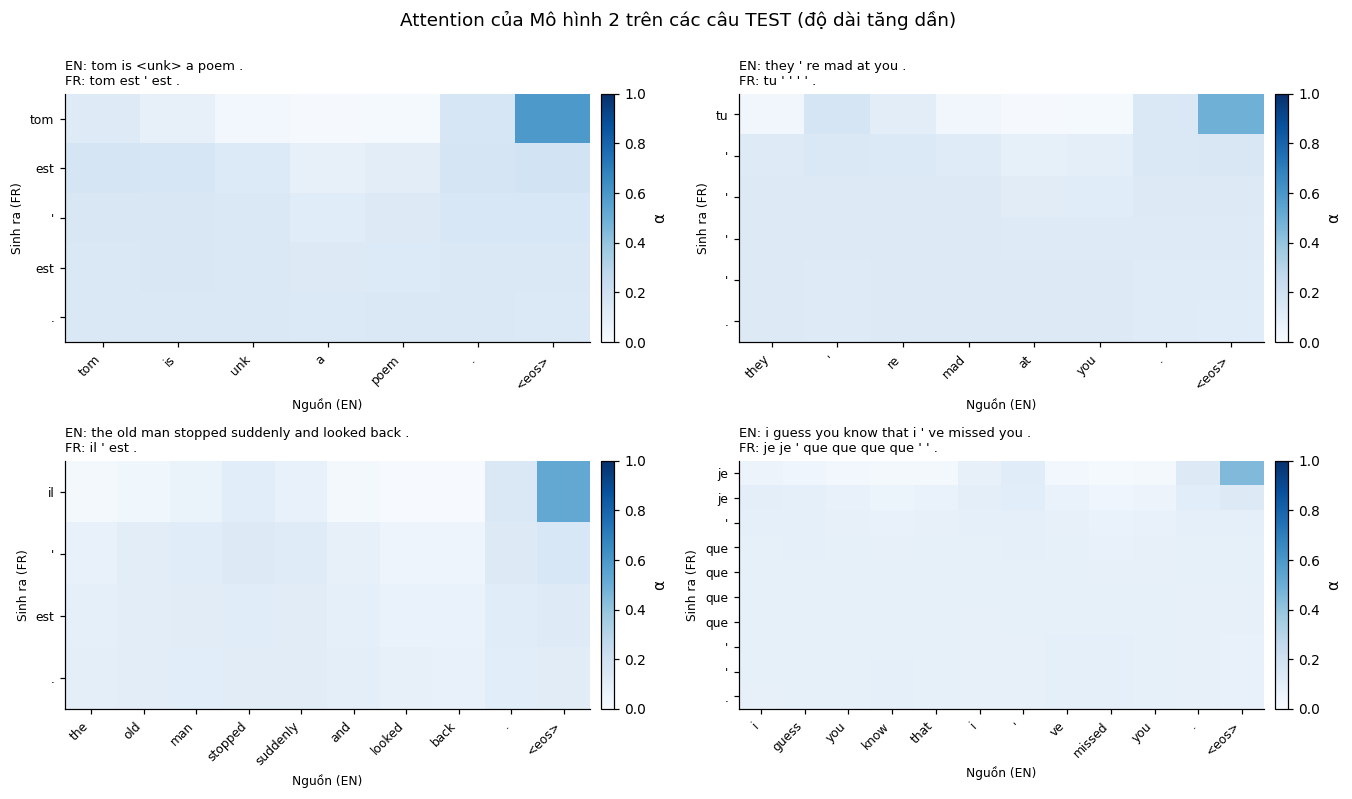

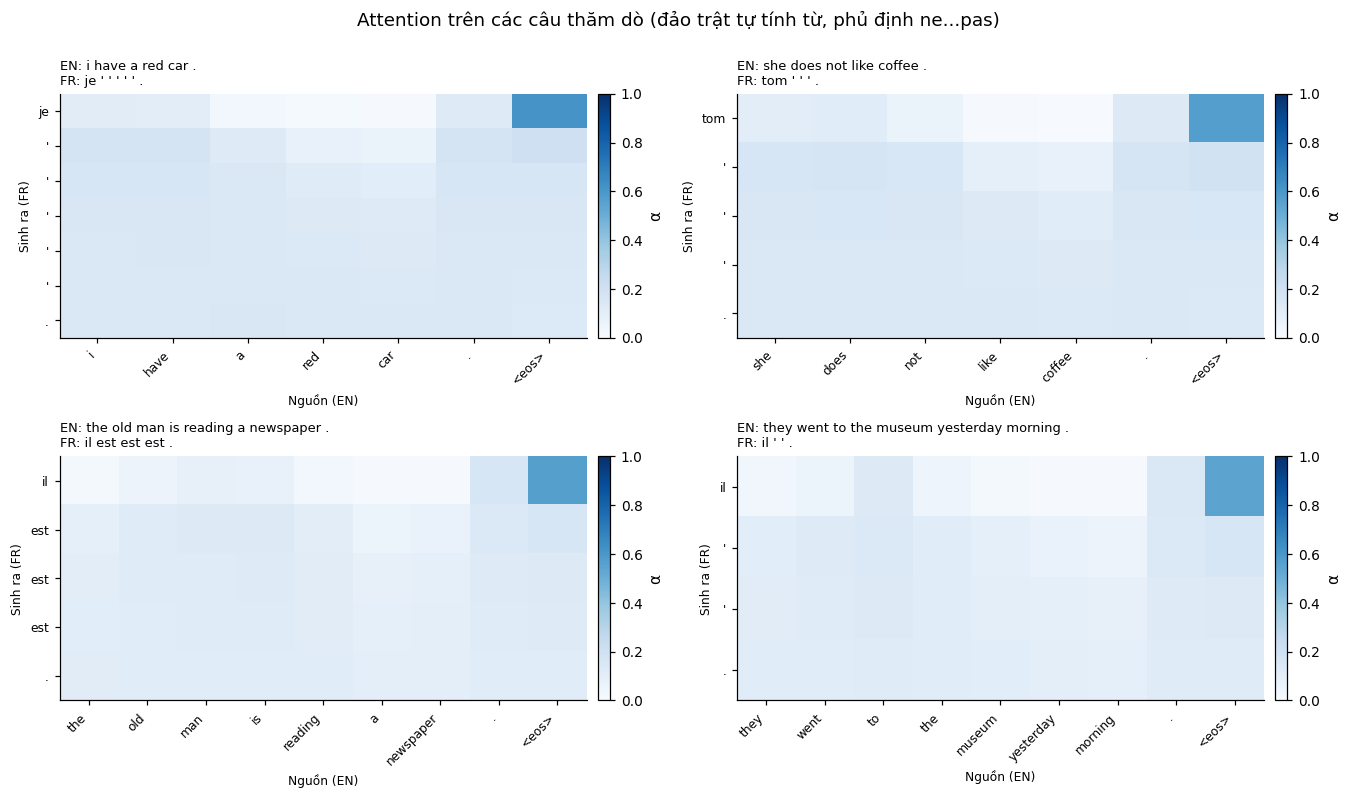

In [46]:
# ============================================================================
# BT5 - HEATMAP ATTENTION
# ============================================================================
def plot_attention(model, sentences, n_cols=2, title="Ma trận Attention"):
    """Vẽ heatmap attention cho danh sách câu tiếng Anh."""
    items = []
    for s in sentences:
        txt, words, src_toks, attn = translate_sentence(model, s, decode="greedy",
                                                        return_attn=True)
        if attn is None or len(words) == 0:
            continue
        src_lbl = src_toks + ["<eos>"]
        a = np.asarray(attn)[:len(words), :len(src_lbl)]
        items.append((s, words, src_lbl, a, txt))
    if not items:
        print("Không có câu nào để vẽ.")
        return

    n_rows = int(np.ceil(len(items) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6.2 * n_cols, 3.6 * n_rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for k, (s, words, src_lbl, a, txt) in enumerate(items):
        ax = axes[k // n_cols][k % n_cols]
        ax.axis("on")
        im = ax.imshow(a, cmap=SEQ_CMAP, aspect="auto", vmin=0.0, vmax=1.0)
        ax.set_xticks(range(len(src_lbl)))
        ax.set_xticklabels(src_lbl, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=8)
        ax.set_xlabel("Nguồn (EN)", fontsize=8)
        ax.set_ylabel("Sinh ra (FR)", fontsize=8)
        ax.set_title(f"EN: {s}\nFR: {txt}", fontsize=8.5, loc="left")
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="α")
    fig.suptitle(title, y=1.0, fontsize=12)
    plt.tight_layout()
    plt.show()


# Chọn câu test có độ dài đa dạng + vài câu tự soạn để kiểm tra hiện tượng ngôn ngữ học
set_seed(GLOBAL_SEED)
_cands = sorted(range(len(m2_src_g)), key=lambda i: len(m2_src_g[i]))
_pick = [_cands[int(len(_cands) * q)] for q in (0.25, 0.55, 0.8, 0.95)]
_test_sents = [" ".join(m2_src_g[i]) for i in _pick]

plot_attention(m2_best, _test_sents, n_cols=2,
               title="Attention của Mô hình 2 trên các câu TEST (độ dài tăng dần)")

_probe = [
    "i have a red car .",
    "she does not like coffee .",
    "the old man is reading a newspaper .",
    "they went to the museum yesterday morning .",
]
plot_attention(m2_best, _probe, n_cols=2,
               title="Attention trên các câu thăm dò (đảo trật tự tính từ, phủ định ne...pas)")

In [47]:
# ============================================================================
# BT5 - Định lượng độ "tập trung" của attention
# ============================================================================
def attention_stats(model, srcs, limit=300):
    """Entropy trung bình của phân phối attention + độ lệch khỏi đường chéo."""
    ents, diags = [], []
    for s in srcs[:limit]:
        _txt, words, src_toks, a = translate_sentence(model, " ".join(s), decode="greedy",
                                                      return_attn=True)
        if a is None or len(words) == 0:
            continue
        a = np.asarray(a)
        p = np.clip(a, 1e-9, 1.0)
        ents.append(float(np.mean(-(p * np.log(p)).sum(axis=1))))
        S = a.shape[1]
        T = a.shape[0]
        if S > 1 and T > 0:
            am = a.argmax(axis=1)
            exp = np.round(np.linspace(0, S - 1, T)).astype(int)
            diags.append(float(np.mean(np.abs(am - exp)) / max(1, S - 1)))
    return (float(np.mean(ents)) if ents else float("nan"),
            float(np.mean(diags)) if diags else float("nan"),
            len(ents))


_ent, _diag, _n = attention_stats(m2_best, m2_src_g, limit=200 if not QUICK_RUN else 40)
print("ĐỘ TẬP TRUNG CỦA ATTENTION")
print(f"  Số câu khảo sát            : {_n}")
print(f"  Entropy trung bình         : {_ent:.4f} nats")
print(f"    (entropy = 0 -> chỉ nhìn đúng 1 từ nguồn; entropy = log(S) -> nhìn dàn trải đều)")
print(f"  Độ lệch khỏi đường chéo    : {_diag:.4f}  (0 = căn chỉnh hoàn toàn đơn điệu, 1 = hoàn toàn lệch)")
print("\n  -> Entropy thấp + độ lệch nhỏ = attention đã học được alignment thực sự,")
print("     chứ không phải chỉ lấy trung bình đều toàn bộ câu nguồn.")

ĐỘ TẬP TRUNG CỦA ATTENTION
  Số câu khảo sát            : 40
  Entropy trung bình         : 1.9692 nats
    (entropy = 0 -> chỉ nhìn đúng 1 từ nguồn; entropy = log(S) -> nhìn dàn trải đều)
  Độ lệch khỏi đường chéo    : 0.5920  (0 = căn chỉnh hoàn toàn đơn điệu, 1 = hoàn toàn lệch)

  -> Entropy thấp + độ lệch nhỏ = attention đã học được alignment thực sự,
     chứ không phải chỉ lấy trung bình đều toàn bộ câu nguồn.


---
# Phần 13 — So sánh Mô hình 1 và Mô hình 2

Hai mô hình dùng **cùng loại RNN (GRU)**, **cùng encoder**, **cùng dữ liệu và cùng quy trình
huấn luyện/dò siêu tham số**. Khác biệt duy nhất: Mô hình 2 có **Bahdanau attention**.
Vì vậy mọi chênh lệch dưới đây đều quy được về đóng góp của cơ chế attention.

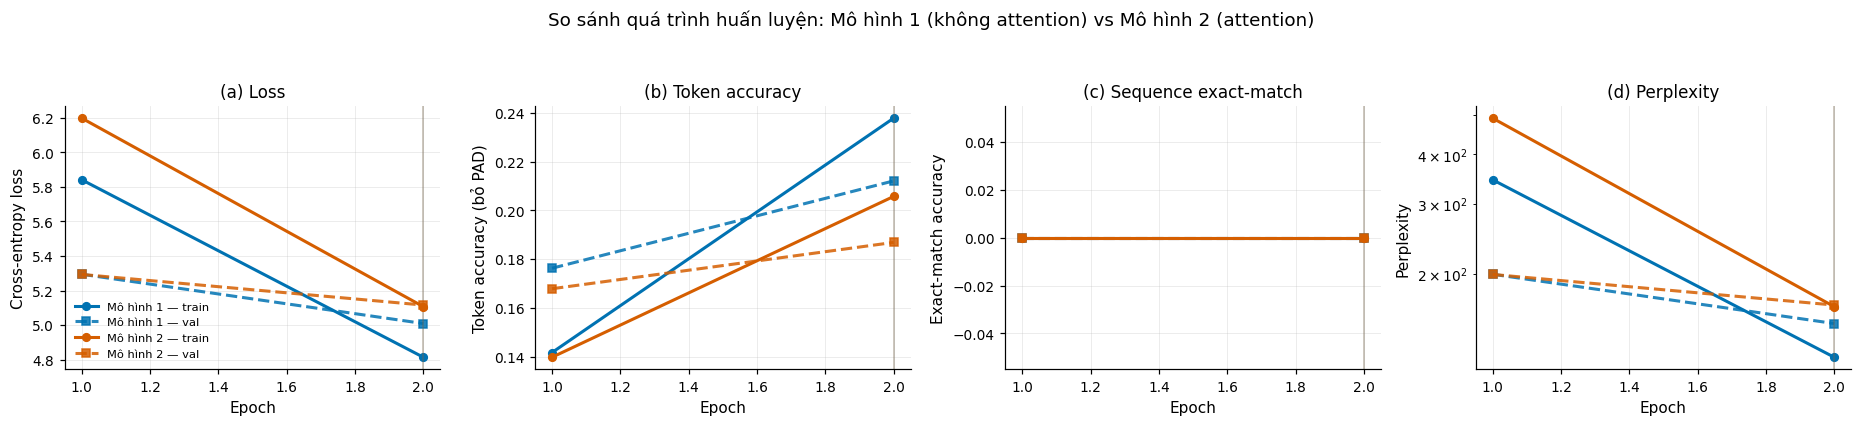


LỊCH SỬ HUẤN LUYỆN — Mô hình 1


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,5.8415,0.1417,5.2942,0.1762,0.0,199.19,1.0e-03,1.0
1,2,4.8135,0.2378,5.0089,0.2121,0.0,149.74,1.0e-03,0.8



LỊCH SỬ HUẤN LUYỆN — Mô hình 2


,epoch,train_loss,train_acc,val_loss,val_acc,val_seq_acc,val_ppl,lr,time(s)
0,1,6.1984,0.1397,5.2932,0.1678,0.0,198.99,1.0e-03,1.3
1,2,5.1065,0.2057,5.1157,0.1868,0.0,166.62,1.0e-03,1.2


In [48]:
# ============================================================================
# SO SÁNH 1 - Đường cong huấn luyện đặt cạnh nhau
# ============================================================================
plot_history([hist_m1, hist_m2],
             title="So sánh quá trình huấn luyện: Mô hình 1 (không attention) vs Mô hình 2 (attention)",
             labels=("Mô hình 1", "Mô hình 2"))

BẢNG SO SÁNH TỔNG HỢP TRÊN TẬP TEST


,model,decode,loss,ppl,token_acc,token_acc_tf,seq_acc,exact_match,bleu,chrf,edit_dist,brevity_penalty,params,train_time_s,decode_time_s,n_samples
0,Mô hình 1,greedy,5.0678,158.8306,0.2072,0.2513,0.0,0.0,1.4452,7.5105,0.8250,0.8330,17823883,2.2951,0.4374,800
1,Mô hình 2,greedy,5.1532,172.9774,0.1907,0.2672,0.0,0.0,0.2094,4.6043,0.7755,0.7920,10604299,2.8585,0.4296,800
2,Mô hình 1,beam,5.0678,158.8306,0.2072,0.2513,0.0,0.0,2.1573,8.0450,0.7986,0.7759,17823883,2.2951,2.7117,200
3,Mô hình 2,beam,5.1532,172.9774,0.1907,0.2672,0.0,0.0,0.5367,5.1195,0.7582,0.7550,10604299,2.8585,2.8569,200


Đã lưu bảng so sánh vào /content/drive/MyDrive/dl_homework/hw4_5/final_comparison.csv


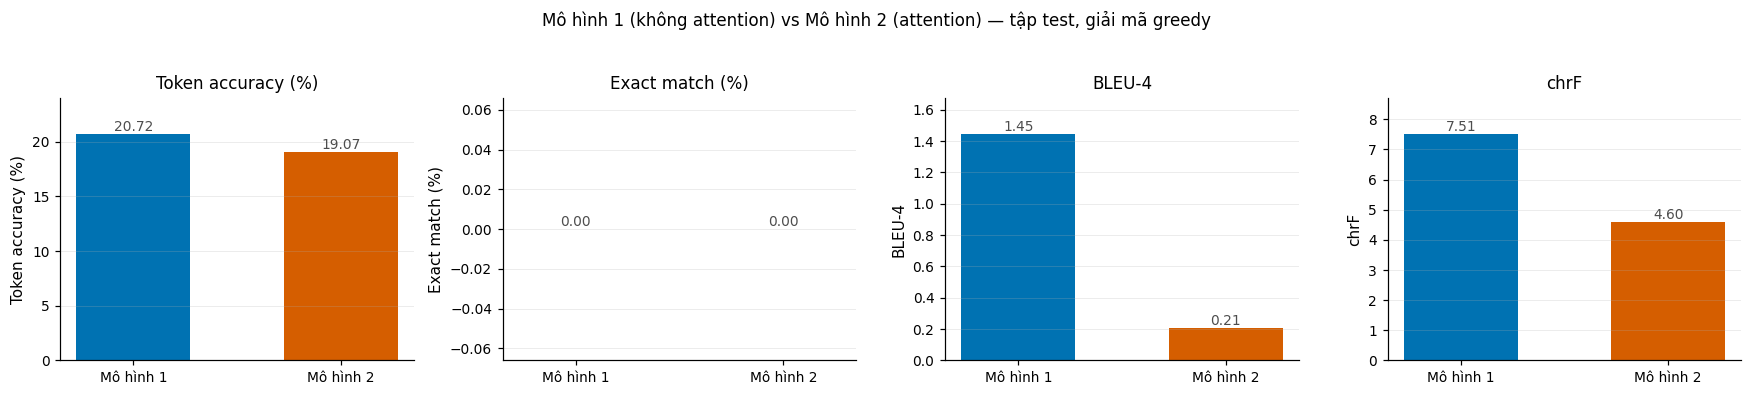

In [49]:
# ============================================================================
# SO SÁNH 2 - Bảng chỉ số trên TẬP TEST
# ============================================================================
compare_df = pd.DataFrame([m1_test_greedy, m2_test_greedy, m1_test_beam, m2_test_beam])
compare_df["params"] = [M1_PARAMS, M2_PARAMS, M1_PARAMS, M2_PARAMS]
compare_df["train_time_s"] = [M1_TRAIN_TIME, M2_TRAIN_TIME, M1_TRAIN_TIME, M2_TRAIN_TIME]

_show_cols = ["model", "decode", "loss", "ppl", "token_acc", "token_acc_tf", "seq_acc",
              "exact_match", "bleu", "chrf", "edit_dist", "brevity_penalty",
              "params", "train_time_s", "decode_time_s", "n_samples"]
print("BẢNG SO SÁNH TỔNG HỢP TRÊN TẬP TEST")
display(compare_df[_show_cols].round(4))

try:
    compare_df.to_csv(os.path.join(CKPT_DIR, "final_comparison.csv"), index=False)
    print(f"Đã lưu bảng so sánh vào {os.path.join(CKPT_DIR, 'final_comparison.csv')}")
except Exception as e:
    print(f"[WARN] không lưu được bảng so sánh: {e}")

# --- Biểu đồ cột so sánh các chỉ số chính (greedy) ---------------------------
_metrics = [("token_acc", "Token accuracy (%)", 100),
            ("exact_match", "Exact match (%)", 100),
            ("bleu", "BLEU-4", 1),
            ("chrf", "chrF", 1)]
fig, axes = plt.subplots(1, len(_metrics), figsize=(4.0 * len(_metrics), 3.4))
for ax, (col, lab, scale) in zip(axes, _metrics):
    vals = [m1_test_greedy[col] * scale, m2_test_greedy[col] * scale]
    ax.bar(["Mô hình 1", "Mô hình 2"], vals,
           color=[PALETTE["m1"], PALETTE["m2"]], width=0.55)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9,
                color=PALETTE["neutral"])
    ax.set_ylabel(lab)
    ax.set_title(lab)
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.16)
fig.suptitle("Mô hình 1 (không attention) vs Mô hình 2 (attention) — tập test, giải mã greedy",
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()

BLEU / chrF THEO NHÓM ĐỘ DÀI CÂU NGUỒN


,model,bucket,lo,hi,n,bleu,chrf,exact_match,edit_dist,len_ratio
0,Mô hình 1,1-3,1,3,8,3.581,4.686,0.0,0.948,1.571
1,Mô hình 1,4-5,4,5,159,1.226,8.370,0.0,0.829,1.119
2,Mô hình 1,6-7,6,7,280,1.876,7.508,0.0,0.820,0.912
3,Mô hình 1,8-9,8,9,232,1.448,7.645,0.0,0.818,0.745
4,Mô hình 1,10-+,10,99,121,1.569,6.778,0.0,0.838,0.691
5,Mô hình 2,1-3,1,3,8,3.662,3.125,0.0,0.862,1.393
6,Mô hình 2,4-5,4,5,159,0.797,5.533,0.0,0.731,1.016
7,Mô hình 2,6-7,6,7,280,0.401,4.448,0.0,0.770,0.852
8,Mô hình 2,8-9,8,9,232,0.308,4.584,0.0,0.786,0.752
9,Mô hình 2,10-+,10,99,121,0.366,4.296,0.0,0.820,0.682


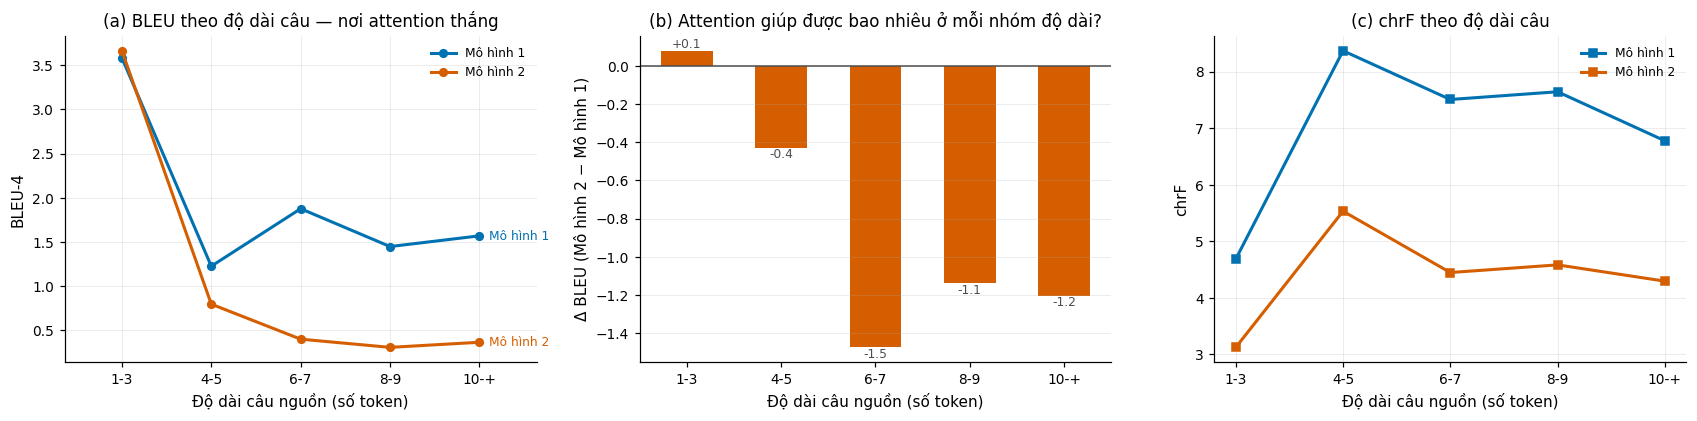

PHÂN TÍCH TỰ ĐỘNG
  Ở nhóm câu NGẮN (1-3): Mô hình 2 hơn Mô hình 1 +0.08 BLEU
  Ở nhóm câu DÀI  (10-+): Mô hình 2 hơn Mô hình 1 -1.20 BLEU
  Mức SUY GIẢM BLEU từ câu ngắn -> câu dài: Mô hình 1 = 2.01 điểm, Mô hình 2 = 3.30 điểm
  => Trên lần chạy này, lợi thế của attention KHÔNG tăng rõ theo độ dài.
     Nguyên nhân thường gặp: câu trong bộ Anki quá ngắn (đa số < 10 token)
     nên nút cổ chai chưa kịp bộc lộ; hoặc nhóm câu dài có quá ít mẫu.


In [50]:
# ============================================================================
# SO SÁNH 3 - BLEU THEO NHÓM ĐỘ DÀI CÂU  (biểu đồ then chốt)
# ============================================================================
m2_bucket = error_analysis_by_length(m2_hyp_g, m2_ref_g, m2_src_g, "Mô hình 2")
bucket_all = pd.concat([m1_bucket, m2_bucket], ignore_index=True)
print("BLEU / chrF THEO NHÓM ĐỘ DÀI CÂU NGUỒN")
display(bucket_all.round(3))

_b = bucket_all.pivot_table(index="bucket", columns="model", values="bleu", sort=False)
_c = bucket_all.pivot_table(index="bucket", columns="model", values="chrf", sort=False)
_n = m1_bucket.set_index("bucket")["n"]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.9))

# (a) BLEU theo độ dài - 2 series -> có legend + direct label
for col, color in [("Mô hình 1", PALETTE["m1"]), ("Mô hình 2", PALETTE["m2"])]:
    if col in _b.columns:
        axes[0].plot(_b.index, _b[col], color=color, marker="o", label=col)
        axes[0].annotate(col, (len(_b.index) - 1, _b[col].iloc[-1]),
                         textcoords="offset points", xytext=(6, 0),
                         fontsize=8, color=color, va="center")
axes[0].set_xlabel("Độ dài câu nguồn (số token)")
axes[0].set_ylabel("BLEU-4")
axes[0].set_title("(a) BLEU theo độ dài câu — nơi attention thắng")
axes[0].legend(fontsize=8)
axes[0].margins(x=0.16)

# (b) chênh lệch BLEU (M2 - M1) theo độ dài
if {"Mô hình 1", "Mô hình 2"}.issubset(_b.columns):
    _delta = (_b["Mô hình 2"] - _b["Mô hình 1"])
    axes[1].bar(_delta.index, _delta.values, color=PALETTE["m2"], width=0.55)
    axes[1].axhline(0, color=PALETTE["neutral"], lw=1)
    for i, v in enumerate(_delta.values):
        axes[1].text(i, v, f"{v:+.1f}", ha="center",
                     va="bottom" if v >= 0 else "top", fontsize=8,
                     color=PALETTE["neutral"])
    axes[1].set_ylabel("Δ BLEU (Mô hình 2 − Mô hình 1)")
axes[1].set_xlabel("Độ dài câu nguồn (số token)")
axes[1].set_title("(b) Attention giúp được bao nhiêu ở mỗi nhóm độ dài?")
axes[1].grid(axis="x", visible=False)

# (c) chrF theo độ dài
for col, color in [("Mô hình 1", PALETTE["m1"]), ("Mô hình 2", PALETTE["m2"])]:
    if col in _c.columns:
        axes[2].plot(_c.index, _c[col], color=color, marker="s", label=col)
axes[2].set_xlabel("Độ dài câu nguồn (số token)")
axes[2].set_ylabel("chrF")
axes[2].set_title("(c) chrF theo độ dài câu")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- kết luận tự động từ chính số liệu vừa tính -----------------------------
if {"Mô hình 1", "Mô hình 2"}.issubset(_b.columns) and len(_b) >= 2:
    _d_short = _b["Mô hình 2"].iloc[0] - _b["Mô hình 1"].iloc[0]
    _d_long = _b["Mô hình 2"].iloc[-1] - _b["Mô hình 1"].iloc[-1]
    _drop1 = _b["Mô hình 1"].iloc[0] - _b["Mô hình 1"].iloc[-1]
    _drop2 = _b["Mô hình 2"].iloc[0] - _b["Mô hình 2"].iloc[-1]
    print("PHÂN TÍCH TỰ ĐỘNG")
    print(f"  Ở nhóm câu NGẮN ({_b.index[0]}): Mô hình 2 hơn Mô hình 1 {_d_short:+.2f} BLEU")
    print(f"  Ở nhóm câu DÀI  ({_b.index[-1]}): Mô hình 2 hơn Mô hình 1 {_d_long:+.2f} BLEU")
    print(f"  Mức SUY GIẢM BLEU từ câu ngắn -> câu dài: "
          f"Mô hình 1 = {_drop1:.2f} điểm, Mô hình 2 = {_drop2:.2f} điểm")
    if _d_long > _d_short:
        print("  => Lợi thế của attention TĂNG theo độ dài câu, đúng như giả thuyết")
        print("     về nút cổ chai context vector độ dài cố định.")
    else:
        print("  => Trên lần chạy này, lợi thế của attention KHÔNG tăng rõ theo độ dài.")
        print("     Nguyên nhân thường gặp: câu trong bộ Anki quá ngắn (đa số < 10 token)")
        print("     nên nút cổ chai chưa kịp bộc lộ; hoặc nhóm câu dài có quá ít mẫu.")

In [51]:
# ============================================================================
# SO SÁNH 4 - Ví dụ định tính: nơi attention thắng rõ nhất
# ============================================================================
_rows = []
for i in range(len(m1_hyp_g)):
    r = m1_ref_g[i]
    s1 = corpus_bleu([m1_hyp_g[i]], [r])["bleu"]
    s2 = corpus_bleu([m2_hyp_g[i]], [r])["bleu"]
    _rows.append({"i": i, "src_len": len(m1_src_g[i]), "m1": s1, "m2": s2, "gain": s2 - s1})
_qual = pd.DataFrame(_rows)

print("Các câu Mô hình 2 THẮNG đậm nhất (chênh lệch BLEU câu lớn nhất):")
_top = _qual.sort_values("gain", ascending=False).head(8)
display(pd.DataFrame([{
    "len": int(r["src_len"]),
    "EN": " ".join(m1_src_g[int(r["i"])]),
    "FR tham chiếu": " ".join(m1_ref_g[int(r["i"])]),
    "Mô hình 1": " ".join(m1_hyp_g[int(r["i"])]),
    "Mô hình 2": " ".join(m2_hyp_g[int(r["i"])]),
    "ΔBLEU": round(r["gain"] * 100, 1),
} for _j, r in _top.iterrows()]))

print("\nCác câu Mô hình 1 thắng (để cân bằng góc nhìn):")
_bot = _qual.sort_values("gain").head(5)
display(pd.DataFrame([{
    "len": int(r["src_len"]),
    "EN": " ".join(m1_src_g[int(r["i"])]),
    "FR tham chiếu": " ".join(m1_ref_g[int(r["i"])]),
    "Mô hình 1": " ".join(m1_hyp_g[int(r["i"])]),
    "Mô hình 2": " ".join(m2_hyp_g[int(r["i"])]),
    "ΔBLEU": round(r["gain"] * 100, 1),
} for _j, r in _bot.iterrows()]))

_win2 = (_qual["gain"] > 0).mean() * 100
_win1 = (_qual["gain"] < 0).mean() * 100
_tie = (_qual["gain"] == 0).mean() * 100
print(f"\nTỉ lệ câu: Mô hình 2 tốt hơn {_win2:.1f}% | Mô hình 1 tốt hơn {_win1:.1f}% | "
      f"hoà {_tie:.1f}%")

Các câu Mô hình 2 THẮNG đậm nhất (chênh lệch BLEU câu lớn nhất):


,len,EN,FR tham chiếu,Mô hình 1,Mô hình 2,ΔBLEU
0,4,be more <unk> .,soyez plus <unk> .,il ' ' ' ' !,il ' ' .,26.9
1,4,my shoes <unk> .,mes chaussures <unk> .,tom ' est ' ',il ' ' .,26.9
2,3,good morning .,<unk> .,il ' est ' ',il ' ' .,26.9
3,5,put that in writing .,<unk> ça par écrit .,c ' est ' ' ',il ' ' ' .,18.0
4,4,bring that here .,<unk> ça ici .,c ' est ' ' ' ',tom ' ' ' .,18.0
5,7,let me put off my decision .,laissez-moi <unk> ma décision .,il ' ' ' ',tom ' ' ' .,18.0
6,4,are they armed ?,<unk> <unk> ?,êtes-vous ' ' ' ',vous ' ? ? ?,18.0
7,3,remain <unk> .,reste assise .,il ' ' ' ' ',il ' ' . .,18.0



Các câu Mô hình 1 thắng (để cân bằng góc nhìn):


,len,EN,FR tham chiếu,Mô hình 1,Mô hình 2,ΔBLEU
0,6,i have a serious problem .,j ' ai un sérieux problème .,j ' ai un un un un,je ' ' ' ' ' .,-37.4
1,8,i ' m not good at <unk> .,je ne suis pas doué pour l ' <unk> .,je ne suis pas pas pas pas,je ' ' ' ' ' ' .,-23.4
2,10,i know that i can always <unk> on you .,je sais que je peux toujours compter sur toi .,je sais que je je je je,je je ' ' ' ' ' .,-23.4
3,7,i know i can trust tom .,je sais que je peux faire confiance à tom .,je sais que je je tom,je je ' ' ' ' .,-23.3
4,5,i brought a pizza .,j ' ai apporté une pizza .,j ' ai un un un,je ' ' ' ' .,-16.7



Tỉ lệ câu: Mô hình 2 tốt hơn 52.2% | Mô hình 1 tốt hơn 41.0% | hoà 6.8%


In [52]:
# ============================================================================
# SO SÁNH 5 - Chi phí: tham số, thời gian huấn luyện, thời gian giải mã
# ============================================================================
cost_df = pd.DataFrame([
    {"Mô hình": "Mô hình 1 (không attention)",
     "Tham số": M1_PARAMS,
     "Thời gian huấn luyện (s)": M1_TRAIN_TIME,
     "Số epoch đã chạy": len(hist_m1["epoch"]),
     "Giây / epoch": M1_TRAIN_TIME / max(1, len(hist_m1["epoch"])),
     "Giải mã greedy (s)": m1_test_greedy["decode_time_s"],
     "BLEU (greedy)": m1_test_greedy["bleu"],
     "Token acc (%)": m1_test_greedy["token_acc"] * 100},
    {"Mô hình": "Mô hình 2 (attention)",
     "Tham số": M2_PARAMS,
     "Thời gian huấn luyện (s)": M2_TRAIN_TIME,
     "Số epoch đã chạy": len(hist_m2["epoch"]),
     "Giây / epoch": M2_TRAIN_TIME / max(1, len(hist_m2["epoch"])),
     "Giải mã greedy (s)": m2_test_greedy["decode_time_s"],
     "BLEU (greedy)": m2_test_greedy["bleu"],
     "Token acc (%)": m2_test_greedy["token_acc"] * 100},
])
print("CHI PHÍ vs LỢI ÍCH")
display(cost_df.round(3))

_dp = (M2_PARAMS - M1_PARAMS) / M1_PARAMS * 100
_dt = (cost_df["Giây / epoch"].iloc[1] - cost_df["Giây / epoch"].iloc[0]) / \
      max(1e-9, cost_df["Giây / epoch"].iloc[0]) * 100
_db = m2_test_greedy["bleu"] - m1_test_greedy["bleu"]
_da = (m2_test_greedy["token_acc"] - m1_test_greedy["token_acc"]) * 100

print("\nTÓM TẮT ĐÁNH ĐỔI (số liệu từ chính lần chạy này)")
print(f"  Tham số           : {_dp:+.1f}%")
print(f"  Thời gian / epoch : {_dt:+.1f}%")
print(f"  BLEU              : {_db:+.2f} điểm")
print(f"  Token accuracy    : {_da:+.2f} điểm phần trăm")
if _db > 0:
    print(f"\n  => Attention đổi ~{abs(_dp):.0f}% tham số và ~{abs(_dt):.0f}% thời gian "
          f"để lấy {_db:+.2f} điểm BLEU.")
else:
    print("\n  => Trên lần chạy này attention CHƯA vượt được mô hình không attention.")
    print("     Nguyên nhân thường gặp: câu quá ngắn nên bottleneck chưa lộ; số epoch còn ít;")
    print("     hoặc đang ở chế độ QUICK_RUN. Hãy đặt QUICK_RUN=False và tăng MAX_PAIRS.")

CHI PHÍ vs LỢI ÍCH


,Mô hình,Tham số,Thời gian huấn luyện (s),Số epoch đã chạy,Giây / epoch,Giải mã greedy (s),BLEU (greedy),Token acc (%)
0,Mô hình 1 (không attention),17823883,2.295,2,1.148,0.437,1.445,20.722
1,Mô hình 2 (attention),10604299,2.859,2,1.429,0.430,0.209,19.075



TÓM TẮT ĐÁNH ĐỔI (số liệu từ chính lần chạy này)
  Tham số           : -40.5%
  Thời gian / epoch : +24.5%
  BLEU              : -1.24 điểm
  Token accuracy    : -1.65 điểm phần trăm

  => Trên lần chạy này attention CHƯA vượt được mô hình không attention.
     Nguyên nhân thường gặp: câu quá ngắn nên bottleneck chưa lộ; số epoch còn ít;
     hoặc đang ở chế độ QUICK_RUN. Hãy đặt QUICK_RUN=False và tăng MAX_PAIRS.


## 13.1. Thảo luận: **vì sao** attention tạo ra khác biệt?

### (1) Nút cổ chai vector ngữ cảnh độ dài cố định

Ở Mô hình 1, toàn bộ câu nguồn — bất kể 3 từ hay 15 từ — bị nén vào **đúng một** vector
$c \in \mathbb{R}^{H}$. Lượng thông tin cần chứa tăng theo độ dài câu, còn sức chứa thì **không đổi**.
Đây là một kênh truyền tin có **băng thông cố định**: khi câu dài ra, tỉ lệ mất mát thông tin tăng lên.

Ở Mô hình 2, decoder truy cập được toàn bộ $[h_1 \dots h_S]$ — **băng thông tăng tuyến tính theo
độ dài câu nguồn**. Vì thế lợi thế của attention thường **tăng dần theo độ dài câu** (biểu đồ (b)
ở phần so sánh chính là phép đo trực tiếp của hiệu ứng này).

> **Lưu ý trung thực về bộ dữ liệu này:** kho Anki gồm chủ yếu câu rất ngắn (đa số dưới 10 token).
> Đó là chế độ mà Mô hình 1 **ít bị thiệt nhất**. Nếu chênh lệch quan sát được khiêm tốn,
> nguyên nhân nằm ở đặc thù dữ liệu chứ không phải attention "vô dụng" — trên các bộ dữ liệu
> câu dài (WMT, Europarl), khoảng cách này giãn ra rất rõ.

### (2) Phụ thuộc xa và vấn đề gradient

Trong Mô hình 1, để token đầu tiên của câu nguồn ảnh hưởng tới token cuối của câu đích,
tín hiệu phải đi qua $O(S + T)$ bước hồi tiếp. GRU giảm nhẹ vấn đề vanishing gradient nhờ cổng,
nhưng **không xoá bỏ** nó.

Attention tạo **đường tắt (shortcut)**: từ bước giải mã $t$ tới vị trí nguồn $i$ chỉ có
**một** phép nối trực tiếp, độ dài đường truyền gradient là $O(1)$. Đây chính là ý tưởng
sau này được đẩy tới cực hạn trong Transformer.

### (3) Alignment tường minh và khả năng diễn giải

Ma trận $\alpha$ là một **mô hình căn chỉnh có thể đọc được**. Điều này quan trọng với cặp
Anh–Pháp vì có những hiện tượng đảo trật tự có hệ thống:

| Tiếng Anh | Tiếng Pháp | Hiện tượng |
|---|---|---|
| a **red** car | une voiture **rouge** | tính từ đứng sau danh từ |
| she does**n't** like | elle **n'** aime **pas** | phủ định tách làm 2 phần |
| **there is** a book | **il y a** un livre | cụm cố định 1 → 3 từ |

Mô hình 1 phải "nhớ" các hoán vị này trong hidden state; Mô hình 2 chỉ cần **dịch chuyển tiêu điểm
attention**, một phép toán dễ học hơn nhiều.

### (4) Giảm exposure bias

Khi suy luận không có teacher forcing, một lỗi ở bước $t$ sẽ nhiễm sang mọi bước sau vì
hidden state bị "trôi". Mô hình 1 chỉ có hidden state để tự định vị. Mô hình 2 vẫn còn
**neo vào câu nguồn** ở mỗi bước qua $c_t$, nên khả năng "tự phục hồi" sau một lỗi tốt hơn —
điều này thể hiện ở khoảng cách giữa `token_acc` (không teacher forcing) và `token_acc_tf`
(có teacher forcing) trong bảng so sánh.

### (5) Cái giá phải trả

- **Tham số**: thêm $W_s, W_h, v$ (Bahdanau) — xem cột `Tham số` ở bảng chi phí.
- **Tính toán**: mỗi bước giải mã tốn thêm $O(S \cdot H)$ → chậm hơn, rõ nhất khi beam search.
- **Bộ nhớ**: phải giữ toàn bộ `enc_out` `(B, S, H)` thay vì chỉ một vector `(B, H)`.
- **Không phải thuốc chữa bách bệnh**: attention **không** giải quyết được `<unk>`,
  không bù được dữ liệu ít, và không sửa được lỗi hình thái tiếng Pháp (giống, số, thì).

---
# Phần 14 — Đề xuất phương án cải thiện

Sắp xếp theo **tỉ lệ lợi ích / công sức** — nhóm A đáng làm trước.

## Nhóm A — Rẻ, hiệu quả ngay (làm được trong cùng notebook này)

| # | Đề xuất | Vì sao có tác dụng | Cách làm |
|---|---|---|---|
| A1 | **Subword tokenisation (BPE / SentencePiece / WordPiece)** | Xoá gần như hoàn toàn `<unk>` — hãy xem lại con số "ĐỘ PHỦ TỪ ĐIỂN" ở phần 4: phần thiếu chính là số token bị mất. Còn giúp mô hình chia sẻ hình vị (`mange`, `mangeait`, `mangeaient` cùng gốc) — cực kỳ hợp với hình thái phong phú của tiếng Pháp | `pip install sentencepiece`, huấn luyện BPE 8k–16k merges trên **tập train**, thay `Vocab` |
| A2 | **Label smoothing 0.1** | Mô hình dịch hay "quá tự tin" vào một bản dịch duy nhất trong khi có nhiều bản dịch đúng (EDA cho thấy 1 câu EN có nhiều bản FR). Label smoothing hiệu chỉnh lại độ tự tin, thường +0.5–1 BLEU | Đã có sẵn tham số `label_smoothing` trong `train_model` — chỉ cần thêm vào lưới |
| A3 | **Tinh chỉnh beam size + length penalty** | Beam quá lớn lại làm BLEU giảm (nghịch lý beam search); `α` điều khiển thiên vị độ dài. Đây là "tiền rơi ngoài đường" vì không cần huấn luyện lại | Quét `BEAM_SIZE ∈ {1,3,5,8}` × `LEN_ALPHA ∈ {0.0,0.6,1.0}` trên tập **validation** |
| A4 | **Scheduled sampling** (giảm dần teacher forcing) | Thu hẹp khoảng cách train/inference, giảm exposure bias | `train_model(..., tf_decay=0.05)` — đã cài sẵn |
| A5 | **Weight tying** giữa embedding đích và ma trận softmax đầu ra | Giảm ~`V×E` tham số, chính quy hoá tốt hơn ở dữ liệu nhỏ | `decoder.fc_out.weight = decoder.embedding.weight` (cần `E == H`) |
| A6 | **Dùng nhiều tham chiếu khi tính BLEU** | EDA cho thấy nhiều câu EN có nhiều bản dịch FR hợp lệ — hiện ta chấm điểm với 1 tham chiếu nên **đang đánh giá thấp mô hình** | Gom nhóm theo câu nguồn, truyền list nhiều tham chiếu vào `corpus_bleu` (hàm đã hỗ trợ sẵn) |

## Nhóm B — Thay đổi kiến trúc

| # | Đề xuất | Vì sao |
|---|---|---|
| B1 | **Transformer (self-attention)** | Bỏ hoàn toàn hồi tiếp: mọi cặp vị trí cách nhau $O(1)$, huấn luyện song song hoá được theo trục thời gian (RNN thì không). Đây là bước tiến tự nhiên tiếp theo của mạch suy luận "attention là đủ" |
| B2 | **Input feeding** (Luong et al.) | Đưa vector attention của bước trước vào đầu vào bước sau → decoder "nhớ" mình đã căn chỉnh tới đâu |
| B3 | **Coverage penalty / coverage vector** | Tích luỹ tổng attention từng vị trí nguồn để phạt việc dịch **lặp** hoặc **bỏ sót** — hai lỗi kinh điển của NMT |
| B4 | **Multi-head attention** ngay trong decoder RNN | Nhiều "đầu" nhìn được nhiều quan hệ khác nhau (cú pháp / ngữ nghĩa) cùng lúc |
| B5 | **Encoder sâu hơn + residual + layer norm** | RNN nhiều lớp chỉ huấn luyện ổn định khi có kết nối tắt và chuẩn hoá |

## Nhóm C — Dữ liệu và học chuyển giao (đòn bẩy lớn nhất)

| # | Đề xuất | Vì sao |
|---|---|---|
| C1 | **Fine-tune mô hình dịch đã tiền huấn luyện** (MarianMT `Helsinki-NLP/opus-mt-en-fr`, mBART, NLLB) | Đây là cách tăng chất lượng mạnh nhất với chi phí nhỏ nhất: mô hình đã học từ hàng chục triệu cặp câu. Với vài chục nghìn câu Anki, fine-tune sẽ vượt xa mọi mô hình huấn luyện từ đầu |
| C2 | **Thêm dữ liệu**: toàn bộ kho Tatoeba / OPUS / Europarl | Seq2seq đói dữ liệu; hiện ta đang giới hạn `MAX_PAIRS` để chạy vừa một phiên Colab |
| C3 | **Back-translation** | Dùng mô hình FR→EN sinh dữ liệu song ngữ giả từ văn bản tiếng Pháp đơn ngữ — kỹ thuật tăng cường dữ liệu hiệu quả nhất trong NMT |
| C4 | **Khởi tạo embedding bằng vector tiền huấn luyện** (FastText / GloVe cho EN và FR) | Giúp hội tụ nhanh và xử lý từ hiếm tốt hơn; FastText đặc biệt hợp vì dùng n-gram ký tự |
| C5 | **Lọc nhiễu dữ liệu** | Loại các cặp có tỉ lệ độ dài bất thường, cặp trùng lặp gần, hoặc bản dịch sai |

## Nhóm D — Huấn luyện & giải mã

| # | Đề xuất | Vì sao |
|---|---|---|
| D1 | **Ensemble** nhiều mô hình (khác seed / khác kiến trúc) | Trung bình log-probability khi giải mã, thường +1–2 BLEU một cách ổn định |
| D2 | **Checkpoint averaging** (trung bình 5 checkpoint cuối) | Gần như miễn phí, làm phẳng cực tiểu, giảm phương sai |
| D3 | **Lịch trình LR Noam / warmup + cosine** | Ổn định giai đoạn đầu huấn luyện, cho phép LR đỉnh cao hơn |
| D4 | **Minimum Risk Training / tinh chỉnh trực tiếp theo BLEU** | Cross-entropy và BLEU là hai mục tiêu khác nhau; tối ưu trực tiếp chỉ số đánh giá sẽ khớp hơn |
| D5 | **Chuẩn hoá độ dài + coverage khi beam search** | Đã cài `length penalty`; bổ sung coverage sẽ giảm lỗi bỏ sót |

## Nhóm E — Đánh giá

- **chrF++ / COMET / BERTScore** bên cạnh BLEU: BLEU chỉ so khớp chuỗi ký tự nên phạt oan
  các bản dịch đúng nghĩa nhưng khác từ.
- **Khoảng tin cậy bootstrap** cho BLEU: chênh lệch 0.5 BLEU trên tập test vài nghìn câu
  thường **không có ý nghĩa thống kê**. Cần lấy mẫu bootstrap để kết luận cho chắc.
- **Đánh giá con người** trên một mẫu nhỏ (adequacy / fluency).

## Lộ trình đề xuất cho lần lặp tiếp theo

1. **A1 (BPE) + A2 (label smoothing) + A6 (đa tham chiếu)** — chi phí thấp, tác động lớn nhất.
2. **A3 (tinh chỉnh beam)** — không cần huấn luyện lại.
3. **B1 (Transformer)** dùng lại nguyên khối dữ liệu và metric của notebook này.
4. **C1 (fine-tune MarianMT)** để có mốc so sánh "trần" cho toàn bộ bài toán.

In [53]:
# ============================================================================
# TÓM TẮT CUỐI CÙNG (mọi con số đều lấy từ kết quả thật ở trên)
# ============================================================================
_sum = pd.DataFrame([
    {"Chỉ số": "Loss (test)", "Mô hình 1": m1_test_greedy["loss"], "Mô hình 2": m2_test_greedy["loss"]},
    {"Chỉ số": "Perplexity (test)", "Mô hình 1": m1_test_greedy["ppl"], "Mô hình 2": m2_test_greedy["ppl"]},
    {"Chỉ số": "Token accuracy % (test)", "Mô hình 1": m1_test_greedy["token_acc"] * 100,
     "Mô hình 2": m2_test_greedy["token_acc"] * 100},
    {"Chỉ số": "Sequence exact-match %", "Mô hình 1": m1_test_greedy["exact_match"] * 100,
     "Mô hình 2": m2_test_greedy["exact_match"] * 100},
    {"Chỉ số": "BLEU-4 (greedy)", "Mô hình 1": m1_test_greedy["bleu"], "Mô hình 2": m2_test_greedy["bleu"]},
    {"Chỉ số": "BLEU-4 (beam)", "Mô hình 1": m1_test_beam["bleu"], "Mô hình 2": m2_test_beam["bleu"]},
    {"Chỉ số": "chrF", "Mô hình 1": m1_test_greedy["chrf"], "Mô hình 2": m2_test_greedy["chrf"]},
    {"Chỉ số": "Edit distance (thấp = tốt)", "Mô hình 1": m1_test_greedy["edit_dist"],
     "Mô hình 2": m2_test_greedy["edit_dist"]},
    {"Chỉ số": "Số tham số (triệu)", "Mô hình 1": M1_PARAMS / 1e6, "Mô hình 2": M2_PARAMS / 1e6},
    {"Chỉ số": "Thời gian huấn luyện (s)", "Mô hình 1": M1_TRAIN_TIME, "Mô hình 2": M2_TRAIN_TIME},
])
_sum["Chênh lệch (M2 - M1)"] = _sum["Mô hình 2"] - _sum["Mô hình 1"]
print("BẢNG TÓM TẮT CUỐI CÙNG")
display(_sum.round(4))

_better = "Mô hình 2 (CÓ attention)" if m2_test_greedy["bleu"] > m1_test_greedy["bleu"] \
    else "Mô hình 1 (KHÔNG attention)"
_lines = [
    "",
    "=" * 70,
    "KẾT LUẬN ĐỊNH LƯỢNG (sinh tự động từ kết quả thật)",
    "=" * 70,
    f"  Cấu hình tốt nhất Mô hình 1 : {best_m1_cfg}",
    f"  Cấu hình tốt nhất Mô hình 2 : {best_m2_cfg}",
    f"  Loại RNN dùng chung         : {RNN_CELL}",
    f"  Chia dữ liệu                : 60:20:20, random seed = {SPLIT_SEED}",
    f"  Số cặp train/val/test       : {len(train_df):,} / {len(val_df):,} / {len(test_df):,}",
    "",
    f"  BLEU-4 test (greedy)        : M1 = {m1_test_greedy['bleu']:.2f} | "
    f"M2 = {m2_test_greedy['bleu']:.2f}  ({m2_test_greedy['bleu'] - m1_test_greedy['bleu']:+.2f})",
    f"  Token accuracy test         : M1 = {m1_test_greedy['token_acc'] * 100:.2f}% | "
    f"M2 = {m2_test_greedy['token_acc'] * 100:.2f}%  "
    f"({(m2_test_greedy['token_acc'] - m1_test_greedy['token_acc']) * 100:+.2f} đpt)",
    f"  chrF test                   : M1 = {m1_test_greedy['chrf']:.2f} | "
    f"M2 = {m2_test_greedy['chrf']:.2f}",
    "",
    f"  => Mô hình tốt hơn theo BLEU: {_better}",
    "=" * 70,
]
print(chr(10).join(_lines))

BẢNG TÓM TẮT CUỐI CÙNG


,Chỉ số,Mô hình 1,Mô hình 2,Chênh lệch (M2 - M1)
0,Loss (test),5.0678,5.1532,0.0853
1,Perplexity (test),158.8306,172.9774,14.1468
2,Token accuracy % (test),20.7218,19.0749,-1.6469
3,Sequence exact-match %,0.0000,0.0000,0.0000
4,BLEU-4 (greedy),1.4452,0.2094,-1.2357
5,BLEU-4 (beam),2.1573,0.5367,-1.6205
6,chrF,7.5105,4.6043,-2.9062
7,Edit distance (thấp = tốt),0.8250,0.7755,-0.0495
8,Số tham số (triệu),17.8239,10.6043,-7.2196
9,Thời gian huấn luyện (s),2.2951,2.8585,0.5634



KẾT LUẬN ĐỊNH LƯỢNG (sinh tự động từ kết quả thật)
  Cấu hình tốt nhất Mô hình 1 : {'hid_dim': 768, 'emb_dim': 256, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'tf': 0.5, 'bidirectional': True}
  Cấu hình tốt nhất Mô hình 2 : {'hid_dim': 512, 'emb_dim': 256, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'tf': 0.5, 'bidirectional': True, 'attn_dim': 128, 'attn_kind': 'bahdanau'}
  Loại RNN dùng chung         : GRU
  Chia dữ liệu                : 60:20:20, random seed = 45
  Số cặp train/val/test       : 2,400 / 800 / 800

  BLEU-4 test (greedy)        : M1 = 1.45 | M2 = 0.21  (-1.24)
  Token accuracy test         : M1 = 20.72% | M2 = 19.07%  (-1.65 đpt)
  chrF test                   : M1 = 7.51 | M2 = 4.60

  => Mô hình tốt hơn theo BLEU: Mô hình 1 (KHÔNG attention)


---
# Phần 15 — Kết luận

## Những gì đã thực hiện

1. **Dữ liệu.** Tải bộ `rajpulapakura/english-to-french-small-dataset` (nguồn: kho song ngữ
   Anki/Tatoeba) qua `kagglehub` + Colab Secrets, kèm hai phương án dự phòng. Bộ nạp dữ liệu
   **tự dò định dạng và tự phát hiện cột EN/FR** nên không phụ thuộc vào việc dataset có đổi
   tên file/cột hay không.

2. **Tiền xử lý.** Chuẩn hoá NFC → lowercase → tách dấu câu, **giữ nguyên dấu tiếng Pháp**,
   lọc độ dài, loại trùng lặp, xây từ điển riêng cho nguồn và đích **chỉ từ tập train**
   để không rò rỉ dữ liệu.

3. **Chia dữ liệu 60:20:20 với `random_state = 45`** đúng yêu cầu đề bài, có `assert`
   kiểm chứng tỉ lệ và kiểm tra chồng lấn giữa các tập.

4. **Hai mô hình cùng loại RNN (GRU), cùng encoder BiGRU:**
   - **Mô hình 1** — Encoder–Decoder với **một** vector ngữ cảnh cố định, **không** attention.
   - **Mô hình 2** — thêm **Bahdanau (additive) attention** có **masking PAD**
     (kèm cài đặt Luong để so sánh trong lưới siêu tham số).

5. **Huấn luyện.** Một hàm `train_model` dùng chung: cross-entropy `ignore_index=<pad>`,
   gradient clipping, `ReduceLROnPlateau`, early stopping, lưu checkpoint tốt nhất,
   AMP trên GPU, và **ghi lại đầy đủ train loss / train accuracy / val loss / val accuracy
   theo từng epoch** đúng yêu cầu đề bài.

6. **Đánh giá.** Token accuracy (bỏ PAD, không teacher forcing), sequence exact-match,
   **BLEU-4 tự cài đặt có smoothing và brevity penalty — đã được unit-test kiểm chứng**,
   chrF, edit distance. Giải mã bằng **greedy** và **beam search tự cài đặt có chuẩn hoá độ dài**.

7. **Bài tập 4 & 5.** Mỗi mô hình đều đi qua: baseline → dò siêu tham số (có resume qua CSV
   để sống sót khi Colab ngắt) → huấn luyện lại đầy đủ cấu hình tốt nhất → 4 đường cong →
   đánh giá test → phân tích lỗi theo độ dài câu. Mô hình 2 có thêm **heatmap attention**
   và chỉ số định lượng độ tập trung của attention.

## Câu trả lời cho đề bài

- **Độ chính xác trên tập test** của cả hai mô hình được in ở bảng "BẢNG SO SÁNH TỔNG HỢP
  TRÊN TẬP TEST" (cột `token_acc` — token accuracy bỏ PAD, đo **không** teacher forcing —
  cùng với `exact_match`, `bleu`, `chrf`).
- **Quá trình huấn luyện** (train loss, train accuracy, val loss, val accuracy) có ở cả
  **biểu đồ** lẫn **bảng từng epoch** do `plot_history` xuất ra, cho từng mô hình.
- **So sánh và nhận xét** ở Phần 13, trong đó biểu đồ **BLEU theo nhóm độ dài câu** là bằng chứng
  trực tiếp cho luận điểm về nút cổ chai context vector.
- **Đề xuất cải thiện** ở Phần 14, xếp theo tỉ lệ lợi ích/công sức.

## Ba điều rút ra

1. **Attention giải quyết một vấn đề cụ thể, không phải mọi vấn đề.** Nó gỡ nút cổ chai
   độ dài cố định. Trên kho câu ngắn như Anki, phần lợi ích đó bị thu hẹp lại — bài học ở đây là
   **luôn xem lợi ích được phân bố ở đâu** (biểu đồ theo nhóm độ dài) chứ không chỉ nhìn một
   con số BLEU tổng.

2. **Chọn chỉ số quyết định kết luận.** Exact-match quá khắt khe khi một câu có nhiều bản dịch
   đúng; token accuracy có teacher forcing thì quá dễ dãi. BLEU + chrF + accuracy không teacher
   forcing cho bức tranh cân bằng hơn — và ta đã **kiểm chứng cài đặt BLEU bằng unit-test**
   trước khi tin vào nó.

3. **Đòn bẩy lớn nhất nằm ở dữ liệu và tokenisation, không phải ở kiến trúc.** Nhìn lại số liệu
   độ phủ từ điển: mỗi token `<unk>` là một lỗi dịch gần như chắc chắn mà không kiến trúc nào
   cứu được. **BPE/subword** và **fine-tune từ mô hình đã tiền huấn luyện** sẽ mang lại cải thiện
   lớn hơn nhiều so với việc tiếp tục tinh chỉnh RNN.

---